# 01b — Websach Inspection

> **Nguồn:** `clean_laptop_features.csv` — catalog laptop mới từ websosanh.vn (đã pre-cleaned, giữ lại 15 cột cần thiết).
>
> **Mục tiêu:** EDA và chuẩn bị merge với Chotot (có fields: `url, price, title, Hãng, Dòng máy, Tình trạng, Chính sách bảo hành, Kích cỡ màn hình, Bộ vi xử lý, RAM, Card màn hình, Ổ cứng, Xuất xứ, Loại ổ cứng`).

**Schema hiện tại (15 cột):**
```
Identity : Hãng sản xuất
CPU      : Công nghệ CPU, Loại CPU
RAM      : Dung lượng RAM, Loại RAM
Storage  : Loại ổ cứng, Dung lượng ổ cứng (GB)
GPU      : Đồ họa đã làm sạch
Display  : Kích thước (inch)
Price    : shop_1_price, shop_1_name, shop_2_price, shop_2_name, shop_3_price, shop_3_name
```

## Table of Contents
1. [Setup & Load](#1-setup--load)
2. [Snapshot & Missing Overview](#2-snapshot--missing-overview)
3. [Nhóm Price — Inspect → Clean → Median](#3-nhóm-price)
4. [Nhóm Identity & Display](#4-nhóm-identity--display)
5. [Nhóm CPU & RAM](#5-nhóm-cpu--ram)
6. [Nhóm Storage & GPU](#6-nhóm-storage--gpu)
7. [Duplicate Check](#7-duplicate-check)
8. [Cross-Source Alignment Plan](#8-cross-source-alignment-plan)
9. [Issues Summary & Cleaning Checklist](#9-issues-summary--cleaning-checklist))

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Helpers ──────────────────────────────────────────────────────────────────
def val_counts_pct(series, n=15):
    vc  = series.value_counts(dropna=False).head(n)
    pct = (vc / len(series) * 100).round(1)
    return pd.DataFrame({'count': vc, '%': pct})

def missing_summary(df):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(1)
    return pd.DataFrame({'missing': miss, '%': pct}).query('missing > 0').sort_values('%', ascending=False)

In [2]:
PATH = r"../../data/raw/clean_laptop_features.csv"
df   = pd.read_csv(PATH)

PRICE_COLS = ['shop_1_price', 'shop_2_price', 'shop_3_price']
NAME_COLS  = ['shop_1_name',  'shop_2_name',  'shop_3_name']
SPEC_COLS  = ['Hãng sản xuất', 'Công nghệ CPU', 'Loại CPU',
              'Dung lượng RAM', 'Loại RAM',
              'Loại ổ cứng', 'Dung lượng ổ cứng (GB)',
              'Đồ họa đã làm sạch', 'Kích thước (inch)']

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Shape: 4,384 rows × 15 columns


,Hãng sản xuất,Công nghệ CPU,Loại CPU,Dung lượng RAM,Loại RAM,Loại ổ cứng,Dung lượng ổ cứng (GB),Đồ họa đã làm sạch,Kích thước (inch),shop_1_price,shop_1_name,shop_2_price,shop_2_name,shop_3_price,shop_3_name
0,Acer,Intel Core i5,8265U,8.00,DDR4,SSD,512.00,Intel UHD Graphics,14.00,14950000,baochau.vn,15950000,quangmai.net,"15,990,000.00",compro.com.vn
1,Lg,Intel Core i7,1165G7,16.00,LPDDR4x,SSD,512.00,Intel Iris Xe,17.00,32640000,tiki.vn,47500000,tinhocsangtao.vn,"35,190,000.00",mixicomputer.vn
2,Lenovo,AMD Ryzen 7,8845HS,16.00,DDR5,SSD,512.00,RTX 4060,16.00,30900000,congnghesgsaigon.com,31490000,tnc.com.vn,"33,490,000.00",tymo.vn


In [3]:
# ── Parse giá → triệu VND ───────────────────────────────────────────────────
# FIX: Chỉ parse 1 lần tại đây. Section 3 KHÔNG parse lại.
#      Sau hàm này, PRICE_COLS đã ở đơn vị triệu VND (float).

def clean_price_to_million_vnd(x):
    """
    Nhận vào giá dạng string hoặc số (VND hoặc đã là triệu VND),
    trả về float theo đơn vị triệu VND. Trả về np.nan nếu không parse được.

    Xử lý các dạng:
      - 15,990,000   → 15.99
      - 15.990.000   → 15.99
      - 15,990,000.00 → 15.99
      - 15.99        → 15.99 (đã là triệu, không đổi)
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    if s == '' or s.lower() in ['nan', 'none', 'null']:
        return np.nan

    # Bỏ ký tự không phải số, dấu chấm, dấu phẩy
    s = re.sub(r'[^\d.,]', '', s)
    if s == '':
        return np.nan

    # Dạng: 15,990,000.00  (dấu . là decimal, dấu , là thousands)
    if ',' in s and '.' in s:
        if s.rfind('.') > s.rfind(','):
            s = s.replace(',', '')
        else:
            s = s.replace('.', '').replace(',', '.')

    # Dạng: 15,990,000  hoặc  15,99  (decimal dùng dấu ,)
    elif ',' in s:
        parts = s.split(',')
        if len(parts) > 2 or len(parts[-1]) == 3:
            s = s.replace(',', '')   # thousands separator
        else:
            s = s.replace(',', '.')  # decimal separator

    # Dạng: 15.990.000  hoặc  15990000.00
    elif '.' in s:
        parts = s.split('.')
        if len(parts) > 2 or len(parts[-1]) == 3:
            s = s.replace('.', '')   # thousands separator

    try:
        price_vnd = float(s)
    except ValueError:
        return np.nan

    # Nếu giá < 1000 → đã là triệu VND rồi (giả định min ~3M)
    # Nếu giá >= 1000 → vẫn là VND đầy đủ → chia 1_000_000
    return price_vnd if price_vnd < 1_000 else price_vnd / 1_000_000


for col in PRICE_COLS:
    df[col] = df[col].apply(clean_price_to_million_vnd)

print("Sau parse — đơn vị: triệu VND")
df[PRICE_COLS].describe().round(2)

Sau parse — đơn vị: triệu VND


,shop_1_price,shop_2_price,shop_3_price
count,"4,384.00","4,384.00","4,382.00"
mean,25.58,25.96,27.78
std,21.55,17.40,51.09
min,3.40,3.00,3.50
25%,14.59,15.09,15.50
50%,20.69,21.25,21.70
75%,30.91,31.00,31.49
max,860.00,179.40,"2,750.00"


---
## 2. Snapshot & Missing Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Hãng sản xuất           4204 non-null   object 
 1   Công nghệ CPU           4290 non-null   object 
 2   Loại CPU                4315 non-null   object 
 3   Dung lượng RAM          4363 non-null   float64
 4   Loại RAM                4066 non-null   object 
 5   Loại ổ cứng             4165 non-null   object 
 6   Dung lượng ổ cứng (GB)  4159 non-null   float64
 7   Đồ họa đã làm sạch      4384 non-null   object 
 8   Kích thước (inch)       4373 non-null   float64
 9   shop_1_price            4384 non-null   float64
 10  shop_1_name             4384 non-null   object 
 11  shop_2_price            4384 non-null   float64
 12  shop_2_name             4384 non-null   object 
 13  shop_3_price            4382 non-null   float64
 14  shop_3_name             4382 non-null   

,missing,%
Loại RAM,318,7.30
Dung lượng ổ cứng (GB),225,5.10
Loại ổ cứng,219,5.00
Hãng sản xuất,180,4.10
Công nghệ CPU,94,2.10
Loại CPU,69,1.60
Dung lượng RAM,21,0.50
Kích thước (inch),11,0.30
shop_3_price,2,0.00
shop_3_name,2,0.00


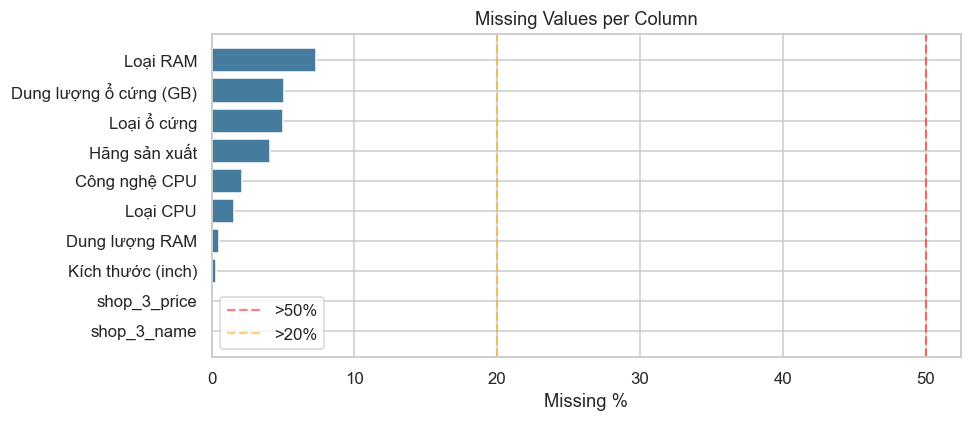

In [5]:
miss = missing_summary(df)

if miss.empty:
    print("Không có missing values.")
else:
    display(miss)
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#e63946' if v > 50 else '#f4a261' if v > 20 else '#457b9d'
              for v in miss['%']]
    ax.barh(miss.index[::-1], miss['%'][::-1], color=colors[::-1])
    ax.axvline(50, color='red',    linestyle='--', alpha=0.5, label='>50%')
    ax.axvline(20, color='orange', linestyle='--', alpha=0.5, label='>20%')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values per Column')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Missing values summary

Dữ liệu gồm **4.384 dòng và 15 cột**. Nhìn chung, tỷ lệ giá trị thiếu trong bộ dữ liệu không quá cao. Cột có tỷ lệ thiếu lớn nhất là **Loại RAM** với **318 giá trị thiếu**, chiếm khoảng **7,3%** tổng số quan sát. Tiếp theo là **Dung lượng ổ cứng (GB)** với **225 giá trị thiếu** tương ứng **5,1%**, **Loại ổ cứng** với **219 giá trị thiếu** tương ứng **5,0%**, và **Hãng sản xuất** với **180 giá trị thiếu**, chiếm **4,1%**.

Các cột còn lại có tỷ lệ thiếu thấp hơn đáng kể, chẳng hạn như **Công nghệ CPU** thiếu **2,1%**, **Loại CPU** thiếu **1,6%**, **Dung lượng RAM** thiếu **0,5%**, và **Kích thước (inch)** chỉ thiếu **0,3%**. Hai cột **shop_3_price** và **shop_3_name** chỉ thiếu 2 giá trị, gần như không ảnh hưởng nhiều đến chất lượng dữ liệu.

Dựa trên biểu đồ, không có cột nào có tỷ lệ thiếu vượt quá ngưỡng **20%** hoặc **50%**, do đó chưa cần loại bỏ cột nào chỉ vì thiếu dữ liệu. Với các cột dạng phân loại như **Loại RAM**, **Loại ổ cứng**, **Hãng sản xuất**, **Công nghệ CPU** và **Loại CPU**, có thể xử lý bằng cách điền giá trị thiếu bằng một nhãn như `"Unknown"` hoặc `"Không rõ"`. Đối với các cột dạng số như **Dung lượng ổ cứng (GB)**, **Dung lượng RAM** và **Kích thước (inch)**, có thể cân nhắc điền bằng giá trị trung vị để hạn chế ảnh hưởng của ngoại lai.

Tóm lại, bộ dữ liệu có mức độ thiếu dữ liệu tương đối thấp và vẫn đủ tốt để tiếp tục các bước phân tích khám phá dữ liệu, tiền xử lý và xây dựng mô hình.

---
## 3. Nhóm Price

### Recommended Price Analysis Strategy

Vì ba cột `shop_1_price`, `shop_2_price`, `shop_3_price` không đại diện cho ba shop cố định mà là ba nguồn giá bất kỳ được ghi nhận cho từng sản phẩm, phân tích giá không nên tập trung vào việc so sánh giữa `shop_1`, `shop_2` và `shop_3`. Thay vào đó, các cột này nên được xem là các **price slots** dùng để ước lượng mức giá tham chiếu của cùng một sản phẩm.

Trước hết, toàn bộ giá cần được chuẩn hóa về cùng một đơn vị, cụ thể là **triệu VND**, để tránh lỗi do dữ liệu ban đầu có thể ở dạng chuỗi, VND đầy đủ hoặc đã được parse một phần. Sau đó, cần kiểm tra số lượng giá có sẵn trên mỗi sản phẩm. Nếu một sản phẩm có ít nhất 2 hoặc 3 giá hợp lệ thì có thể giữ lại để phân tích; nếu không có bất kỳ giá nào thì nên loại bỏ khỏi nhóm phân tích giá.

Tiếp theo, nên xử lý ngoại lệ ở cấp độ từng ô giá thay vì xóa toàn bộ dòng. Các giá trị nằm ngoài miền hợp lý của laptop, ví dụ nhỏ hơn **3 triệu VND** hoặc lớn hơn **200 triệu VND**, nên được gán thành missing value. Cách này giúp loại bỏ giá bất thường nhưng vẫn giữ lại các giá hợp lệ còn lại của sản phẩm.

Sau khi lọc theo miền giá, nên tính mức độ chênh lệch giữa các nguồn giá trong cùng một dòng. Nếu spread giữa các giá quá lớn, ví dụ trên **30%** hoặc **50%**, dòng đó cần được gắn cờ để kiểm tra thêm. Với các trường hợp một giá lệch quá mạnh so với mặt bằng giá của chính sản phẩm, có thể null-out giá đó nếu nó nhỏ hơn **0.5×** hoặc lớn hơn **2×** so với row mean đã được tính sau bước lọc domain outlier. Điều quan trọng là row mean nên được tính từ dữ liệu đã qua lọc miền giá, không tính lại sau khi loại từng outlier để tránh circular reference.

Sau khi làm sạch xong, biến giá chính nên là `price_median`, được tính bằng trung vị của các giá hợp lệ còn lại trên từng sản phẩm. Median phù hợp hơn mean trong trường hợp này vì dữ liệu chỉ có tối đa 3 nguồn giá và có khả năng xuất hiện giá lỗi hoặc giá khuyến mãi bất thường. `price_median` sẽ đóng vai trò là **reference price** cho từng laptop.

Sau khi có `price_median`, các phân tích tiếp theo nên dựa trên đặc điểm sản phẩm thay vì price slot. Ví dụ: phân phối giá theo `Hãng sản xuất`, CPU brand, RAM tier, GPU brand, dung lượng ổ cứng, loại ổ cứng và kích thước màn hình. Đây là các phân tích có ý nghĩa hơn vì chúng phản ánh mối quan hệ giữa cấu hình laptop và giá tham chiếu.

Tóm lại, ba cột giá ban đầu chỉ nên được dùng như nhiều quan sát giá cho cùng một sản phẩm. Không nên phân tích chúng như ba shop cố định. Pipeline hợp lý là: chuẩn hóa giá → kiểm tra số lượng giá mỗi dòng → lọc domain outlier → đo spread giữa các nguồn → null-out giá lệch mạnh → tính `price_median` → phân tích giá theo đặc điểm sản phẩm.

In [30]:
# ── 3.1 Price setup: constants + long format ────────────────────────────────

PRICE_LO = 3       # triệu VND
PRICE_HI = 200     # triệu VND

SPREAD_WARN = 0.30      # flag nếu spread > 30% row mean
SPREAD_CRITICAL = 0.50  # flag mạnh nếu spread > 50% row mean

REL_DEV_MAX = 2.0
# REL_DEV_MAX = 2.0 nghĩa là null-out cell nếu:
# abs(price - row_mean_domain) / row_mean_domain > 2.0
# Đây là rule khá conservative, tránh xóa nhầm giá thật.

# Tạo product_id để trace từng dòng
df = df.copy()
df["product_id"] = df.index

# Long format: mỗi dòng = 1 price observation từ 1 price slot
price_long_raw = pd.concat(
    [
        df[["product_id", price_col, name_col]]
        .rename(columns={price_col: "price", name_col: "shop_name"})
        .assign(price_slot=f"shop_{i}")
        [["product_id", "price_slot", "shop_name", "price"]]
        for i, (price_col, name_col) in enumerate(zip(PRICE_COLS, NAME_COLS), start=1)
    ],
    ignore_index=True
)

price_long_raw = price_long_raw.dropna(subset=["price"])

print(f"Total price observations: {len(price_long_raw):,}")
print(f"Unique products: {df['product_id'].nunique():,}")

display(
    price_long_raw
    .groupby("price_slot")["price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

display(price_long_raw.head(10))

Total price observations: 13,150
Unique products: 4,384


,count,mean,median,std,min,max
price_slot,,,,,,
shop_1,4384,25.58,20.69,21.55,3.40,860.00
shop_2,4384,25.96,21.25,17.40,3.00,179.40
shop_3,4382,27.78,21.70,51.09,3.50,"2,750.00"


,product_id,price_slot,shop_name,price
0,0,shop_1,baochau.vn,14.95
1,1,shop_1,tiki.vn,32.64
2,2,shop_1,congnghesgsaigon.com,30.90
3,3,shop_1,redlaptop.vn,23.90
4,4,shop_1,dienmayxanh.com,54.79
5,5,shop_1,eaz.com.vn,96.60
6,6,shop_1,tnc.com.vn,31.49
7,7,shop_1,hungphuc.vn,11.98
8,8,shop_1,vitinhmanhphat.com,22.90
9,9,shop_1,happytechstore.vn,50.90


### Convert Price Slots to Long Format

Sau khi chuyển dữ liệu giá từ dạng wide sang dạng long, bộ dữ liệu có tổng cộng **13.150 quan sát giá** từ **4.384 sản phẩm**. Mỗi sản phẩm có tối đa 3 giá tương ứng với 3 price slots: `shop_1`, `shop_2` và `shop_3`.

Thống kê ban đầu cho thấy median của ba price slots khá gần nhau, lần lượt là **20,69 triệu**, **21,25 triệu** và **21,70 triệu VND**. Điều này cho thấy mặt bằng giá phổ biến giữa các slot tương đối tương đồng. Tuy nhiên, giá trị lớn nhất ở `shop_1` là **860 triệu VND** và ở `shop_3` là **2.750 triệu VND**, cao bất thường so với phân phối chung. Đây là dấu hiệu rõ ràng của outlier hoặc lỗi dữ liệu cần được xử lý ở các bước tiếp theo.

Vì `shop_1`, `shop_2`, `shop_3` chỉ là các vị trí giá được ghi nhận chứ không phải các shop cố định, dữ liệu dạng long sẽ hữu ích hơn cho việc kiểm tra tổng thể phân phối giá, phát hiện outlier và theo dõi nguồn giá thông qua `shop_name`.

In [31]:
# ── 3.2 Check number of available prices per product ────────────────────────

df["n_prices_raw"] = df[PRICE_COLS].notna().sum(axis=1)

print("Số lượng giá có sẵn trên mỗi sản phẩm:")
display(
    df["n_prices_raw"]
    .value_counts()
    .sort_index()
    .rename_axis("n_prices")
    .to_frame("rows")
)

print(f"Rows không có bất kỳ giá nào: {(df['n_prices_raw'] == 0).sum():,}")

# Kiểm tra các dòng thiếu giá nếu có
display(
    df.loc[df["n_prices_raw"] < len(PRICE_COLS),
           ["product_id"] + PRICE_COLS + NAME_COLS]
    .head(20)
)

Số lượng giá có sẵn trên mỗi sản phẩm:


,rows
n_prices,
2,2
3,4382


Rows không có bất kỳ giá nào: 0


,product_id,shop_1_price,shop_2_price,shop_3_price,shop_1_name,shop_2_name,shop_3_name
1849,1849,35.49,31.93,NaN,dienmayxanh.com,mayina0.com,NaN
2029,2029,9.99,10.49,NaN,dienmayxanh.com,pc.pro.vn,NaN


### 3.2 Check Number of Available Prices per Product

Kết quả kiểm tra cho thấy dữ liệu giá khá đầy đủ. Trong tổng số **4.384 sản phẩm**, có **4.382 sản phẩm** có đủ **3 giá**, và chỉ có **2 sản phẩm** có **2 giá**. Không có sản phẩm nào bị thiếu toàn bộ giá, tức là số dòng không có bất kỳ giá nào bằng **0**.

Hai sản phẩm bị thiếu giá đều thiếu ở `shop_3_price` và `shop_3_name`, nhưng vẫn còn giá từ hai nguồn khác. Vì vậy, chưa cần loại bỏ các dòng này ở bước hiện tại. Các dòng có 2 giá vẫn có thể được giữ lại để tính các thống kê giá như mean, median, min, max hoặc spread sau khi xử lý outlier.

Nhìn chung, mức độ thiếu dữ liệu trong nhóm giá là rất thấp, nên dữ liệu đủ tốt để tiếp tục bước kiểm tra phân phối giá và lọc các giá trị bất thường.

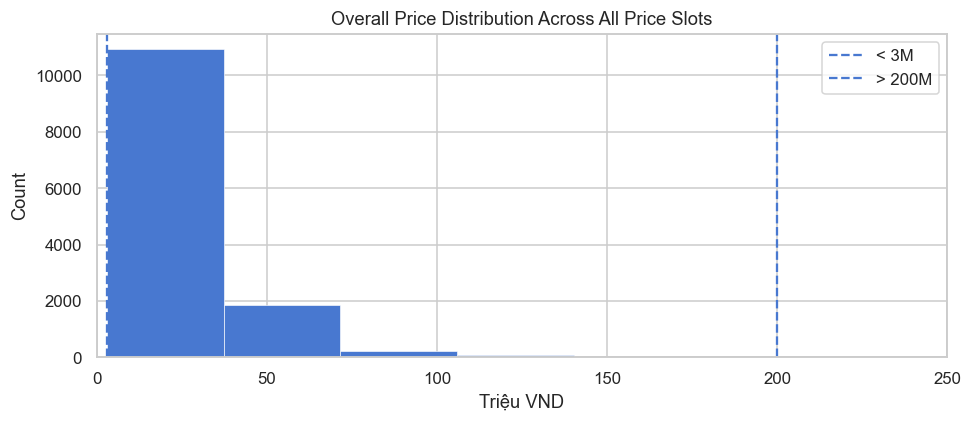

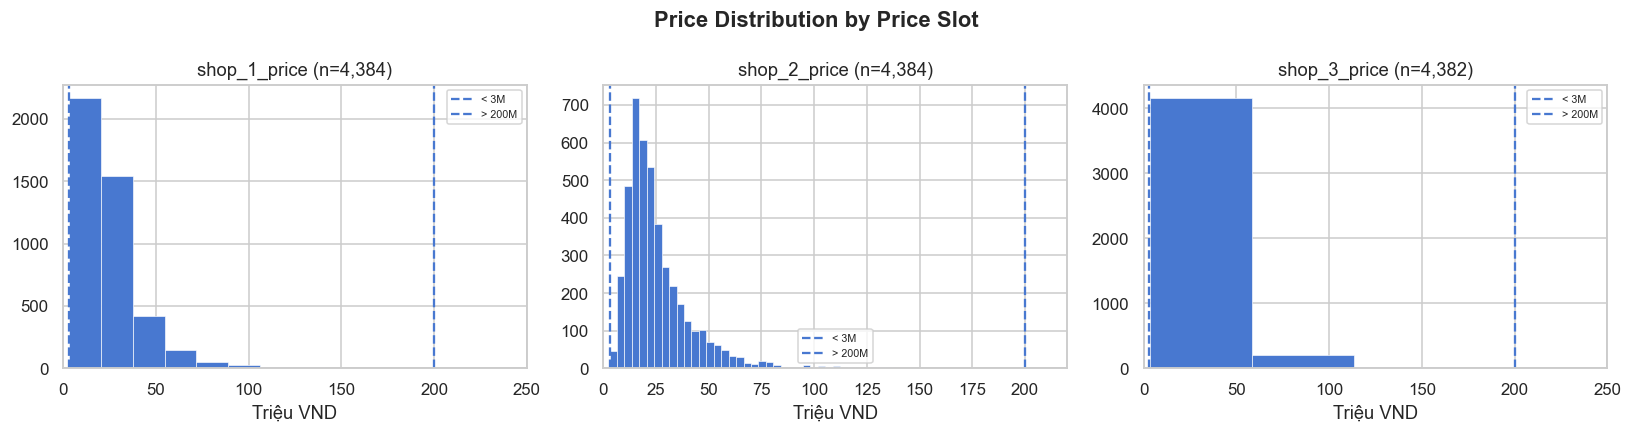

,shop_1_price,shop_2_price,shop_3_price
count,"4,384.00","4,384.00","4,382.00"
mean,25.58,25.96,27.78
std,21.55,17.40,51.09
min,3.40,3.00,3.50
25%,14.59,15.09,15.50
50%,20.69,21.25,21.70
75%,30.91,31.00,31.49
max,860.00,179.40,"2,750.00"


In [32]:
# ── 3.3 Inspect price distribution by price slot ────────────────────────────
# Lưu ý: shop_1/shop_2/shop_3 là price slots, không phải shop cố định.

s = price_long_raw["price"].dropna()

plt.figure(figsize=(9, 4))
plt.hist(s, bins=80, edgecolor="white", linewidth=0.4)
plt.axvline(PRICE_LO, linestyle="--", label=f"< {PRICE_LO}M")
plt.axvline(PRICE_HI, linestyle="--", label=f"> {PRICE_HI}M")
plt.title("Overall Price Distribution Across All Price Slots")
plt.xlabel("Triệu VND")
plt.ylabel("Count")
plt.xlim(0, min(250, max(s.max(), PRICE_HI + 20)))
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, col in zip(axes, PRICE_COLS):
    slot_prices = df[col].dropna()
    ax.hist(slot_prices, bins=50, edgecolor="white", linewidth=0.4)
    ax.axvline(PRICE_LO, linestyle="--", label=f"< {PRICE_LO}M")
    ax.axvline(PRICE_HI, linestyle="--", label=f"> {PRICE_HI}M")
    ax.set_title(f"{col} (n={slot_prices.notna().sum():,})")
    ax.set_xlabel("Triệu VND")
    ax.set_xlim(0, min(250, max(slot_prices.max(), PRICE_HI + 20)))
    ax.legend(fontsize=7)

plt.suptitle("Price Distribution by Price Slot", fontweight="bold")
plt.tight_layout()
plt.show()

display(df[PRICE_COLS].describe().round(2))

### Inspect Price Distribution by Price Slot

Biểu đồ phân phối giá cho thấy phần lớn giá laptop tập trung trong khoảng dưới **50 triệu VND** ở cả ba price slots. Giá trị trung vị của ba cột khá gần nhau: `shop_1_price` khoảng **20,69 triệu**, `shop_2_price` khoảng **21,25 triệu**, và `shop_3_price` khoảng **21,70 triệu VND**. Điều này cho thấy mặt bằng giá phổ biến giữa các nguồn giá nhìn chung tương đối đồng nhất.

Tuy nhiên, dữ liệu vẫn xuất hiện một số giá trị ngoại lệ rất lớn. Cụ thể, `shop_1_price` có giá trị lớn nhất lên đến **860 triệu VND**, trong khi `shop_3_price` có giá trị lớn nhất lên đến **2.750 triệu VND**. Các giá trị này cao bất thường so với phần lớn phân phối và có khả năng là lỗi dữ liệu, lỗi parse, hoặc giá không phù hợp với miền giá laptop phổ biến.

Vì `shop_1`, `shop_2`, `shop_3` chỉ là các price slots chứ không phải shop cố định, biểu đồ này không được dùng để so sánh shop nào đắt hơn hoặc rẻ hơn. Mục đích chính của biểu đồ là kiểm tra phân phối giá theo từng cột và phát hiện các giá trị bất thường trước khi làm sạch dữ liệu.

Dựa trên kết quả này, bước tiếp theo sẽ áp dụng bộ lọc miền giá hợp lý, trong đó các giá trị nhỏ hơn **3 triệu VND** hoặc lớn hơn **200 triệu VND** sẽ được gán thành missing value ở cấp độ từng ô giá.

In [33]:
# ── 3.4 Domain-based price filter ───────────────────────────────────────────
# Rule: giá < 3M hoặc > 200M sẽ bị null-out ở cấp độ từng ô giá.

price_raw_wide = df[PRICE_COLS].copy()

domain_bad_mask = price_raw_wide.lt(PRICE_LO) | price_raw_wide.gt(PRICE_HI)

domain_outlier_counts = pd.DataFrame({
    "domain_outlier_cells": domain_bad_mask.sum(),
    "non_null_cells": price_raw_wide.notna().sum(),
})
domain_outlier_counts["outlier_%"] = (
    domain_outlier_counts["domain_outlier_cells"]
    / domain_outlier_counts["non_null_cells"] * 100
).round(2)

print("Domain outliers by price slot:")
display(domain_outlier_counts)

# Chi tiết các cell bị domain outlier
domain_outliers_long = []

for i, (price_col, name_col) in enumerate(zip(PRICE_COLS, NAME_COLS), start=1):
    tmp = df.loc[domain_bad_mask[price_col], ["product_id", price_col, name_col]].copy()
    tmp = tmp.rename(columns={price_col: "outlier_price", name_col: "shop_name"})
    tmp["price_slot"] = f"shop_{i}"
    domain_outliers_long.append(tmp)

domain_outliers_long = pd.concat(domain_outliers_long, ignore_index=True)

print(f"Total domain outlier cells: {len(domain_outliers_long):,}")
display(domain_outliers_long.sort_values("outlier_price", ascending=False).head(30))

print("Top shop names containing domain outliers:")
display(
    domain_outliers_long["shop_name"]
    .value_counts()
    .head(20)
    .rename_axis("shop_name")
    .to_frame("domain_outlier_cells")
)

# Tạo bộ giá sau domain filter
DOMAIN_PRICE_COLS = [col.replace("_price", "_price_domain") for col in PRICE_COLS]

price_domain_wide = price_raw_wide.mask(domain_bad_mask, np.nan)
price_domain_wide.columns = DOMAIN_PRICE_COLS

df[DOMAIN_PRICE_COLS] = price_domain_wide

df["n_prices_domain"] = df[DOMAIN_PRICE_COLS].notna().sum(axis=1)

print("Số lượng giá còn lại sau domain filter:")
display(
    df["n_prices_domain"]
    .value_counts()
    .sort_index()
    .rename_axis("n_prices_domain")
    .to_frame("rows")
)

print(f"Rows không còn giá hợp lệ sau domain filter: {(df['n_prices_domain'] == 0).sum():,}")

Domain outliers by price slot:


,domain_outlier_cells,non_null_cells,outlier_%
shop_1_price,1,4384,0.02
shop_2_price,0,4384,0.00
shop_3_price,3,4382,0.07


Total domain outlier cells: 4


,product_id,outlier_price,shop_name,price_slot
1,752,"2,750.00",uristore.com.vn,shop_3
2,1614,"1,629.00",trancuong.vn,shop_3
0,432,860.00,ben.com.vn,shop_1
3,2927,268.40,cameranhapkhau.com,shop_3


Top shop names containing domain outliers:


,domain_outlier_cells
shop_name,
ben.com.vn,1
uristore.com.vn,1
trancuong.vn,1
cameranhapkhau.com,1


Số lượng giá còn lại sau domain filter:


,rows
n_prices_domain,
2,6
3,4378


Rows không còn giá hợp lệ sau domain filter: 0


### Apply Domain-Based Price Filter

Sau khi áp dụng bộ lọc miền giá hợp lý với ngưỡng **3–200 triệu VND**, chỉ có **4 ô giá** bị xác định là domain outlier. Trong đó, `shop_1_price` có **1 outlier**, `shop_2_price` không có outlier nào, và `shop_3_price` có **3 outliers**. Tỷ lệ outlier ở từng price slot đều rất thấp, chỉ khoảng **0,02%** ở `shop_1_price` và **0,07%** ở `shop_3_price`.

Các giá trị bị loại gồm những mức giá rất cao như **860 triệu**, **1.629 triệu**, **2.750 triệu**, và **268,4 triệu VND**. Đây là các mức giá vượt xa miền giá laptop thông thường và có khả năng là lỗi dữ liệu, lỗi crawl, hoặc giá không phù hợp với sản phẩm.

Sau khi null-out các giá trị ngoài miền hợp lý, không có sản phẩm nào bị mất toàn bộ thông tin giá. Có **4.378 sản phẩm** vẫn còn đủ **3 giá hợp lệ**, và **6 sản phẩm** còn **2 giá hợp lệ**. Vì vậy, dữ liệu sau bước lọc domain vẫn đủ đầy đủ để tiếp tục đo độ chênh lệch giá giữa các nguồn và tính giá tham chiếu.

Bước này chỉ loại bỏ outlier ở cấp độ từng ô giá thay vì xóa toàn bộ dòng, nhờ đó vẫn giữ lại các giá hợp lệ khác của cùng một sản phẩm.

Rows with spread > 30%: 645
Rows with spread > 50%: 204
Spread summary among products with at least 2 valid prices:


,price_spread_pct
count,"4,384.00"
mean,15.58
std,16.10
min,0.00
50%,10.16
75%,21.36
90%,36.15
95%,48.22
99%,77.43
max,133.33


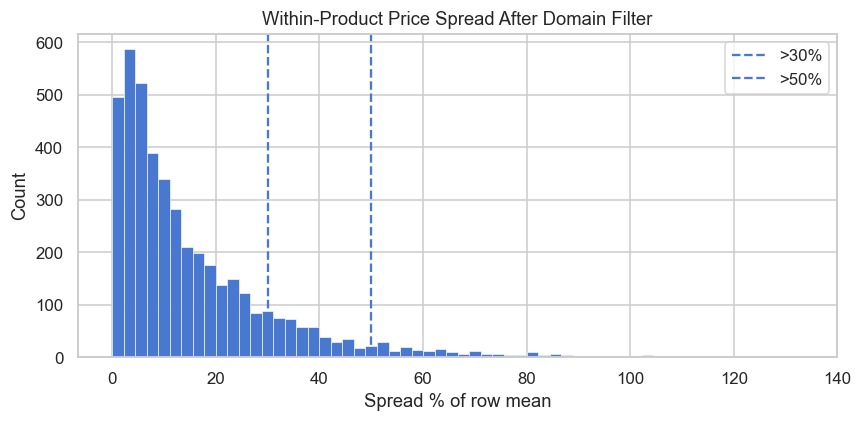

,product_id,Hãng sản xuất,Công nghệ CPU,Loại CPU,Dung lượng RAM,Loại RAM,Loại ổ cứng,Dung lượng ổ cứng (GB),Đồ họa đã làm sạch,Kích thước (inch),...,shop_3_price_domain,n_prices_domain,price_row_mean_domain,price_row_median_domain,price_row_min_domain,price_row_max_domain,price_spread_abs,price_spread_pct,flag_price_spread_warn,flag_price_spread_critical
2120,2120,Dell,Intel Core i7,11850H,32.00,DDR4,SSD,512.00,RTX Series,15.60,...,17.90,3,30.90,17.90,16.80,58.00,41.20,133.33,True,True
434,434,Dell,Intel Core i5,1245U,16.00,DR4,SSD,256.00,Intel Iris Xe,13.30,...,14.90,3,21.23,14.90,12.80,35.99,23.19,109.23,True,True
1365,1365,Lenovo,Intel Core i3,1315U,8.00,DDR4,SSD,512.00,Intel UHD Graphics,15.60,...,31.49,3,18.36,11.89,11.69,31.49,19.80,107.86,True,True
1019,1019,Hp,Intel Core i3,8130U,4.00,DDR4,HDD,500.00,Intel UHD Graphics,14.00,...,11.95,3,7.21,5.49,4.20,11.95,7.75,107.44,True,True
3389,3389,Hp,Intel Core i5,NaN,4.00,DDR4,HDD,"1,024.00",Other GPU,15.60,...,12.80,3,7.57,5.00,4.90,12.80,7.90,104.41,True,True
702,702,Dell,Intel Core i9,13950HX,64.00,DDR5,SSD,"1,024.00",RTX 5000,17.30,...,77.50,3,113.17,77.50,72.00,190.00,118.00,104.27,True,True
1950,1950,NaN,Intel Core i3,1115G4,8.00,NaN,NaN,NaN,Intel UHD Graphics,14.00,...,6.50,3,11.43,9.39,6.50,18.40,11.90,104.11,True,True
3323,3323,Hp,Intel Core i3,7100U,NaN,NaN,HDD,"1,024.00",Other GPU,15.60,...,23.99,3,14.57,10.90,8.82,23.99,15.16,104.07,True,True
3006,3006,Dell,Intel Core i7,1255U,16.00,DDR4,SSD,512.00,Intel Iris Xe,14.00,...,11.99,3,17.80,11.99,11.50,29.90,18.40,103.39,True,True
2407,2407,Hp,Intel Core 3,100U,8.00,DDR4,SSD,512.00,Other GPU,14.00,...,31.49,3,19.38,13.99,12.65,31.49,18.84,97.23,True,True


In [40]:
# ── 3.5 Measure within-product price disagreement ───────────────────────────
# Spread được tính sau domain filter.
# Spread = (max price - min price) / row mean

price_domain_wide = df[DOMAIN_PRICE_COLS].copy()

df["price_row_mean_domain"] = price_domain_wide.mean(axis=1, skipna=True)
df["price_row_median_domain"] = price_domain_wide.median(axis=1, skipna=True)
df["price_row_min_domain"] = price_domain_wide.min(axis=1, skipna=True)
df["price_row_max_domain"] = price_domain_wide.max(axis=1, skipna=True)

df["price_spread_abs"] = df["price_row_max_domain"] - df["price_row_min_domain"]

df["price_spread_pct"] = np.where(
    df["price_row_mean_domain"].gt(0),
    df["price_spread_abs"] / df["price_row_mean_domain"],
    np.nan
)

df["flag_price_spread_warn"] = (
    df["n_prices_domain"].ge(2)
    & df["price_spread_pct"].gt(SPREAD_WARN)
)

df["flag_price_spread_critical"] = (
    df["n_prices_domain"].ge(2)
    & df["price_spread_pct"].gt(SPREAD_CRITICAL)
)

print(f"Rows with spread > {SPREAD_WARN:.0%}: {df['flag_price_spread_warn'].sum():,}")
print(f"Rows with spread > {SPREAD_CRITICAL:.0%}: {df['flag_price_spread_critical'].sum():,}")

# ── Summary table: chỉ nhân 100 cho các dòng không phải count ───────────────
spread_series = df.loc[df["n_prices_domain"].ge(2), "price_spread_pct"].dropna()

spread_summary = spread_series.describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).to_frame("price_spread_pct")

spread_summary.loc[spread_summary.index != "count", "price_spread_pct"] *= 100
spread_summary["price_spread_pct"] = spread_summary["price_spread_pct"].round(2)

print("Spread summary among products with at least 2 valid prices:")
display(spread_summary)

# ── Histogram ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(
    spread_series * 100,
    bins=60,
    edgecolor="white",
    linewidth=0.4
)
plt.axvline(SPREAD_WARN * 100, linestyle="--", label=f">{SPREAD_WARN:.0%}")
plt.axvline(SPREAD_CRITICAL * 100, linestyle="--", label=f">{SPREAD_CRITICAL:.0%}")
plt.title("Within-Product Price Spread After Domain Filter")
plt.xlabel("Spread % of row mean")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# ── Inspect top high-spread products, compact view ──────────────────────────
inspect_cols = [
    "product_id",
    "Hãng sản xuất",
    "Công nghệ CPU",
    "Loại CPU",
    "Dung lượng RAM",
    "Loại RAM",
    "Loại ổ cứng",
    "Dung lượng ổ cứng (GB)",
    "Đồ họa đã làm sạch",
    "Kích thước (inch)",
    "shop_1_name",
    "shop_1_price",
    "shop_1_price_domain",
    "shop_2_name",
    "shop_2_price",
    "shop_2_price_domain",
    "shop_3_name",
    "shop_3_price",
    "shop_3_price_domain",
    "n_prices_domain",
    "price_row_mean_domain",
    "price_row_median_domain",
    "price_row_min_domain",
    "price_row_max_domain",
    "price_spread_abs",
    "price_spread_pct",
    "flag_price_spread_warn",
    "flag_price_spread_critical",
]

top_spread = (
    df.loc[df["flag_price_spread_warn"], inspect_cols]
    .sort_values("price_spread_pct", ascending=False)
    .head(10)
    .copy()
)

# Hiển thị spread dạng %
top_spread["price_spread_pct"] = (top_spread["price_spread_pct"] * 100).round(2)

# Round các cột giá cho dễ nhìn
price_like_cols = [
    "shop_1_price",
    "shop_1_price_domain",
    "shop_2_price",
    "shop_2_price_domain",
    "shop_3_price",
    "shop_3_price_domain",
    "price_row_mean_domain",
    "price_row_median_domain",
    "price_row_min_domain",
    "price_row_max_domain",
    "price_spread_abs",
]

top_spread[price_like_cols] = top_spread[price_like_cols].round(2)

display(top_spread)

### Measure Within-Product Price Spread

Sau khi áp dụng domain filter, mức độ chênh lệch giá giữa các nguồn trong cùng một sản phẩm được đo bằng chỉ số spread, tính theo công thức: `(giá cao nhất - giá thấp nhất) / giá trung bình của dòng`.

Kết quả cho thấy phần lớn sản phẩm có mức chênh lệch giá không quá cao. Median spread là **10,16%**, nghĩa là một nửa số sản phẩm có chênh lệch giữa các nguồn giá dưới khoảng 10%. Mức spread trung bình là **15,58%**, cho thấy giá giữa các nguồn nhìn chung tương đối nhất quán.

Tuy nhiên, vẫn có một nhóm sản phẩm có độ lệch giá đáng chú ý. Cụ thể, có **645 sản phẩm** có spread lớn hơn **30%**, và **204 sản phẩm** có spread lớn hơn **50%**. Phân phối spread bị lệch phải, với một số trường hợp có spread rất cao, tối đa khoảng **133,33%**. Điều này cho thấy một số sản phẩm có sự bất đồng lớn giữa các nguồn giá, có thể do lỗi crawl, giá khuyến mãi, khác biệt cấu hình chi tiết, hoặc giá niêm yết không còn phù hợp.

Vì spread cao không nhất thiết đồng nghĩa với lỗi dữ liệu, các dòng này chỉ nên được gắn cờ để kiểm tra thay vì bị xóa toàn bộ. Ở bước tiếp theo, dữ liệu sẽ tiếp tục được xử lý ở cấp độ từng ô giá bằng rule tương đối, sau đó mới tính `price_median` làm giá tham chiếu cuối cùng cho từng sản phẩm.

In [42]:
# ── Extra compact view for high-spread products ─────────────────────────────
# Mục tiêu: nhìn nhanh 3 nguồn giá và mức chênh lệch

view = (
    df.loc[df["flag_price_spread_warn"]]
    .sort_values("price_spread_pct", ascending=False)
    .head(20)
    .copy()
)

top_spread_price_view = pd.DataFrame({
    "product_id": view["product_id"],
    "brand": view["Hãng sản xuất"],
    "cpu": view["Công nghệ CPU"].astype(str) + " " + view["Loại CPU"].astype(str),
    "ram": view["Dung lượng RAM"],
    "storage": view["Dung lượng ổ cứng (GB)"],
    "gpu": view["Đồ họa đã làm sạch"],

    "shop_1": view["shop_1_name"],
    "p1": view["shop_1_price_domain"],

    "shop_2": view["shop_2_name"],
    "p2": view["shop_2_price_domain"],

    "shop_3": view["shop_3_name"],
    "p3": view["shop_3_price_domain"],

    "min": view["price_row_min_domain"],
    "max": view["price_row_max_domain"],
    "median": view["price_row_median_domain"],
    "spread_%": view["price_spread_pct"] * 100,
})

price_cols = ["p1", "p2", "p3", "min", "max", "median", "spread_%"]
top_spread_price_view[price_cols] = top_spread_price_view[price_cols].round(2)

display(top_spread_price_view)

,product_id,brand,cpu,ram,storage,gpu,shop_1,p1,shop_2,p2,shop_3,p3,min,max,median,spread_%
2120,2120,Dell,Intel Core i7 11850H,32.00,512.00,RTX Series,shopee.vn,58.00,vitinhgialoc.vn,16.80,giatin.com.vn,17.90,16.80,58.00,17.90,133.33
434,434,Dell,Intel Core i5 1245U,16.00,256.00,Intel Iris Xe,tiki.vn,35.99,mayxaugiacao.com,12.80,duyhai.vn,14.90,12.80,35.99,14.90,109.23
1365,1365,Lenovo,Intel Core i3 1315U,8.00,512.00,Intel UHD Graphics,compro.vn,11.69,kigimart.com,11.89,tnc.com.vn,31.49,11.69,31.49,11.89,107.86
1019,1019,Hp,Intel Core i3 8130U,4.00,500.00,Intel UHD Graphics,maytinhhoangha.com,4.20,mytholaptop.vn,5.49,laptopminhha.vn,11.95,4.20,11.95,5.49,107.44
3389,3389,Hp,Intel Core i5 nan,4.00,"1,024.00",Other GPU,mytholaptop.vn,4.90,laptopvienchinh.vn,5.00,compro.com.vn,12.80,4.90,12.80,5.00,104.41
702,702,Dell,Intel Core i9 13950HX,64.00,"1,024.00",RTX 5000,ben.com.vn,190.00,laptoptcc.com,72.00,hanoilab.com,77.50,72.00,190.00,77.50,104.27
1950,1950,NaN,Intel Core i3 1115G4,8.00,NaN,Intel UHD Graphics,hungphuc.vn,9.39,shopee.vn,18.40,nqkcomputer.com,6.50,6.50,18.40,9.39,104.11
3323,3323,Hp,Intel Core i3 7100U,NaN,"1,024.00",Other GPU,laptopfull.com,8.82,compro.com.vn,10.90,vitinhgiaphuc.com,23.99,8.82,23.99,10.90,104.07
3006,3006,Dell,Intel Core i7 1255U,16.00,512.00,Intel Iris Xe,shopee.vn,29.90,thanhmaistore.vn,11.50,khomacbook.com,11.99,11.50,29.90,11.99,103.39
2407,2407,Hp,Intel Core 3 100U,8.00,512.00,Other GPU,hkc.vn,12.65,laptopworld.vn,13.99,tnc.com.vn,31.49,12.65,31.49,13.99,97.23


### Inspect High-Spread Products

Bảng kiểm tra các sản phẩm có mức chênh lệch giá cao cho thấy phần lớn trường hợp spread lớn không phải do toàn bộ dòng dữ liệu bị lỗi, mà thường do **một giá trong ba nguồn lệch mạnh** so với hai giá còn lại. Ví dụ, một số sản phẩm có hai mức giá khá gần nhau nhưng giá thứ ba cao hơn đáng kể, làm cho spread của dòng tăng mạnh.

Điều này cho thấy không nên xóa toàn bộ các sản phẩm có spread cao, vì các dòng này vẫn còn chứa thông tin giá hợp lệ từ những nguồn khác. Thay vào đó, cách xử lý hợp lý hơn là làm sạch ở **cấp độ từng ô giá**. Cụ thể, sau khi đã loại bỏ các giá ngoài miền hợp lý bằng domain filter, ta tiếp tục so sánh từng giá với median của chính dòng đó để phát hiện giá lệch tương đối.

Với dữ liệu chỉ có tối đa ba nguồn giá cho mỗi sản phẩm, median là lựa chọn phù hợp hơn mean vì ít bị ảnh hưởng bởi một giá trị cực đoan. Nếu một giá nhỏ hơn **0,5 lần** hoặc lớn hơn **2 lần** median của các giá hợp lệ trong cùng sản phẩm, giá đó sẽ được xem là relative outlier và được gán thành missing value.

Chiến lược này giúp loại bỏ các giá bất thường nhưng vẫn giữ lại sản phẩm nếu còn ít nhất một hoặc hai giá hợp lệ. Sau bước này, `price_median` sẽ được tính từ các giá sạch còn lại và được sử dụng làm giá tham chiếu cuối cùng cho mỗi laptop.

Relative outliers by price slot:


,relative_outlier_cells,valid_after_domain,relative_outlier_%
shop_1_price_domain,32,4383,0.73
shop_2_price_domain,8,4384,0.18
shop_3_price_domain,13,4379,0.30


Total relative outlier cells: 53


,product_id,outlier_price,shop_name,price_anchor_median,price_spread_pct,domain_col,lower_bound,upper_bound,relative_to_median
16,2120,58.00,shopee.vn,17.90,133.33,shop_1_price_domain,8.95,35.80,3.24
43,1365,31.49,tnc.com.vn,11.89,107.86,shop_3_price_domain,5.94,23.78,2.65
52,3389,12.80,compro.com.vn,5.00,104.41,shop_3_price_domain,2.50,10.00,2.56
20,3006,29.90,shopee.vn,11.99,103.39,shop_1_price_domain,6.00,23.98,2.49
5,702,190.00,ben.com.vn,77.50,104.27,shop_1_price_domain,38.75,155.00,2.45
17,2366,79.99,ben.com.vn,33.00,97.11,shop_1_price_domain,16.50,66.00,2.42
3,434,35.99,tiki.vn,14.90,109.23,shop_1_price_domain,7.45,29.80,2.42
48,2281,50.49,xrazer.vn,21.50,93.03,shop_3_price_domain,10.75,43.00,2.35
50,2407,31.49,tnc.com.vn,13.99,97.23,shop_3_price_domain,7.00,27.98,2.25
37,2123,65.00,hkc.vn,28.99,88.13,shop_2_price_domain,14.50,57.98,2.24


Top shop names containing relative outliers:


,relative_outlier_cells
shop_name,
maytinhnhapkhau.com.vn,5
laptop36.vn,4
laptopbinhduongvtc.vn,4
tnc.com.vn,4
ben.com.vn,3
laptopthunguyen.com,2
maytinhquanganh.com,2
lap24h.vn,2
shopee.vn,2


Số lượng giá còn lại sau full cleaning:


,rows
n_prices_clean,
2,59
3,4325


Rows không còn giá hợp lệ sau full cleaning: 0


,price_median,price_mean,price_min,price_max,n_prices_clean
count,"4,384.00","4,384.00","4,384.00","4,384.00","4,384.00"
mean,26.03,26.02,24.25,27.78,2.99
std,17.39,17.35,16.68,18.25,0.12
min,3.47,3.32,3.00,3.50,2.00
25%,15.20,15.17,13.99,16.20,3.00
50%,21.19,21.15,19.77,22.62,3.00
75%,30.99,31.13,29.40,33.23,3.00
max,179.40,179.38,176.99,181.74,3.00


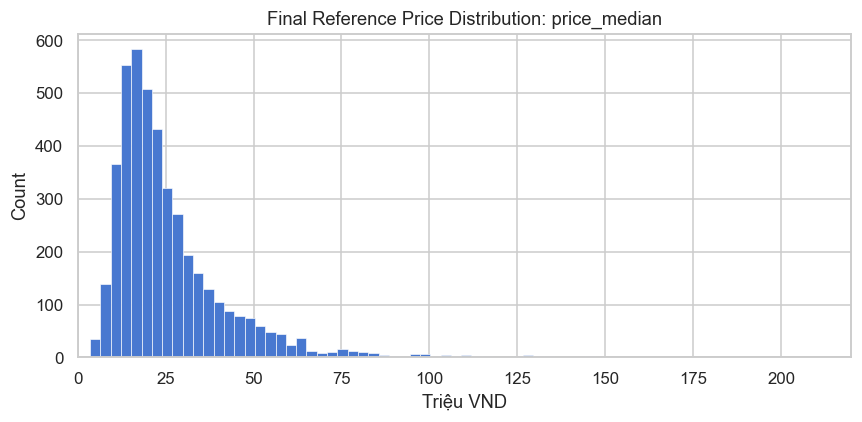

In [45]:
# ── 3.6 Cell-level relative outlier filter + reference price ────────────────
# Sau domain filter, dùng row median làm anchor.
# Null-out cell nếu price < 0.5 × row median hoặc price > 2.0 × row median.
# Lý do: nếu 1 trong 3 giá lệch mạnh, median vẫn ổn định hơn mean.

REL_LO = 0.5
REL_HI = 2.0

price_domain_wide = df[DOMAIN_PRICE_COLS].copy()

# Anchor dùng median sau domain filter
df["price_anchor_median"] = price_domain_wide.median(axis=1, skipna=True)

relative_bad_mask = pd.DataFrame(
    False,
    index=df.index,
    columns=DOMAIN_PRICE_COLS
)

for col in DOMAIN_PRICE_COLS:
    relative_bad_mask[col] = (
        df["n_prices_domain"].ge(2)
        & price_domain_wide[col].notna()
        & df["price_anchor_median"].gt(0)
        & (
            price_domain_wide[col].lt(REL_LO * df["price_anchor_median"])
            | price_domain_wide[col].gt(REL_HI * df["price_anchor_median"])
        )
    )

relative_outlier_counts = pd.DataFrame({
    "relative_outlier_cells": relative_bad_mask.sum(),
    "valid_after_domain": price_domain_wide.notna().sum(),
})

relative_outlier_counts["relative_outlier_%"] = (
    relative_outlier_counts["relative_outlier_cells"]
    / relative_outlier_counts["valid_after_domain"] * 100
).round(2)

print("Relative outliers by price slot:")
display(relative_outlier_counts)

# Chi tiết các cell bị relative outlier
relative_outliers_long = []

for domain_col, raw_col, name_col in zip(DOMAIN_PRICE_COLS, PRICE_COLS, NAME_COLS):
    tmp = df.loc[
        relative_bad_mask[domain_col],
        [
            "product_id",
            raw_col,
            name_col,
            "price_anchor_median",
            "price_spread_pct",
        ]
    ].copy()

    tmp = tmp.rename(columns={
        raw_col: "outlier_price",
        name_col: "shop_name"
    })

    tmp["domain_col"] = domain_col
    tmp["lower_bound"] = REL_LO * tmp["price_anchor_median"]
    tmp["upper_bound"] = REL_HI * tmp["price_anchor_median"]
    tmp["relative_to_median"] = tmp["outlier_price"] / tmp["price_anchor_median"]
    tmp["price_spread_pct"] = tmp["price_spread_pct"] * 100

    relative_outliers_long.append(tmp)

relative_outliers_long = pd.concat(relative_outliers_long, ignore_index=True)

round_cols = [
    "outlier_price",
    "price_anchor_median",
    "lower_bound",
    "upper_bound",
    "relative_to_median",
    "price_spread_pct",
]

relative_outliers_long[round_cols] = relative_outliers_long[round_cols].round(2)

print(f"Total relative outlier cells: {len(relative_outliers_long):,}")

display(
    relative_outliers_long
    .sort_values("relative_to_median", ascending=False)
    .head(10)
)

print("Top shop names containing relative outliers:")
display(
    relative_outliers_long["shop_name"]
    .value_counts()
    .head(10)
    .rename_axis("shop_name")
    .to_frame("relative_outlier_cells")
)

# Tạo bộ giá final sau:
# 1. domain filter
# 2. relative filter theo row median
FINAL_PRICE_COLS = [col.replace("_price", "_price_clean") for col in PRICE_COLS]

price_final_wide = price_domain_wide.mask(relative_bad_mask, np.nan)
price_final_wide.columns = FINAL_PRICE_COLS

df[FINAL_PRICE_COLS] = price_final_wide

df["n_prices_clean"] = df[FINAL_PRICE_COLS].notna().sum(axis=1)

# Giá tham chiếu cuối cùng
df["price_median"] = df[FINAL_PRICE_COLS].median(axis=1, skipna=True)
df["price_mean"] = df[FINAL_PRICE_COLS].mean(axis=1, skipna=True)
df["price_min"] = df[FINAL_PRICE_COLS].min(axis=1, skipna=True)
df["price_max"] = df[FINAL_PRICE_COLS].max(axis=1, skipna=True)

print("Số lượng giá còn lại sau full cleaning:")
display(
    df["n_prices_clean"]
    .value_counts()
    .sort_index()
    .rename_axis("n_prices_clean")
    .to_frame("rows")
)

print(f"Rows không còn giá hợp lệ sau full cleaning: {(df['n_prices_clean'] == 0).sum():,}")

display(
    df[["price_median", "price_mean", "price_min", "price_max", "n_prices_clean"]]
    .describe()
    .round(2)
)

plt.figure(figsize=(8, 4))
plt.hist(df["price_median"].dropna(), bins=60, edgecolor="white", linewidth=0.4)
plt.title("Final Reference Price Distribution: price_median")
plt.xlabel("Triệu VND")
plt.ylabel("Count")
plt.xlim(0, min(250, max(df["price_median"].dropna().max(), PRICE_HI + 20)))
plt.tight_layout()
plt.show()

### Remove Cell-Level Relative Price Outliers and Compute Reference Price

Sau bước lọc outlier tương đối theo median của từng dòng, có tổng cộng **53 ô giá** bị xác định là relative outlier. Trong đó, `shop_1_price_domain` có **32 ô outlier**, chiếm khoảng **0,73%** số giá hợp lệ sau domain filter; `shop_2_price_domain` có **8 ô outlier**, chiếm **0,18%**; và `shop_3_price_domain` có **13 ô outlier**, chiếm **0,30%**. Tỷ lệ này nhìn chung khá thấp, cho thấy rule lọc tương đối không quá mạnh tay và chỉ loại một số giá lệch rõ ràng.

Các outlier được phát hiện chủ yếu là những giá cao hơn nhiều so với median của cùng sản phẩm. Ví dụ, một số giá có tỷ lệ so với median lớn hơn **2 lần**, thậm chí có trường hợp cao hơn khoảng **3,24 lần** median. Điều này phù hợp với quan sát ở bước kiểm tra high-spread products: nhiều dòng có hai giá gần nhau nhưng một giá còn lại lệch mạnh, làm tăng spread của sản phẩm.

Sau khi loại các relative outliers, không có sản phẩm nào bị mất toàn bộ thông tin giá. Có **4.325 sản phẩm** vẫn còn đủ **3 giá sạch**, và **59 sản phẩm** còn **2 giá sạch**. Điều này cho thấy quá trình làm sạch vẫn giữ lại gần như toàn bộ dữ liệu sản phẩm, đồng thời loại bỏ được các giá bất thường ở cấp độ từng ô.

Biến `price_median` được tính từ các giá sạch còn lại và được sử dụng làm giá tham chiếu cuối cùng cho mỗi laptop. Sau khi làm sạch, `price_median` có giá trị trung bình khoảng **26,03 triệu VND**, trung vị khoảng **21,19 triệu VND**, khoảng tứ phân vị từ **15,20 triệu** đến **30,99 triệu VND**, và giá trị lớn nhất là **179,40 triệu VND**. Phân phối giá cuối cùng vẫn lệch phải, nhưng các giá trị cực đoan rất lớn như 860 triệu hoặc 2.750 triệu đã được loại bỏ.

Nhìn chung, pipeline làm sạch giá hoạt động hợp lý: chỉ loại một số lượng nhỏ giá bất thường, không làm mất dòng sản phẩm nào, và tạo ra biến `price_median` ổn định hơn để dùng cho các bước EDA và mô hình hóa tiếp theo.

In [46]:
# ── 3.7 Cleaning audit: raw vs domain vs final ──────────────────────────────

# Recompute clean spread nếu chưa có
price_clean_wide = df[FINAL_PRICE_COLS].copy()

df["price_spread_clean_abs"] = (
    price_clean_wide.max(axis=1, skipna=True)
    - price_clean_wide.min(axis=1, skipna=True)
)

df["price_spread_clean_pct"] = np.where(
    df["price_mean"].gt(0),
    df["price_spread_clean_abs"] / df["price_mean"],
    np.nan
)

# So sánh số lượng price cells qua từng stage
raw_cell_count = df[PRICE_COLS].notna().sum().sum()
domain_cell_count = df[DOMAIN_PRICE_COLS].notna().sum().sum()
clean_cell_count = df[FINAL_PRICE_COLS].notna().sum().sum()

audit = pd.DataFrame({
    "stage": ["raw", "after_domain_filter", "after_relative_filter"],
    "non_null_price_cells": [
        raw_cell_count,
        domain_cell_count,
        clean_cell_count
    ],
    "products_with_3_prices": [
        df[PRICE_COLS].notna().sum(axis=1).eq(3).sum(),
        df[DOMAIN_PRICE_COLS].notna().sum(axis=1).eq(3).sum(),
        df[FINAL_PRICE_COLS].notna().sum(axis=1).eq(3).sum()
    ],
    "products_with_2_prices": [
        df[PRICE_COLS].notna().sum(axis=1).eq(2).sum(),
        df[DOMAIN_PRICE_COLS].notna().sum(axis=1).eq(2).sum(),
        df[FINAL_PRICE_COLS].notna().sum(axis=1).eq(2).sum()
    ],
    "products_with_0_prices": [
        df[PRICE_COLS].notna().sum(axis=1).eq(0).sum(),
        df[DOMAIN_PRICE_COLS].notna().sum(axis=1).eq(0).sum(),
        df[FINAL_PRICE_COLS].notna().sum(axis=1).eq(0).sum()
    ],
})

audit["removed_cells_vs_raw"] = raw_cell_count - audit["non_null_price_cells"]
audit["removed_cells_%"] = (
    audit["removed_cells_vs_raw"] / raw_cell_count * 100
).round(2)

display(audit)

# So sánh spread trước và sau clean
def summarize_pct(series):
    out = series.dropna().describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    ).to_frame()
    out.loc[out.index != "count"] *= 100
    return out.round(2)

spread_before = df.loc[
    df["n_prices_domain"].ge(2),
    "price_spread_pct"
]

spread_after = df.loc[
    df["n_prices_clean"].ge(2),
    "price_spread_clean_pct"
]

spread_compare = pd.concat(
    [
        summarize_pct(spread_before).rename(columns={"price_spread_pct": "before_clean_%"}),
        summarize_pct(spread_after).rename(columns={"price_spread_clean_pct": "after_clean_%"})
    ],
    axis=1
)

display(spread_compare)

print(f"Rows with spread > 30% before clean: {(df['price_spread_pct'] > 0.30).sum():,}")
print(f"Rows with spread > 30% after clean : {(df['price_spread_clean_pct'] > 0.30).sum():,}")
print(f"Rows with spread > 50% before clean: {(df['price_spread_pct'] > 0.50).sum():,}")
print(f"Rows with spread > 50% after clean : {(df['price_spread_clean_pct'] > 0.50).sum():,}")

,stage,non_null_price_cells,products_with_3_prices,products_with_2_prices,products_with_0_prices,removed_cells_vs_raw,removed_cells_%
0,raw,13150,4382,2,0,0,0.00
1,after_domain_filter,13146,4378,6,0,4,0.03
2,after_relative_filter,13093,4325,59,0,57,0.43


,before_clean_%,after_clean_%
count,"4,384.00","4,384.00"
mean,15.58,14.65
std,16.10,14.24
min,0.00,0.00
50%,10.16,9.87
75%,21.36,20.54
90%,36.15,34.18
95%,48.22,44.22
99%,77.43,65.16
max,133.33,104.11


Rows with spread > 30% before clean: 645
Rows with spread > 30% after clean : 592
Rows with spread > 50% before clean: 204
Rows with spread > 50% after clean : 151


### Cleaning Audit: Raw vs Domain vs Final Price Data

Kết quả audit cho thấy quá trình làm sạch giá chỉ loại bỏ một lượng rất nhỏ dữ liệu. Ban đầu, bộ dữ liệu có **13.150 ô giá hợp lệ** từ **4.384 sản phẩm**. Sau bước domain filter, chỉ có **4 ô giá** bị loại, tương ứng khoảng **0,03%** tổng số ô giá ban đầu. Sau bước relative filter, tổng số ô giá bị loại tăng lên **57 ô**, tương ứng khoảng **0,43%**. Đây là tỷ lệ rất thấp, cho thấy pipeline làm sạch không quá mạnh tay và chủ yếu chỉ loại bỏ các giá trị bất thường rõ ràng.

Về số lượng giá còn lại trên mỗi sản phẩm, ban đầu có **4.382 sản phẩm** có đủ 3 giá và **2 sản phẩm** có 2 giá. Sau domain filter, số sản phẩm có đủ 3 giá giảm nhẹ xuống **4.378**, còn **6 sản phẩm** có 2 giá. Sau relative filter, vẫn có **4.325 sản phẩm** giữ đủ 3 giá sạch và **59 sản phẩm** còn 2 giá sạch. Đáng chú ý, không có sản phẩm nào bị mất toàn bộ giá sau quá trình làm sạch.

So sánh spread trước và sau full cleaning cho thấy mức độ chênh lệch giá giữa các nguồn đã giảm, đặc biệt ở phần đuôi phân phối. Spread trung bình giảm từ **15,58%** xuống **14,65%**, median giảm nhẹ từ **10,16%** xuống **9,87%**. Ở các phân vị cao, mức giảm rõ ràng hơn: phân vị 95% giảm từ **48,22%** xuống **44,22%**, phân vị 99% giảm từ **77,43%** xuống **65,16%**, và giá trị lớn nhất giảm từ **133,33%** xuống **104,11%**.

Số dòng có spread lớn hơn **30%** giảm từ **645** xuống **592**, và số dòng có spread lớn hơn **50%** giảm từ **204** xuống **151**. Điều này cho thấy bước relative filter đã loại bỏ được một phần các giá lệch mạnh, nhưng vẫn còn một số sản phẩm có chênh lệch giá lớn giữa các nguồn. Các dòng này không nhất thiết là lỗi dữ liệu, vì có thể phản ánh khác biệt thật giữa shop, chương trình khuyến mãi, cấu hình phụ, bảo hành hoặc tình trạng niêm yết.

Nhìn chung, pipeline cleaning đang hợp lý: dữ liệu bị loại rất ít, không mất sản phẩm nào, nhưng vẫn cải thiện được độ ổn định của giá. Vì vẫn còn một nhóm sản phẩm có spread cao sau cleaning, `price_median` tiếp tục là lựa chọn phù hợp hơn `price_mean` để làm giá tham chiếu cuối cùng.

In [51]:
# ── 3.8 Source quality diagnostics by shop_name ─────────────────────────────
# Mục tiêu: xem source nào có nhiều relative/domain outliers hoặc lệch nhiều so với price_median.

price_quality_long = []

for i, (raw_col, domain_col, clean_col, name_col) in enumerate(
    zip(PRICE_COLS, DOMAIN_PRICE_COLS, FINAL_PRICE_COLS, NAME_COLS),
    start=1
):
    tmp = df[
        [
            "product_id",
            name_col,
            raw_col,
            domain_col,
            clean_col,
            "price_median"
        ]
    ].copy()

    tmp = tmp.rename(columns={
        name_col: "shop_name",
        raw_col: "raw_price",
        domain_col: "domain_price",
        clean_col: "clean_price"
    })

    tmp["price_slot"] = f"shop_{i}"

    tmp["domain_outlier"] = (
        tmp["raw_price"].notna()
        & tmp["domain_price"].isna()
    )

    tmp["relative_outlier"] = (
        tmp["domain_price"].notna()
        & tmp["clean_price"].isna()
    )

    tmp["kept"] = tmp["clean_price"].notna()

    tmp["abs_pct_dev_from_final_median"] = np.where(
        tmp["price_median"].gt(0) & tmp["domain_price"].notna(),
        (tmp["domain_price"] - tmp["price_median"]).abs() / tmp["price_median"],
        np.nan
    )

    price_quality_long.append(tmp)

price_quality_long = pd.concat(price_quality_long, ignore_index=True)
price_quality_long = price_quality_long.dropna(subset=["shop_name"])

MIN_SHOP_OBS = 20

shop_quality = (
    price_quality_long
    .groupby("shop_name")
    .agg(
        observations=("raw_price", "count"),
        products=("product_id", "nunique"),
        kept_prices=("kept", "sum"),
        domain_outliers=("domain_outlier", "sum"),
        relative_outliers=("relative_outlier", "sum"),
        median_abs_pct_dev=("abs_pct_dev_from_final_median", "median"),
        mean_abs_pct_dev=("abs_pct_dev_from_final_median", "mean"),
    )
    .reset_index()
)

shop_quality["kept_%"] = (
    shop_quality["kept_prices"] / shop_quality["observations"] * 100
).round(2)

shop_quality["domain_outlier_%"] = (
    shop_quality["domain_outliers"] / shop_quality["observations"] * 100
).round(2)

shop_quality["relative_outlier_%"] = (
    shop_quality["relative_outliers"] / shop_quality["observations"] * 100
).round(2)

shop_quality["median_abs_pct_dev"] = (
    shop_quality["median_abs_pct_dev"] * 100
).round(2)

shop_quality["mean_abs_pct_dev"] = (
    shop_quality["mean_abs_pct_dev"] * 100
).round(2)

print("Top shops by number of observations:")
display(
    shop_quality
    .sort_values("observations", ascending=False)
    .head(10)
)

print(f"Potential noisy sources with at least {MIN_SHOP_OBS} observations:")
display(
    shop_quality
    .query("observations >= @MIN_SHOP_OBS")
    .sort_values(
        ["relative_outlier_%", "median_abs_pct_dev", "observations"],
        ascending=[False, False, False]
    )
    .head(10)
)

Top shops by number of observations:


,shop_name,observations,products,kept_prices,domain_outliers,relative_outliers,median_abs_pct_dev,mean_abs_pct_dev,kept_%,domain_outlier_%,relative_outlier_%
129,eaz.com.vn,1064,1064,1064,0,0,1.00,3.19,100.00,0.00,0.00
69,compro.com.vn,768,768,766,0,2,0.43,2.54,99.74,0.00,0.26
701,tinhocsangtao.vn,468,468,468,0,0,0.05,4.48,100.00,0.00,0.00
217,hungphuc.vn,356,356,356,0,0,0.74,3.53,100.00,0.00,0.00
604,shopee.vn,341,341,339,0,2,9.37,16.02,99.41,0.00,0.59
179,hkc.vn,320,320,319,0,1,2.75,6.18,99.69,0.00,0.31
787,vitinhmanhphat.com,302,302,302,0,0,1.19,3.35,100.00,0.00,0.00
110,dienmayxanh.com,285,285,284,0,1,3.29,6.69,99.65,0.00,0.35
58,cellphones.com.vn,277,277,277,0,0,6.59,8.36,100.00,0.00,0.00
40,ben.com.vn,269,269,265,1,3,12.42,14.95,98.51,0.37,1.12


Potential noisy sources with at least 20 observations:


,shop_name,observations,products,kept_prices,domain_outliers,relative_outliers,median_abs_pct_dev,mean_abs_pct_dev,kept_%,domain_outlier_%,relative_outlier_%
447,maytinhnhapkhau.com.vn,22,22,17,0,5,13.15,22.99,77.27,0.00,22.73
453,maytinhquanganh.com,48,48,46,0,2,8.15,12.69,95.83,0.00,4.17
347,laptoptld.com,34,34,33,0,1,8.46,13.22,97.06,0.00,2.94
729,ttcenter.com.vn,37,37,36,0,1,0.61,5.49,97.30,0.00,2.70
818,xrazer.vn,38,38,37,0,1,0.86,7.71,97.37,0.00,2.63
80,cphub.vn,40,40,39,0,1,10.68,14.46,97.50,0.00,2.50
706,tnc.com.vn,170,170,166,0,4,11.76,16.84,97.65,0.00,2.35
762,vietmob.com,57,57,56,0,1,1.31,6.33,98.25,0.00,1.75
690,tiki.vn,69,69,68,0,1,10.04,17.83,98.55,0.00,1.45
314,laptopminhha.vn,84,84,83,0,1,0.80,5.65,98.81,0.00,1.19


### Source Quality Diagnostics by Shop Name

Mặc dù `shop_1`, `shop_2`, `shop_3` không phải là các shop cố định, cột `shop_name` vẫn hữu ích để đánh giá chất lượng từng nguồn giá. Kết quả thống kê cho thấy các nguồn xuất hiện nhiều nhất gồm `eaz.com.vn`, `compro.com.vn`, `tinhocsangtao.vn`, `hungphuc.vn`, `shopee.vn`, `hkc.vn`, `vitinhmanhphat.com`, `dienmayxanh.com`, `cellphones.com.vn` và `ben.com.vn`.

Nhìn chung, các nguồn có số lượng quan sát lớn có tỷ lệ giữ lại giá rất cao. Ví dụ, `eaz.com.vn`, `tinhocsangtao.vn`, `hungphuc.vn`, `vitinhmanhphat.com` và `cellphones.com.vn` đều giữ lại **100%** giá sau quá trình làm sạch. Một số nguồn lớn như `compro.com.vn`, `shopee.vn`, `hkc.vn`, `dienmayxanh.com` và `ben.com.vn` có một vài relative outliers, nhưng tỷ lệ vẫn thấp, phần lớn dưới khoảng **1–1,5%**. Điều này cho thấy các nguồn phổ biến nhìn chung khá ổn định và không tạo ra quá nhiều giá bất thường.

Bảng noisy sources cho thấy một số nguồn có tỷ lệ relative outlier cao hơn, đặc biệt là `maytinhnhapkhau.com.vn` với **5 outliers trên 22 quan sát**, tương ứng khoảng **22,73%**. Đây là nguồn cần được chú ý vì vừa có tỷ lệ outlier cao vừa có độ lệch trung bình so với median khá lớn. Một số nguồn khác như `maytinhquanganh.com`, `laptoptld.com`, `ttcenter.com.vn`, `xrazer.vn`, `cphub.vn`, `tnc.com.vn` và `tiki.vn` cũng xuất hiện trong nhóm noisy sources, nhưng tỷ lệ outlier thấp hơn đáng kể.

Tuy nhiên, cần lưu ý rằng một số nguồn noisy có số lượng quan sát không lớn, nên tỷ lệ outlier có thể dao động mạnh. Vì vậy, không nên loại bỏ toàn bộ shop chỉ dựa trên bảng này. Thay vào đó, kết quả này nên được dùng như một bước kiểm tra chất lượng nguồn, giúp nhận diện các shop cần kiểm tra thủ công hoặc theo dõi thêm trong các lần crawl dữ liệu sau.

Nhìn chung, phần lớn nguồn giá có chất lượng tương đối tốt. Các outlier tập trung ở một số ít nguồn nhất định, và quá trình làm sạch ở cấp độ từng ô giá vẫn là chiến lược phù hợp hơn so với loại bỏ toàn bộ nguồn hoặc toàn bộ sản phẩm.

In [48]:
# ── 3.9 Feature engineering for price EDA ───────────────────────────────────

def extract_cpu_brand(x):
    if pd.isna(x):
        return "Unknown"

    s = str(x).lower()

    if "intel" in s:
        return "Intel"
    if "amd" in s or "ryzen" in s:
        return "AMD"
    if "apple" in s or "m1" in s or "m2" in s or "m3" in s:
        return "Apple"

    return "Other"


def extract_gpu_tier(x):
    if pd.isna(x):
        return "Unknown"

    s = str(x).lower()

    if "rtx 50" in s:
        return "RTX 5000"
    if "rtx 40" in s or "rtx 4060" in s or "rtx 4070" in s or "rtx 4080" in s or "rtx 4090" in s:
        return "RTX 4000"
    if "rtx 30" in s or "rtx 3050" in s or "rtx 3060" in s or "rtx 3070" in s or "rtx 3080" in s:
        return "RTX 3000"
    if "rtx" in s:
        return "Other RTX"
    if "gtx" in s:
        return "GTX"
    if "arc" in s:
        return "Intel Arc"
    if "iris" in s or "uhd" in s or "integrated" in s:
        return "Integrated"
    if "unknown" in s:
        return "Unknown"
    if "other" in s:
        return "Other GPU"

    return "Other GPU"


df["brand_clean"] = df["Hãng sản xuất"].fillna("Unknown")
df["cpu_brand"] = df["Công nghệ CPU"].apply(extract_cpu_brand)
df["gpu_tier"] = df["Đồ họa đã làm sạch"].apply(extract_gpu_tier)

df["ram_tier"] = pd.cut(
    df["Dung lượng RAM"],
    bins=[0, 4, 8, 16, 32, 64, np.inf],
    labels=["<=4GB", "8GB", "16GB", "32GB", "64GB", ">64GB"],
    right=True
).astype("object").fillna("Unknown")

df["storage_tier"] = pd.cut(
    df["Dung lượng ổ cứng (GB)"],
    bins=[0, 256, 512, 1024, 2048, np.inf],
    labels=["<=256GB", "512GB", "1TB", "2TB", ">2TB"],
    right=True
).astype("object").fillna("Unknown")

df["screen_tier"] = pd.cut(
    df["Kích thước (inch)"],
    bins=[0, 13, 14, 15.6, 16, 17, np.inf],
    labels=["<=13in", "14in", "15.6in", "16in", "17in", ">17in"],
    right=True
).astype("object").fillna("Unknown")

display(
    df[
        [
            "brand_clean",
            "cpu_brand",
            "ram_tier",
            "storage_tier",
            "gpu_tier",
            "screen_tier",
            "price_median"
        ]
    ].head(10)
)

print("Feature tier coverage:")
display(
    pd.DataFrame({
        "brand_clean": df["brand_clean"].value_counts(dropna=False).head(10),
    })
)

display(df["cpu_brand"].value_counts(dropna=False).to_frame("rows"))
display(df["ram_tier"].value_counts(dropna=False).to_frame("rows"))
display(df["storage_tier"].value_counts(dropna=False).to_frame("rows"))
display(df["gpu_tier"].value_counts(dropna=False).to_frame("rows"))

,brand_clean,cpu_brand,ram_tier,storage_tier,gpu_tier,screen_tier,price_median
0,Acer,Intel,8GB,512GB,Integrated,14in,15.95
1,Lg,Intel,16GB,512GB,Integrated,17in,35.19
2,Lenovo,AMD,16GB,512GB,RTX 4000,16in,31.49
3,Lenovo,AMD,16GB,512GB,Other RTX,15.6in,23.99
4,Msi,Intel,16GB,512GB,RTX 5000,16in,62.99
5,Unknown,Intel,64GB,>2TB,Unknown,>17in,98.19
6,Lenovo,Intel,32GB,1TB,Intel Arc,14in,43.90
7,Dell,Intel,8GB,512GB,Integrated,15.6in,12.69
8,Gigabyte,Intel,16GB,512GB,RTX 4000,16in,23.49
9,Unknown,Unknown,16GB,Unknown,Other GPU,16in,51.90


Feature tier coverage:


,brand_clean
brand_clean,
Hp,832
Dell,805
Lenovo,802
Asus,801
Acer,314
Msi,275
Unknown,180
Apple,146
Microsoft,89


,rows
cpu_brand,
Intel,3488
AMD,574
Apple,127
Other,101
Unknown,94


,rows
ram_tier,
16GB,1659
8GB,1452
<=4GB,601
32GB,568
64GB,66
Unknown,21
>64GB,17


,rows
storage_tier,
512GB,2313
1TB,1040
<=256GB,669
Unknown,225
2TB,119
>2TB,18


,rows
gpu_tier,
Integrated,1721
Other GPU,1079
Intel Arc,318
RTX 3000,310
RTX 4000,299
Unknown,207
Other RTX,158
GTX,148
RTX 5000,144


### Feature Engineering for Price Analysis

Sau khi tạo biến giá tham chiếu `price_median`, các đặc điểm cấu hình được gom nhóm thành các feature tiers để phục vụ phân tích giá. Các biến mới gồm `brand_clean`, `cpu_brand`, `ram_tier`, `storage_tier`, `gpu_tier` và `screen_tier`. Việc gom nhóm này giúp giảm độ phân mảnh của dữ liệu, đặc biệt với các trường như CPU, GPU hoặc dung lượng lưu trữ có nhiều giá trị chi tiết.

Về phân bố thương hiệu, dữ liệu tập trung chủ yếu ở các hãng lớn như **HP**, **Dell**, **Lenovo** và **Asus**, mỗi hãng có khoảng hơn **800 sản phẩm**. Các thương hiệu như **Acer** và **MSI** có số lượng thấp hơn, lần lượt khoảng **314** và **275 sản phẩm**. Ngoài ra, vẫn còn **180 sản phẩm** chưa xác định được thương hiệu, được gán vào nhóm `Unknown`.

Đối với CPU, phần lớn sản phẩm sử dụng nền tảng **Intel**, với **3.488 dòng**, chiếm ưu thế rõ rệt so với **AMD** với **574 dòng** và **Apple** với **127 dòng**. Điều này cho thấy dữ liệu laptop mới từ nguồn này thiên nhiều về các mẫu dùng CPU Intel.

Về RAM, hai nhóm phổ biến nhất là **16GB** với **1.659 sản phẩm** và **8GB** với **1.452 sản phẩm**. Nhóm **<=4GB** vẫn còn tương đối nhiều với **601 sản phẩm**, trong khi các cấu hình cao hơn như **32GB** có **568 sản phẩm**, **64GB** có **66 sản phẩm**, và **>64GB** chỉ có **17 sản phẩm**. Điều này phản ánh thị trường chủ yếu tập trung ở phân khúc RAM 8GB và 16GB.

Về dung lượng lưu trữ, nhóm **512GB** chiếm số lượng lớn nhất với **2.313 sản phẩm**, tiếp theo là **1TB** với **1.040 sản phẩm** và **<=256GB** với **669 sản phẩm**. Các cấu hình lưu trữ lớn hơn như **2TB** và **>2TB** xuất hiện ít hơn nhiều. Điều này cho thấy 512GB là mức dung lượng phổ biến nhất trong bộ dữ liệu.

Đối với GPU, nhóm **Integrated** là phổ biến nhất với **1.721 sản phẩm**, tiếp theo là **Other GPU** với **1.079 sản phẩm**. Các nhóm GPU rời như **RTX 3000**, **RTX 4000**, **RTX 5000**, **GTX** và **Other RTX** có số lượng thấp hơn nhưng vẫn đủ để phân tích giá theo phân khúc hiệu năng. Nhìn chung, các feature tiers này đủ rõ ràng để tiếp tục phân tích mối quan hệ giữa cấu hình laptop và `price_median`.

Price by brand:


,brand_clean,n,mean_price,median_price,q25_price,q75_price,min_price,max_price,iqr_price
0,Apple,146,48.99,42.17,27.22,62.00,5.50,179.40,34.78
1,Microsoft,89,32.75,32.50,21.50,42.09,6.50,72.90,20.59
2,Gigabyte,56,31.51,29.99,23.42,35.39,14.30,76.40,11.97
3,Lg,33,29.80,29.20,24.42,35.19,15.70,46.49,10.77
4,Msi,275,38.37,27.99,19.04,48.96,8.00,163.79,29.92
5,Lenovo,802,27.24,24.44,18.12,33.70,3.85,129.00,15.58
6,Unknown,180,23.75,19.94,14.84,27.80,5.50,104.90,12.96
7,Asus,801,24.93,19.29,13.73,29.00,5.19,130.75,15.27
8,Dell,805,22.68,19.00,14.49,25.59,4.00,79.80,11.10
9,Hp,832,22.17,18.90,14.25,26.62,4.20,132.58,12.37


Price by CPU brand:


,cpu_brand,n,mean_price,median_price,q25_price,q75_price,min_price,max_price,iqr_price
0,Apple,127,53.13,44.49,32.04,66.34,15.00,179.40,34.30
1,Other,101,33.09,28.99,24.74,40.49,9.08,72.90,15.75
2,Unknown,94,32.20,26.24,19.20,41.22,5.90,126.50,22.02
3,AMD,574,24.99,21.04,15.69,29.00,7.74,110.00,13.31
4,Intel,3488,24.85,20.29,14.79,29.30,3.47,163.79,14.51


Price by RAM tier:


,ram_tier,n,mean_price,median_price,q25_price,q75_price,min_price,max_price,iqr_price
0,64GB,66,85.99,84.52,64.49,104.97,32.90,153.29,40.48
1,32GB,568,45.02,42.42,31.50,54.55,15.99,132.58,23.05
2,16GB,1659,27.70,25.00,19.49,33.05,8.39,77.49,13.55
3,8GB,1452,18.72,17.80,14.37,22.02,5.70,52.72,7.65
4,<=4GB,601,12.17,12.17,9.75,14.30,3.47,48.09,4.55


Price by storage tier:


,storage_tier,n,mean_price,median_price,q25_price,q75_price,min_price,max_price,iqr_price
0,2TB,119,59.03,56.50,24.49,85.99,8.99,135.00,61.50
1,1TB,1040,34.03,30.88,17.79,45.99,4.95,132.58,28.20
2,512GB,2313,22.85,20.69,15.89,27.20,4.00,110.99,11.31
3,Unknown,225,22.91,19.69,14.63,27.63,5.50,79.99,13.00
4,<=256GB,669,17.13,14.99,11.25,20.49,3.47,51.00,9.24


Price by GPU tier:


,gpu_tier,n,mean_price,median_price,q25_price,q75_price,min_price,max_price,iqr_price
0,RTX 5000,144,53.76,42.60,35.67,62.25,24.50,163.79,26.58
1,Other RTX,158,40.13,36.95,22.92,53.70,12.50,132.58,30.78
2,RTX 4000,299,39.05,31.49,26.99,46.24,13.90,146.99,19.26
3,Intel Arc,318,32.80,29.14,23.82,39.87,13.59,67.79,16.06
4,RTX 3000,310,32.11,24.99,19.73,38.12,12.50,126.50,18.39
5,GTX,148,26.51,24.24,19.80,29.32,5.70,107.20,9.52
6,Unknown,207,25.57,20.95,15.67,27.92,6.49,110.00,12.25
7,Other GPU,1079,23.54,19.13,13.52,26.89,3.85,179.40,13.36
8,Integrated,1721,19.39,16.99,13.49,22.45,3.47,67.98,8.96


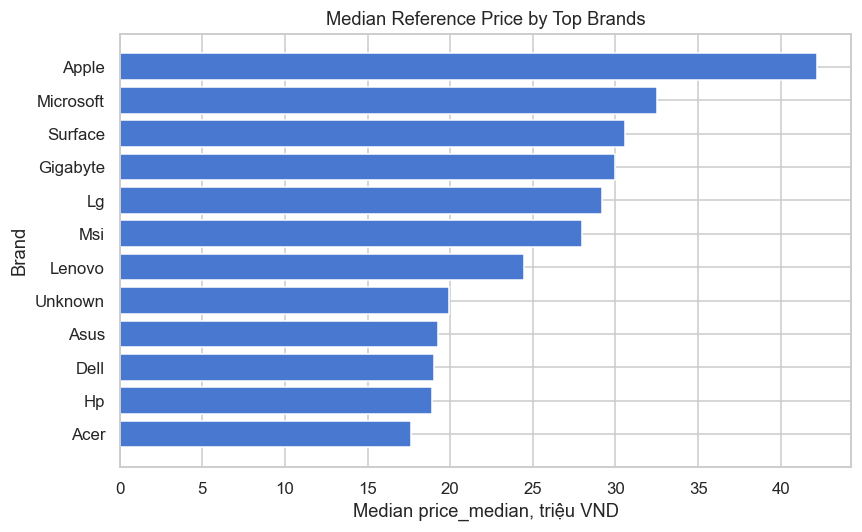

In [49]:
# ── 3.10 Price analysis by product features ─────────────────────────────────

def price_summary_by(col, min_n=30):
    out = (
        df.dropna(subset=["price_median"])
        .groupby(col)
        .agg(
            n=("price_median", "size"),
            mean_price=("price_median", "mean"),
            median_price=("price_median", "median"),
            q25_price=("price_median", lambda x: x.quantile(0.25)),
            q75_price=("price_median", lambda x: x.quantile(0.75)),
            min_price=("price_median", "min"),
            max_price=("price_median", "max"),
        )
        .reset_index()
    )

    out["iqr_price"] = out["q75_price"] - out["q25_price"]

    price_cols = [
        "mean_price",
        "median_price",
        "q25_price",
        "q75_price",
        "iqr_price",
        "min_price",
        "max_price",
    ]

    out[price_cols] = out[price_cols].round(2)

    return (
        out.query("n >= @min_n")
        .sort_values("median_price", ascending=False)
        .reset_index(drop=True)
    )


print("Price by brand:")
brand_price = price_summary_by("brand_clean", min_n=30)
display(brand_price.head(20))

print("Price by CPU brand:")
display(price_summary_by("cpu_brand", min_n=30))

print("Price by RAM tier:")
display(price_summary_by("ram_tier", min_n=30))

print("Price by storage tier:")
display(price_summary_by("storage_tier", min_n=30))

print("Price by GPU tier:")
display(price_summary_by("gpu_tier", min_n=30))

# Plot median price by top brands by volume
top_brands = (
    df["brand_clean"]
    .value_counts()
    .head(12)
    .index
)

plot_brand_price = (
    df[df["brand_clean"].isin(top_brands)]
    .groupby("brand_clean")["price_median"]
    .median()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plt.barh(plot_brand_price.index, plot_brand_price.values)
plt.title("Median Reference Price by Top Brands")
plt.xlabel("Median price_median, triệu VND")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

###  Price Analysis by Product Features

Sau khi tính `price_median`, giá tham chiếu được phân tích theo các nhóm đặc điểm sản phẩm như thương hiệu, CPU, RAM, dung lượng lưu trữ và GPU. Kết quả cho thấy giá laptop có sự khác biệt rõ rệt giữa các nhóm cấu hình.

Theo thương hiệu, **Apple** có median price cao nhất, khoảng **42,17 triệu VND**, đồng thời có khoảng giá khá rộng với Q1 khoảng **27,22 triệu** và Q3 khoảng **62,00 triệu VND**. Nhóm **Microsoft** cũng có median cao, khoảng **32,50 triệu VND**. Các thương hiệu như **Gigabyte**, **LG** và **MSI** nằm ở nhóm giá trung bình-cao, với median lần lượt khoảng **29,99 triệu**, **29,20 triệu** và **27,99 triệu VND**. Trong khi đó, các thương hiệu có số lượng lớn như **HP**, **Dell**, **Asus** và **Acer** có median thấp hơn, chủ yếu trong khoảng **17–19 triệu VND**. Điều này cho thấy các hãng phổ biến có dải sản phẩm rộng và tập trung nhiều ở phân khúc phổ thông đến trung cấp.

Theo CPU brand, nhóm **Apple** có median price cao nhất khoảng **44,49 triệu VND**, cao hơn đáng kể so với các nhóm còn lại. Nhóm **Other** và **Unknown** có median lần lượt khoảng **28,99 triệu** và **26,24 triệu VND**, nhưng cần diễn giải cẩn thận vì đây là các nhóm không đồng nhất. Hai nhóm lớn nhất là **Intel** và **AMD** có median khá gần nhau, lần lượt khoảng **20,29 triệu** và **21,04 triệu VND**. Điều này cho thấy riêng CPU brand chưa đủ để giải thích toàn bộ khác biệt giá; cần kết hợp thêm RAM, GPU, storage và thương hiệu.

Theo RAM tier, xu hướng giá tăng rất rõ khi dung lượng RAM tăng. Nhóm **<=4GB** có median khoảng **12,17 triệu VND**, nhóm **8GB** khoảng **17,80 triệu**, nhóm **16GB** khoảng **25,00 triệu**, nhóm **32GB** khoảng **42,42 triệu**, và nhóm **64GB** lên tới **84,52 triệu VND**. Đây là một trong những biến có quan hệ rõ nhất với giá tham chiếu.

Theo storage tier, giá cũng tăng theo dung lượng lưu trữ. Nhóm **<=256GB** có median khoảng **14,99 triệu VND**, nhóm **512GB** khoảng **20,69 triệu**, nhóm **1TB** khoảng **30,88 triệu**, và nhóm **2TB** khoảng **56,50 triệu VND**. Nhóm **2TB** có IQR rất lớn, cho thấy đây có thể là nhóm gồm nhiều máy cấu hình cao hoặc workstation/gaming laptop.

Theo GPU tier, nhóm **Integrated** có median thấp nhất, khoảng **16,99 triệu VND**. Các nhóm GPU rời có giá cao hơn rõ rệt: **RTX 3000** khoảng **24,99 triệu**, **RTX 4000** khoảng **31,49 triệu**, **Other RTX** khoảng **36,95 triệu**, và **RTX 5000** khoảng **42,60 triệu VND**. Điều này phản ánh tác động mạnh của GPU rời lên giá laptop, đặc biệt ở các phân khúc gaming, workstation hoặc creator laptop.

Nhìn chung, `price_median` phản ánh hợp lý cấu trúc giá theo cấu hình: giá tăng theo RAM, storage và GPU tier, đồng thời khác biệt đáng kể theo thương hiệu. Các phân tích tiếp theo nên tập trung vào tương tác giữa các nhóm cấu hình, ví dụ RAM × GPU, CPU × RAM, hoặc brand × GPU, thay vì chỉ xem từng biến riêng lẻ.

In [52]:
# ── 3.11 Inspect high-price tail after cleaning ─────────────────────────────

price_percentiles = (
    df["price_median"]
    .dropna()
    .quantile([0.5, 0.75, 0.9, 0.95, 0.99])
    .to_frame("price_median")
)

display(price_percentiles.round(2))

HIGH_PRICE_Q = 0.99
high_price_threshold = df["price_median"].quantile(HIGH_PRICE_Q)

print(f"High-price threshold P{int(HIGH_PRICE_Q * 100)}: {high_price_threshold:.2f} triệu VND")

high_price_tail = (
    df[df["price_median"] >= high_price_threshold]
    .sort_values("price_median", ascending=False)
    .copy()
)

high_tail_cols = [
    "product_id",
    "brand_clean",
    "Công nghệ CPU",
    "Loại CPU",
    "Dung lượng RAM",
    "ram_tier",
    "Loại RAM",
    "Loại ổ cứng",
    "Dung lượng ổ cứng (GB)",
    "storage_tier",
    "Đồ họa đã làm sạch",
    "gpu_tier",
    "Kích thước (inch)",
    "price_median",
    "price_min",
    "price_max",
    "n_prices_clean",
    "price_spread_clean_pct",
]

high_price_tail["price_spread_clean_pct"] = (
    high_price_tail["price_spread_clean_pct"] * 100
).round(2)

display(high_price_tail[high_tail_cols].head(20))

print("High-price tail by brand:")
display(
    high_price_tail
    .groupby("brand_clean")
    .agg(
        n=("price_median", "size"),
        median_price=("price_median", "median"),
        min_price=("price_median", "min"),
        max_price=("price_median", "max"),
    )
    .sort_values("n", ascending=False)
    .round(2)
)

print("High-price tail by GPU tier:")
display(
    high_price_tail
    .groupby("gpu_tier")
    .agg(
        n=("price_median", "size"),
        median_price=("price_median", "median"),
        min_price=("price_median", "min"),
        max_price=("price_median", "max"),
    )
    .sort_values("median_price", ascending=False)
    .round(2)
)

# Spearman correlation giữa specs số và price_median
numeric_price_cols = [
    "price_median",
    "Dung lượng RAM",
    "Dung lượng ổ cứng (GB)",
    "Kích thước (inch)",
    "n_prices_clean",
]

spearman_corr = (
    df[numeric_price_cols]
    .corr(method="spearman")
    .round(2)
)

display(spearman_corr)

,price_median
0.50,21.19
0.75,30.99
0.90,46.77
0.95,57.57
0.99,98.30


High-price threshold P99: 98.30 triệu VND


,product_id,brand_clean,Công nghệ CPU,Loại CPU,Dung lượng RAM,ram_tier,Loại RAM,Loại ổ cứng,Dung lượng ổ cứng (GB),storage_tier,Đồ họa đã làm sạch,gpu_tier,Kích thước (inch),price_median,price_min,price_max,n_prices_clean,price_spread_clean_pct
602,602,Apple,Apple M4 MAX,16-Core,128.00,>64GB,NaN,SSD,"8,192.00",>2TB,Apple GPU,Other GPU,16.00,179.40,176.99,181.74,3,2.65
3376,3376,Msi,Intel Core Ultra 9,285HX,96.00,>64GB,DDR5,SSD,"6,144.00",>2TB,RTX 5090,RTX 5000,18.00,163.79,163.00,175.00,3,7.17
1281,1281,Msi,Intel Core Ultra 9,285HX,64.00,64GB,DDR5,SSD,"6,144.00",>2TB,RTX 5090,RTX 5000,18.00,153.29,149.00,154.60,3,3.68
1417,1417,Apple,Apple M4 MAX,16-Core,128.00,>64GB,NaN,SSD,"4,096.00",>2TB,Apple GPU,Other GPU,16.20,151.89,149.90,152.34,3,1.61
4013,4013,Msi,Intel core i9,14900HX,128.00,>64GB,DDR5,SSD,"4,096.00",>2TB,RTX 4090,RTX 4000,18.00,146.99,142.49,149.05,3,4.49
981,981,Acer,Intel Core Ultra 9,275HX,192.00,>64GB,DDR5,SSD,"6,144.00",>2TB,RTX 5090,RTX 5000,18.00,144.99,134.00,149.29,3,10.71
1871,1871,Apple,Apple M4 MAX,16-Core,128.00,>64GB,NaN,SSD,"4,096.00",>2TB,Apple GPU,Other GPU,14.00,140.19,135.50,141.80,3,4.53
1028,1028,Apple,Apple M4 MAX,16-Core,128.00,>64GB,NaN,SSD,"2,048.00",2TB,Apple GPU,Other GPU,16.00,135.00,133.99,136.80,3,2.08
4030,4030,Hp,Intel Core Ultra 9,285HX,32.00,32GB,DDR5,SSD,"1,024.00",1TB,RTX Series,Other RTX,16.00,132.58,127.99,151.76,3,17.29
4174,4174,Msi,Intel Core Ultra 9,285HX,64.00,64GB,DDR5,SSD,"4,096.00",>2TB,RTX 5090,RTX 5000,18.00,131.69,130.99,131.69,3,0.53


High-price tail by brand:


,n,median_price,min_price,max_price
brand_clean,,,,
Msi,15,117.29,98.84,163.79
Apple,12,121.24,104.99,179.40
Asus,11,109.99,100.00,130.75
Acer,2,122.34,99.69,144.99
Hp,2,129.79,127.00,132.58
Lenovo,1,129.00,129.00,129.00
Unknown,1,104.90,104.90,104.90


High-price tail by GPU tier:


,n,median_price,min_price,max_price
gpu_tier,,,,
RTX 5000,13,127.00,99.99,163.79
RTX 4000,6,122.99,100.00,146.99
Other RTX,3,119.90,103.50,132.58
Other GPU,13,117.49,104.99,179.40
RTX 3000,3,110.00,99.69,126.50
Unknown,4,107.20,102.00,110.00
GTX,2,103.02,98.84,107.20


,price_median,Dung lượng RAM,Dung lượng ổ cứng (GB),Kích thước (inch),n_prices_clean
price_median,1.00,0.73,0.44,0.13,0.05
Dung lượng RAM,0.73,1.00,0.42,0.17,0.06
Dung lượng ổ cứng (GB),0.44,0.42,1.00,0.28,-0.04
Kích thước (inch),0.13,0.17,0.28,1.00,0.00
n_prices_clean,0.05,0.06,-0.04,0.00,1.00


### Inspect High-Price Tail After Cleaning

Sau khi làm sạch giá, phân phối `price_median` vẫn có phần đuôi phải, tức là tồn tại một nhóm nhỏ laptop có giá tham chiếu rất cao. Các phân vị cho thấy median toàn bộ dữ liệu là khoảng **21,19 triệu VND**, phân vị 75% là **30,99 triệu**, phân vị 90% là **46,77 triệu**, phân vị 95% là **57,57 triệu**, và phân vị 99% là **98,30 triệu VND**. Vì vậy, các sản phẩm có `price_median` từ khoảng **98,30 triệu VND** trở lên được xem là nhóm high-price tail.

Kiểm tra chi tiết nhóm high-price tail cho thấy các sản phẩm giá cao phần lớn có cấu hình rất mạnh, chẳng hạn như RAM **64GB**, **96GB**, **128GB** hoặc cao hơn, dung lượng SSD từ **1TB** đến **>2TB**, cùng CPU cao cấp như **Apple M4 Max**, **Intel Core Ultra 9**, hoặc **Intel Core i9**. Điều này cho thấy phần lớn các giá cao còn lại sau cleaning là hợp lý về mặt cấu hình, không giống các outlier cực đoan đã bị loại ở các bước trước.

Theo thương hiệu, nhóm high-price tail tập trung nhiều nhất ở **MSI**, **Apple** và **Asus**. Cụ thể, **MSI** có **15 sản phẩm**, **Apple** có **12 sản phẩm**, và **Asus** có **11 sản phẩm** trong nhóm giá cao. Median price của các nhóm này đều trên **100 triệu VND**, phản ánh các dòng máy cao cấp, gaming, workstation hoặc creator laptop.

Theo GPU tier, nhóm giá cao xuất hiện nhiều ở các phân khúc GPU mạnh như **RTX 5000**, **RTX 4000**, **Other RTX** và một phần **Other GPU**. Trong đó, **RTX 5000** có median khoảng **127 triệu VND**, cao nhất trong các nhóm GPU. Điều này phù hợp với kỳ vọng vì GPU rời cao cấp thường là một trong những yếu tố làm tăng giá laptop mạnh nhất.

Ma trận tương quan Spearman cũng cho thấy `price_median` có tương quan dương rõ rệt với **Dung lượng RAM** khoảng **0,73**, và tương quan dương vừa phải với **Dung lượng ổ cứng** khoảng **0,44**. Trong khi đó, tương quan với **Kích thước màn hình** chỉ khoảng **0,13**, cho thấy kích thước màn hình không giải thích giá mạnh bằng RAM hoặc dung lượng lưu trữ. Số lượng giá sạch (`n_prices_clean`) gần như không tương quan với `price_median`, nên việc một sản phẩm còn 2 hay 3 giá sau cleaning không ảnh hưởng đáng kể đến giá tham chiếu.

Nhìn chung, nhóm high-price tail sau cleaning có thể được giữ lại vì phần lớn phản ánh các cấu hình cao cấp thực sự, không phải lỗi dữ liệu rõ ràng. Tuy nhiên, khi xây dựng mô hình dự đoán giá, nên cân nhắc dùng log-transform cho `price_median` để giảm ảnh hưởng của đuôi phải và giúp mô hình học ổn định hơn.

---
## 4. Nhóm Identity & Display

In [13]:
# ── 4.1 Brand ───────────────────────────────────────────────────────────────
print("Hãng sản xuất:")
display(val_counts_pct(df['Hãng sản xuất']))

# Alias check: case khác nhau cho cùng brand
brands  = df['Hãng sản xuất'].dropna().unique()
suspect = [b for b in brands if b.upper() in [x.upper() for x in brands if x != b]]
if suspect:
    print(f"\nPotential alias (same name, different case): {suspect}")
else:
    print("\nKhông phát hiện alias case-sensitive.")

Hãng sản xuất:


,count,%
Hãng sản xuất,,
Hp,832,19.00
Dell,805,18.40
Lenovo,802,18.30
Asus,801,18.30
Acer,314,7.20
Msi,275,6.30
NaN,180,4.10
Apple,146,3.30
Microsoft,89,2.00



Không phát hiện alias case-sensitive.


### Brand Distribution

Phân phối **Hãng sản xuất** cho thấy dữ liệu tập trung chủ yếu vào một số thương hiệu lớn. Bốn hãng chiếm tỷ trọng cao nhất là **HP** với **832 sản phẩm** tương ứng **19,0%**, **Dell** với **805 sản phẩm** tương ứng **18,4%**, **Lenovo** với **802 sản phẩm** tương ứng **18,3%**, và **Asus** với **801 sản phẩm** tương ứng **18,3%**. Tổng cộng, bốn hãng này chiếm khoảng **74%** toàn bộ dữ liệu, cho thấy bộ dữ liệu chủ yếu đại diện cho các thương hiệu laptop phổ biến trên thị trường.

Các thương hiệu còn lại có tỷ trọng thấp hơn đáng kể. **Acer** chiếm **7,2%**, **MSI** chiếm **6,3%**, trong khi **Apple** chỉ chiếm **3,3%** và **Microsoft** chiếm **2,0%**. Một số hãng như **Gigabyte**, **LG**, **Surface**, **Samsung**, **Toshiba** và **Vaio** có số lượng mẫu rất ít, mỗi hãng chỉ chiếm từ **0,1%** đến **1,3%** dữ liệu.

Ngoài ra, có **180 dòng** bị thiếu thông tin hãng sản xuất, chiếm khoảng **4,1%**. Tỷ lệ này không quá lớn, nhưng vẫn cần xử lý trước khi phân tích hoặc xây dựng mô hình. Có thể gán các giá trị thiếu này thành nhóm `"Unknown"` thay vì loại bỏ dòng, nhằm tránh mất dữ liệu sản phẩm.

Nhìn chung, dữ liệu có hiện tượng mất cân bằng theo hãng sản xuất. Khi phân tích giá theo hãng, nên tập trung vào các hãng có số lượng mẫu đủ lớn như HP, Dell, Lenovo, Asus, Acer và MSI. Các hãng có quá ít quan sát nên được diễn giải cẩn thận hoặc gom vào nhóm `"Other"` để tránh kết luận thiếu ổn định.

In [14]:
# ── 4.2 Screen size ──────────────────────────────────────────────────────────
print("Kích thước (inch) — distribution:")
display(val_counts_pct(
    df['Kích thước (inch)'].astype(str).str.replace(r'\.0$', '', regex=True)
))

n_outlier = (df['Kích thước (inch)'] > 25).sum()
n_missing = df['Kích thước (inch)'].isna().sum()
print(f"\nOutlier > 25 inch: {n_outlier} rows")
print(f"Missing          : {n_missing} rows")

Kích thước (inch) — distribution:


,count,%
Kích thước (inch),,
14,1525,34.80
15.6,1354,30.90
16,553,12.60
13.3,299,6.80
17.3,70,1.60
16.1,64,1.50
14.5,45,1.00
13,44,1.00
13.4,41,0.90



Outlier > 25 inch: 85 rows
Missing          : 11 rows


### Screen Size Distribution

Phân phối **Kích thước màn hình** cho thấy dữ liệu tập trung chủ yếu ở các kích thước phổ biến của laptop. Nhóm **14 inch** có số lượng lớn nhất với **1.525 sản phẩm**, chiếm khoảng **34,8%** dữ liệu. Tiếp theo là nhóm **15.6 inch** với **1.354 sản phẩm**, tương ứng **30,9%**. Hai kích thước này chiếm tổng cộng khoảng **65,7%** toàn bộ dữ liệu, cho thấy phần lớn laptop trong bộ dữ liệu thuộc phân khúc màn hình phổ biến.

Ngoài ra, nhóm **16 inch** cũng xuất hiện khá nhiều với **553 sản phẩm**, chiếm **12,6%**. Các kích thước nhỏ hơn như **13.3 inch**, **13 inch**, **13.4 inch**, **13.5 inch** xuất hiện với tỷ lệ thấp hơn, chủ yếu dưới **7%** mỗi nhóm. Một số kích thước lớn hơn như **17 inch**, **17.3 inch** và **18 inch** cũng có trong dữ liệu nhưng số lượng không nhiều.

Đáng chú ý, có **85 dòng** có kích thước màn hình lớn hơn **25 inch**, đây là các giá trị bất thường đối với laptop và có khả năng là lỗi crawl, lỗi parse hoặc thông tin không phù hợp với trường dữ liệu. Ngoài ra, có **11 dòng** bị thiếu thông tin kích thước màn hình. Tỷ lệ missing khá thấp, nhưng các outlier lớn hơn 25 inch cần được xử lý trước khi phân tích sâu hoặc đưa vào mô hình.

Nhìn chung, dữ liệu kích thước màn hình phản ánh khá đúng thị trường laptop phổ biến, tập trung ở nhóm 14 inch, 15.6 inch và 16 inch. Tuy nhiên, cần null-out hoặc kiểm tra thủ công các giá trị lớn hơn 25 inch để tránh ảnh hưởng đến phân tích thống kê và mô hình hóa.

### Brand × Screen Size Heatmap

> Mỗi brand tập trung vào form factor nào — cần cho merge matching logic.

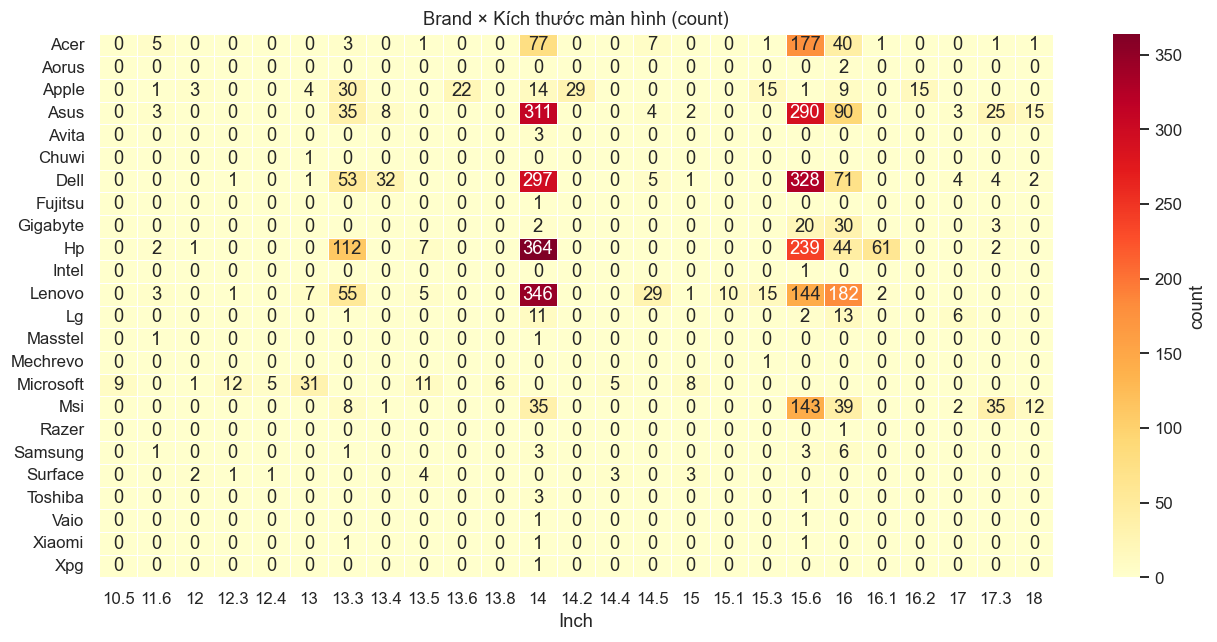

In [15]:
# ── 4.3 Brand × Screen size heatmap ─────────────────────────────────────────
screen_clean = df['Kích thước (inch)'].astype(str).str.replace(r'\.0$', '', regex=True)
brand_screen = pd.crosstab(df['Hãng sản xuất'], screen_clean)

common_screens = brand_screen.columns[brand_screen.sum() >= 5]
brand_screen   = brand_screen[common_screens]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(brand_screen, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.4, cbar_kws={'label': 'count'})
ax.set_title('Brand × Kích thước màn hình (count)')
ax.set_xlabel('Inch')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


### Brand × Screen Size Distribution

Heatmap giữa **Hãng sản xuất** và **Kích thước màn hình** cho thấy phần lớn các thương hiệu tập trung vào một số kích thước phổ biến, đặc biệt là **14 inch**, **15.6 inch** và **16 inch**. Đây cũng là ba nhóm kích thước xuất hiện nhiều nhất trong phân phối tổng thể.

Các hãng lớn như **HP**, **Dell**, **Lenovo** và **Asus** có số lượng sản phẩm cao ở cả nhóm **14 inch** và **15.6 inch**. Cụ thể, HP tập trung mạnh ở **14 inch** với **364 sản phẩm**, đồng thời cũng có nhiều mẫu **15.6 inch** với **239 sản phẩm** và **16 inch** với **44 sản phẩm**. Dell có số lượng cao ở **14 inch** với **297 sản phẩm** và **15.6 inch** với **328 sản phẩm**. Lenovo cũng tập trung ở **14 inch** với **346 sản phẩm**, **15.6 inch** với **144 sản phẩm**, và **16 inch** với **182 sản phẩm**. Asus nổi bật ở **14 inch** với **311 sản phẩm**, **15.6 inch** với **290 sản phẩm**, và **16 inch** với **90 sản phẩm**.

Một số hãng có đặc trưng kích thước riêng hơn. **Acer** có nhiều sản phẩm ở **15.6 inch** với **177 sản phẩm**, cao hơn đáng kể so với nhóm **14 inch**. **MSI** tập trung nhiều ở các kích thước lớn hơn, đặc biệt là **15.6 inch**, **16 inch** và **17.3 inch**, phù hợp với định vị gaming hoặc hiệu năng cao. **Apple** có phân phối khác biệt hơn, xuất hiện nhiều ở các kích thước **13.3 inch**, **14 inch**, **14.2 inch**, **15.3 inch**, **16 inch** và **16.2 inch**, phản ánh các dòng MacBook với kích thước màn hình đặc thù.

Heatmap cũng cho thấy một số thương hiệu có số lượng mẫu rất ít như **Vaio**, **Toshiba**, **Razer**, **Xiaomi**, **Xpg**, **Mechrevo** hoặc **Fujitsu**. Với các nhóm này, không nên đưa ra kết luận mạnh vì số lượng quan sát thấp.

Nhìn chung, kích thước màn hình có sự khác biệt theo thương hiệu, nhưng xu hướng chung của thị trường vẫn tập trung ở các kích thước phổ biến. Khi phân tích giá hoặc xây dựng mô hình, nên xem xét tương tác giữa `brand` và `screen size`, vì một số hãng có phân phối kích thước khá đặc trưng.

In [53]:
# ── 4.4 Clean and group screen size ─────────────────────────────────────────

SCREEN_COL = "Kích thước (inch)"

df["screen_size_clean"] = df[SCREEN_COL].copy()

# Null-out screen size outliers
df.loc[df["screen_size_clean"].gt(25), "screen_size_clean"] = np.nan
df.loc[df["screen_size_clean"].le(0), "screen_size_clean"] = np.nan

def screen_size_group(x):
    if pd.isna(x):
        return "Unknown"
    if x < 13:
        return "<13in"
    if x < 14:
        return "13-13.9in"
    if x < 15:
        return "14-14.9in"
    if x < 16:
        return "15-15.9in"
    if x < 17:
        return "16-16.9in"
    return ">=17in"

df["screen_size_group"] = df["screen_size_clean"].apply(screen_size_group)

print("Screen size after cleaning:")
display(
    df["screen_size_group"]
    .value_counts(dropna=False)
    .rename_axis("screen_size_group")
    .to_frame("rows")
)

print(f"Missing after screen cleaning: {df['screen_size_clean'].isna().sum():,}")

Screen size after cleaning:


,rows
screen_size_group,
14-14.9in,1609
15-15.9in,1416
16-16.9in,636
13-13.9in,443
>=17in,127
Unknown,96
<13in,57


Missing after screen cleaning: 96


###  Clean and Group Screen Size

Sau khi xử lý kích thước màn hình, các giá trị bất thường lớn hơn **25 inch** đã được gán thành missing và các kích thước hợp lệ được gom thành các nhóm màn hình. Kết quả cho thấy dữ liệu vẫn tập trung chủ yếu ở các nhóm kích thước phổ biến của laptop.

Nhóm **14–14.9 inch** có số lượng lớn nhất với **1.609 sản phẩm**, tiếp theo là nhóm **15–15.9 inch** với **1.416 sản phẩm**. Hai nhóm này chiếm phần lớn dữ liệu, phản ánh đúng xu hướng thị trường laptop phổ thông và văn phòng. Nhóm **16–16.9 inch** cũng có số lượng đáng kể với **636 sản phẩm**, thường liên quan đến các dòng máy hiệu năng cao, gaming hoặc creator laptop.

Các nhóm nhỏ hơn như **13–13.9 inch** có **443 sản phẩm**, trong khi nhóm **>=17 inch** có **127 sản phẩm** và nhóm **<13 inch** chỉ có **57 sản phẩm**. Đây là các phân khúc ít phổ biến hơn trong bộ dữ liệu.

Sau khi cleaning, có **96 dòng** bị thiếu hoặc bị chuyển thành `Unknown`, bao gồm các giá trị thiếu ban đầu và các outlier màn hình lớn hơn 25 inch. Tỷ lệ này vẫn tương đối thấp so với tổng số sản phẩm, nên không ảnh hưởng lớn đến phân tích tổng thể. Việc gom nhóm kích thước màn hình giúp giảm độ phân mảnh và phù hợp hơn cho các bước phân tích giá theo screen size.

,screen_size_group,n,mean_price,median_price,q25_price,q75_price,min_price,max_price
4,<13in,57,18.82,12.65,8.49,25.00,3.47,67.98
0,13-13.9in,443,29.48,26.50,20.56,36.68,5.50,109.99
1,14-14.9in,1609,23.37,19.35,14.25,27.63,4.35,140.19
2,15-15.9in,1416,20.90,17.60,13.69,24.20,4.00,119.90
3,16-16.9in,636,36.86,29.99,23.46,43.10,9.89,179.40
5,>=17in,127,56.17,48.29,25.67,77.43,10.99,163.79
6,Unknown,96,23.24,17.76,12.24,27.48,5.50,104.90


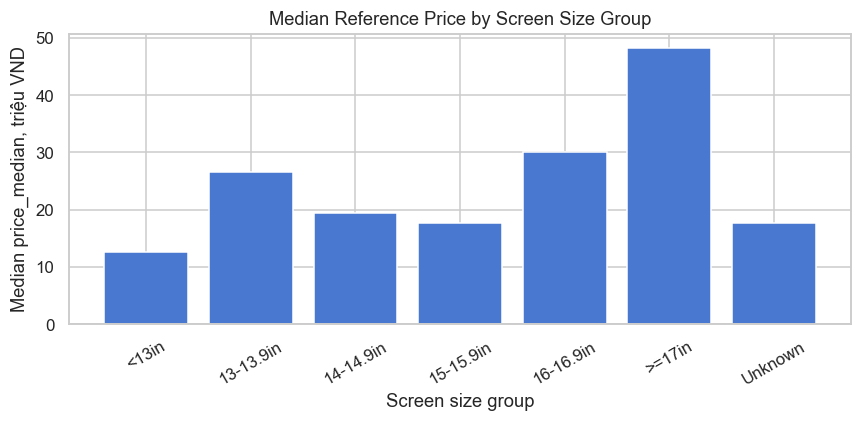

In [54]:
# ── 4.5 Price by screen size group ──────────────────────────────────────────

screen_price = (
    df.dropna(subset=["price_median"])
    .groupby("screen_size_group")
    .agg(
        n=("price_median", "size"),
        mean_price=("price_median", "mean"),
        median_price=("price_median", "median"),
        q25_price=("price_median", lambda x: x.quantile(0.25)),
        q75_price=("price_median", lambda x: x.quantile(0.75)),
        min_price=("price_median", "min"),
        max_price=("price_median", "max"),
    )
    .reset_index()
)

screen_order = ["<13in", "13-13.9in", "14-14.9in", "15-15.9in", "16-16.9in", ">=17in", "Unknown"]
screen_price["screen_size_group"] = pd.Categorical(
    screen_price["screen_size_group"],
    categories=screen_order,
    ordered=True
)

screen_price = screen_price.sort_values("screen_size_group")
price_cols = ["mean_price", "median_price", "q25_price", "q75_price", "min_price", "max_price"]
screen_price[price_cols] = screen_price[price_cols].round(2)

display(screen_price)

plt.figure(figsize=(8, 4))
plt.bar(screen_price["screen_size_group"].astype(str), screen_price["median_price"])
plt.title("Median Reference Price by Screen Size Group")
plt.xlabel("Screen size group")
plt.ylabel("Median price_median, triệu VND")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 4.5 Price by Screen Size Group

Phân tích `price_median` theo nhóm kích thước màn hình cho thấy giá laptop có xu hướng tăng ở các nhóm màn hình lớn hơn, nhưng quan hệ này không hoàn toàn tuyến tính. Nhóm **>=17 inch** có median price cao nhất, khoảng **48,29 triệu VND**, đồng thời có khoảng giá rất rộng với Q1 khoảng **25,67 triệu** và Q3 khoảng **77,43 triệu VND**. Điều này phù hợp với thực tế rằng laptop màn hình lớn thường thuộc nhóm gaming, workstation hoặc cấu hình hiệu năng cao.

Nhóm **16–16.9 inch** cũng có median price cao, khoảng **29,99 triệu VND**, cao hơn đáng kể so với nhóm **14–14.9 inch** và **15–15.9 inch**. Đây có thể là nhóm chứa nhiều laptop creator, gaming hoặc business cao cấp. Nhóm **13–13.9 inch** có median price khoảng **26,50 triệu VND**, cũng tương đối cao, có thể do nhóm này bao gồm nhiều ultrabook, MacBook hoặc laptop mỏng nhẹ cao cấp.

Trong khi đó, hai nhóm phổ biến nhất là **14–14.9 inch** và **15–15.9 inch** có median price thấp hơn, lần lượt khoảng **19,35 triệu** và **17,60 triệu VND**. Điều này cho thấy các kích thước phổ biến thường bao phủ nhiều sản phẩm phổ thông và trung cấp. Nhóm **<13 inch** có median thấp nhất, khoảng **12,65 triệu VND**, nhưng số lượng mẫu chỉ **57 sản phẩm**, nên cần diễn giải cẩn thận.

Nhìn chung, màn hình lớn hơn thường đi kèm giá cao hơn, đặc biệt từ nhóm **16 inch trở lên**. Tuy nhiên, kích thước màn hình không phải yếu tố duy nhất quyết định giá; sự khác biệt giá nhiều khả năng còn bị chi phối bởi CPU, RAM, GPU, storage và thương hiệu. Vì vậy, nên tiếp tục xem xét tương tác giữa `brand`, `screen_size_group` và `price_median`.

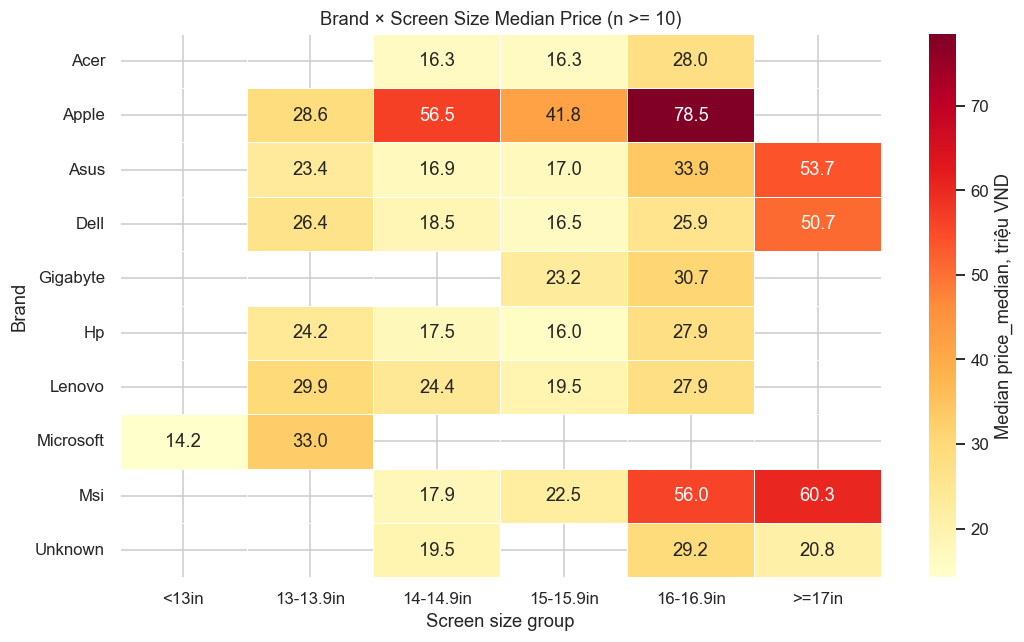

Cell counts used for filtering:


screen_size_group,<13in,13-13.9in,14-14.9in,15-15.9in,16-16.9in,>=17in
brand_clean,,,,,,
Acer,5,4,84,178,41,2
Apple,4,56,43,18,24,0
Asus,3,43,315,292,90,43
Dell,2,86,303,329,75,10
Gigabyte,0,0,2,21,30,3
Hp,3,119,364,239,105,2
Lenovo,6,67,375,170,184,0
Microsoft,28,48,5,8,0,0
Msi,0,9,35,143,39,49


In [55]:
# ── 4.6 Brand × screen size median price heatmap ────────────────────────────

MIN_CELL_N = 10

top_brands = (
    df["brand_clean"]
    .value_counts()
    .head(10)
    .index
)

tmp = df[
    df["brand_clean"].isin(top_brands)
    & df["screen_size_group"].ne("Unknown")
    & df["price_median"].notna()
].copy()

brand_screen_median = tmp.pivot_table(
    index="brand_clean",
    columns="screen_size_group",
    values="price_median",
    aggfunc="median"
)

brand_screen_count = tmp.pivot_table(
    index="brand_clean",
    columns="screen_size_group",
    values="price_median",
    aggfunc="size"
)

# Chỉ giữ các ô có đủ mẫu
brand_screen_median = brand_screen_median.where(brand_screen_count >= MIN_CELL_N)

brand_screen_median = brand_screen_median.reindex(columns=screen_order[:-1])

plt.figure(figsize=(10, 6))
sns.heatmap(
    brand_screen_median,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Median price_median, triệu VND"}
)
plt.title(f"Brand × Screen Size Median Price (n >= {MIN_CELL_N})")
plt.xlabel("Screen size group")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

print("Cell counts used for filtering:")
display(
    brand_screen_count
    .reindex(columns=screen_order[:-1])
    .fillna(0)
    .astype(int)
)

### Brand × Screen Size Median Price

Heatmap `Brand × Screen Size` theo median price cho thấy giá không chỉ phụ thuộc vào kích thước màn hình, mà còn thay đổi rõ theo từng thương hiệu. Các ô được hiển thị chỉ bao gồm những nhóm có ít nhất **10 sản phẩm**, giúp giảm nhiễu từ các nhóm quá ít quan sát.

Đối với **Apple**, giá median cao hơn rõ rệt ở hầu hết các nhóm kích thước. Nhóm **14–14.9 inch** có median khoảng **56,5 triệu VND**, nhóm **15–15.9 inch** khoảng **41,8 triệu VND**, và nhóm **16–16.9 inch** lên tới **78,5 triệu VND**. Điều này phản ánh đặc trưng của các dòng MacBook, đặc biệt là các mẫu cấu hình cao ở nhóm 14 inch và 16 inch.

Các hãng như **MSI**, **Asus** và **Dell** có giá tăng mạnh ở nhóm màn hình lớn. MSI có median khoảng **56,0 triệu VND** ở nhóm **16–16.9 inch** và **60,3 triệu VND** ở nhóm **>=17 inch**, phù hợp với định vị gaming hoặc hiệu năng cao. Asus và Dell cũng có median cao ở nhóm **>=17 inch**, lần lượt khoảng **53,7 triệu** và **50,7 triệu VND**.

Ngược lại, các hãng phổ biến như **HP**, **Lenovo**, **Acer** và **Dell** ở nhóm **14–14.9 inch** hoặc **15–15.9 inch** thường có median thấp hơn, chủ yếu nằm trong khoảng **16–25 triệu VND**. Đây là các phân khúc laptop phổ thông, văn phòng hoặc trung cấp, chiếm số lượng lớn trong dữ liệu.

Kết quả này cho thấy kích thước màn hình lớn thường đi kèm mức giá cao hơn, nhưng hiệu ứng này phụ thuộc nhiều vào thương hiệu và phân khúc sản phẩm. Ví dụ, nhóm **16 inch** của Apple hoặc MSI có giá cao hơn nhiều so với nhóm 16 inch của HP hoặc Lenovo. Vì vậy, khi phân tích giá hoặc xây dựng mô hình, nên xem xét tương tác giữa **brand** và **screen_size_group**, thay vì chỉ dùng kích thước màn hình như một biến độc lập đơn lẻ.

---
## 5. Nhóm CPU & RAM

In [56]:
# ── 5.1 CPU brand ───────────────────────────────────────────────────────────
# Mapping CPU brand dựa trên cả Công nghệ CPU và Loại CPU
# để bắt các case như Ultra 7, Ryzen 5, Snapdragon X Elite, Microsoft SQ.

CPU_TECH_COL = "Công nghệ CPU"
CPU_MODEL_COL = "Loại CPU"

def extract_cpu_brand(row):
    text = f"{row.get(CPU_TECH_COL, '')} {row.get(CPU_MODEL_COL, '')}".lower()

    # Apple Silicon
    if re.search(r"\bapple\b|\bm[1-4]\b", text):
        return "Apple"

    # Qualcomm / Snapdragon
    if "qualcomm" in text or "snapdragon" in text:
        return "Qualcomm"

    # Microsoft SQ is ARM-based, keep as separate group if present
    if "microsoft sq" in text:
        return "Microsoft SQ"

    # AMD
    if "amd" in text or "ryzen" in text:
        return "AMD"

    # Intel
    # Ultra 5/7/9, Core i3/i5/i7/i9, and common Intel model patterns
    if (
        "intel" in text
        or "core" in text
        or re.search(r"\bultra\s*[3579]\b", text)
        or re.search(r"\bi[3579]\b", text)
    ):
        return "Intel"

    return "Unknown"


df["cpu_brand"] = df.apply(extract_cpu_brand, axis=1)

print("CPU Brand:")
display(val_counts_pct(df["cpu_brand"]))

# Inspect Unknown để xác nhận còn gì chưa map được
n_unk = (df["cpu_brand"] == "Unknown").sum()

if n_unk > 0:
    print(f"\nUnknown CPU ({n_unk} rows) — sample 'Công nghệ CPU':")
    display(
        val_counts_pct(
            df.loc[df["cpu_brand"] == "Unknown", CPU_TECH_COL]
        ).head(10)
    )

    print(f"\nUnknown CPU ({n_unk} rows) — sample 'Loại CPU':")
    display(
        val_counts_pct(
            df.loc[df["cpu_brand"] == "Unknown", CPU_MODEL_COL]
        ).head(10)
    )

print("\nTop CPU models (Loại CPU):")
display(val_counts_pct(df[CPU_MODEL_COL]))

CPU Brand:


,count,%
cpu_brand,,
Intel,3544,80.80
AMD,574,13.10
Apple,133,3.00
Unknown,94,2.10
Qualcomm,35,0.80
Microsoft SQ,4,0.10



Unknown CPU (94 rows) — sample 'Công nghệ CPU':


,count,%
Công nghệ CPU,,
NaN,93,98.90
Ultra U5,1,1.10



Unknown CPU (94 rows) — sample 'Loại CPU':


,count,%
Loại CPU,,
1240P,8,8.50
12700H,7,7.40
1135G7,6,6.40
1115G4,6,6.40
NaN,5,5.30
1260P,5,5.30
1065G7,4,4.30
11800H,4,4.30
10750H,3,3.20



Top CPU models (Loại CPU):


,count,%
Loại CPU,,
1135G7,235,5.40
1235U,129,2.90
1355U,103,2.30
1165G7,101,2.30
155H,99,2.30
8265U,97,2.20
1335U,96,2.20
8250U,90,2.10
1115G4,80,1.80


### CPU Brand and CPU Model Distribution

Sau khi cải thiện mapping CPU brand bằng cách kết hợp cả `Công nghệ CPU` và `Loại CPU`, số lượng CPU bị gán vào nhóm `Unknown` đã giảm đáng kể. Kết quả mới cho thấy **Intel** vẫn chiếm ưu thế rất lớn với **3.544 sản phẩm**, tương ứng **80,8%** dữ liệu. **AMD** đứng thứ hai với **574 sản phẩm**, chiếm **13,1%**. Nhóm **Apple** có **133 sản phẩm**, chiếm **3,0%**, trong khi **Qualcomm** có **35 sản phẩm** và **Microsoft SQ** có **4 sản phẩm**.

Nhóm `Unknown` hiện còn **94 dòng**, chiếm khoảng **2,1%** dữ liệu. Trong nhóm này, phần lớn giá trị `Công nghệ CPU` là missing, với **93 dòng** bị thiếu. Tuy nhiên, nhiều dòng vẫn có `Loại CPU` như **1240P**, **12700H**, **1135G7**, **1115G4**, **1260P**, **1065G7** hoặc **11800H**. Đây là các mã CPU có thể thuộc Intel, nhưng do thiếu thông tin ở `Công nghệ CPU` nên chưa được map chính xác nếu chỉ dựa trên chuỗi mô tả đầy đủ.

Phân phối `Loại CPU` cho thấy dữ liệu CPU model khá phân mảnh. Model phổ biến nhất là **1135G7** với **235 sản phẩm**, chiếm **5,4%**, tiếp theo là **1235U** với **129 sản phẩm**, **1355U** với **103 sản phẩm**, **1165G7** với **101 sản phẩm**, và **155H** với **99 sản phẩm**. Không có model nào chiếm tỷ trọng quá lớn, cho thấy nếu dùng trực tiếp `Loại CPU` trong modeling thì có thể tạo ra nhiều nhóm nhỏ và dễ gây nhiễu.

Nhìn chung, biến `cpu_brand` sau khi mapping lại đã sạch hơn và phù hợp để dùng trong EDA. Tuy nhiên, `Loại CPU` vẫn nên được gom tiếp thành các nhóm CPU tier hoặc CPU generation thay vì dùng trực tiếp từng mã model, đặc biệt khi phân tích giá hoặc xây dựng mô hình dự đoán.

In [17]:
# ── 5.2 RAM ──────────────────────────────────────────────────────────────────
print("Dung lượng RAM (GB):")
display(val_counts_pct(
    df['Dung lượng RAM'].astype(str).str.replace(r'\.0$', '', regex=True)
))

print("\nLoại RAM:")
display(val_counts_pct(df['Loại RAM']))

Dung lượng RAM (GB):


,count,%
Dung lượng RAM,,
16,1648,37.60
8,1448,33.00
4,595,13.60
32,507,11.60
24,58,1.30
64,52,1.20
nan,21,0.50
128,12,0.30
36,9,0.20



Loại RAM:


,count,%
Loại RAM,,
DDR4,2112,48.20
DDR5,1119,25.50
NaN,318,7.30
LPDDR5x,251,5.70
LPDDR5,241,5.50
LPDDR4x,87,2.00
DDR3L,62,1.40
DDR3,60,1.40
LPDDR3,43,1.00


### RAM Capacity and RAM Type Distribution

Phân phối **Dung lượng RAM** cho thấy dữ liệu tập trung chủ yếu ở hai mức phổ biến là **16GB** và **8GB**. Cụ thể, nhóm **16GB** có **1.648 sản phẩm**, chiếm khoảng **37,6%** dữ liệu, trong khi nhóm **8GB** có **1.448 sản phẩm**, tương ứng **33,0%**. Hai nhóm này chiếm hơn **70%** toàn bộ dữ liệu, phản ánh đúng cấu hình phổ biến của laptop hiện nay.

Nhóm **4GB** cũng còn khá nhiều với **595 sản phẩm**, chiếm **13,6%**, thường đại diện cho phân khúc phổ thông hoặc cấu hình thấp. Nhóm **32GB** có **507 sản phẩm**, chiếm **11,6%**, cho thấy vẫn có một lượng đáng kể laptop thuộc phân khúc hiệu năng cao hơn. Các mức RAM lớn như **64GB**, **96GB** và **128GB** xuất hiện ít hơn nhiều, chủ yếu thuộc nhóm laptop cao cấp, workstation hoặc gaming. Ngoài ra, có **21 dòng** bị thiếu dung lượng RAM, chiếm khoảng **0,5%**, tỷ lệ này rất thấp.

Đối với **Loại RAM**, nhóm phổ biến nhất là **DDR4** với **2.112 sản phẩm**, chiếm **48,2%**, tiếp theo là **DDR5** với **1.119 sản phẩm**, chiếm **25,5%**. Các loại RAM tiết kiệm điện hoặc dùng trên ultrabook như **LPDDR5x**, **LPDDR5** và **LPDDR4x** cũng xuất hiện nhưng với tỷ lệ thấp hơn. Có **318 dòng** bị thiếu loại RAM, tương ứng **7,3%**, cao hơn đáng kể so với missing của dung lượng RAM.

Một vấn đề đáng chú ý là cột **Loại RAM** có dấu hiệu chưa chuẩn hóa hoàn toàn. Một số giá trị như **DDR5x**, **DDR5X**, **LPDDR5x**, **LPDDR5X**, hoặc các giá trị bất thường như **16** và **DR4** có thể là lỗi parse hoặc biến thể viết khác nhau của cùng một loại RAM. Vì vậy, trước khi phân tích sâu hoặc đưa vào mô hình, cần chuẩn hóa lại `Loại RAM` bằng cách viết hoa thống nhất, sửa lỗi typo và gom các biến thể tương đương.

Nhìn chung, biến **Dung lượng RAM** khá sạch và có thể dùng trực tiếp sau khi xử lý missing nhỏ. Trong khi đó, **Loại RAM** cần được chuẩn hóa thêm để tránh phân mảnh category và giảm nhiễu trong phân tích giá hoặc mô hình hóa.

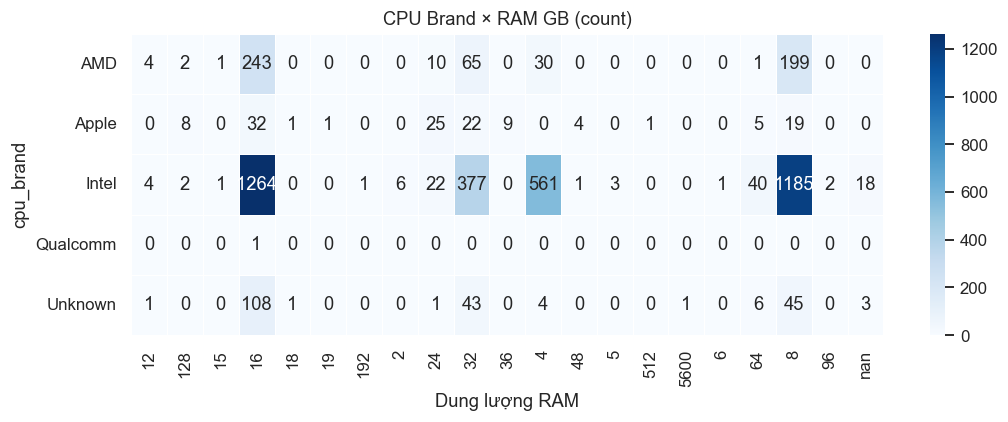

In [18]:
# ── 5.3 CPU × RAM heatmap (count) ────────────────────────────────────────────
cpu_ram = pd.crosstab(
    df['cpu_brand'],
    df['Dung lượng RAM'].astype(str).str.replace(r'\.0$', '', regex=True)
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(cpu_ram, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('CPU Brand × RAM GB (count)')
plt.tight_layout()
plt.show()

### CPU Brand × RAM Capacity

Heatmap giữa **CPU Brand** và **Dung lượng RAM** cho thấy cấu hình RAM phân bố khác nhau theo từng nền tảng CPU, nhưng dữ liệu vẫn tập trung chủ yếu ở hai mức phổ biến là **8GB** và **16GB**.

Đối với **Intel**, số lượng sản phẩm rất lớn ở cả hai nhóm **16GB** và **8GB**. Cụ thể, Intel có **1.264 sản phẩm RAM 16GB** và **1.185 sản phẩm RAM 8GB**. Ngoài ra, Intel cũng có nhiều sản phẩm ở nhóm **4GB** với **561 dòng** và **32GB** với **377 dòng**. Điều này cho thấy Intel bao phủ rất rộng từ phân khúc phổ thông đến hiệu năng cao.

Đối với **AMD**, nhóm **16GB** là phổ biến nhất với **243 sản phẩm**, tiếp theo là **8GB** với **199 sản phẩm** và **32GB** với **65 sản phẩm**. Nhóm **4GB** cũng xuất hiện nhưng ít hơn, với **30 sản phẩm**. Điều này cho thấy AMD trong bộ dữ liệu này chủ yếu xuất hiện ở phân khúc trung cấp trở lên, đặc biệt là RAM 8GB và 16GB.

Đối với **Apple**, RAM cũng tập trung nhiều ở nhóm **16GB**, **24GB**, **32GB** và **8GB**. Cụ thể, Apple có **32 sản phẩm RAM 16GB**, **25 sản phẩm RAM 24GB**, **22 sản phẩm RAM 32GB**, và **19 sản phẩm RAM 8GB**. Ngoài ra, Apple có một số cấu hình RAM cao như **64GB** và **128GB**, phù hợp với các dòng MacBook Pro cấu hình cao.

Một số giá trị RAM bất thường như **5600**, **512**, **192**, hoặc các mức lẻ như **15**, **18**, **19** có khả năng là lỗi parse hoặc thông tin bị nhầm sang tốc độ RAM/thông số khác. Các giá trị này xuất hiện với số lượng rất nhỏ nhưng cần được xử lý trước khi phân tích sâu hoặc xây dựng mô hình.

Nhìn chung, heatmap cho thấy CPU brand và dung lượng RAM có quan hệ nhất định với phân khúc sản phẩm. Intel xuất hiện ở hầu hết các mức RAM, AMD tập trung nhiều ở 8GB và 16GB, còn Apple có nhiều cấu hình RAM cao hơn. Tuy nhiên, cần làm sạch các giá trị RAM bất thường trước khi dùng biến này cho EDA giá hoặc modeling.

### Price theo CPU Brand & RAM Tier

> Hai yếu tố ảnh hưởng giá nhất — dùng để validate price_median sau merge.

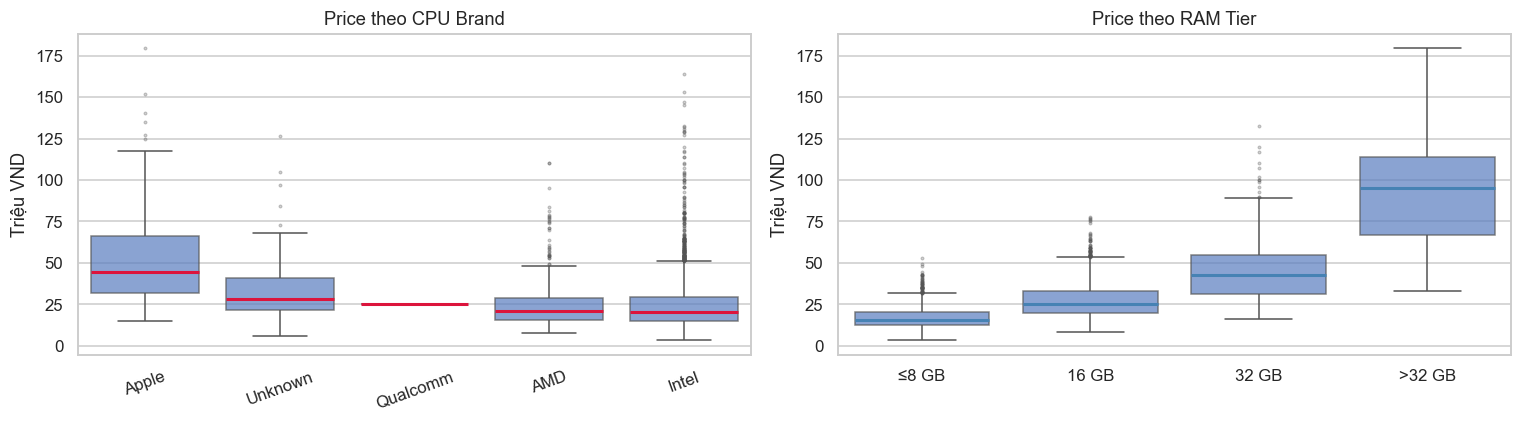

Median price theo CPU brand:


,median_price,n
cpu_brand,,
Apple,44.50,127
Unknown,27.90,213
Qualcomm,24.90,1
AMD,21.00,555
Intel,20.30,3488


In [19]:
# ── 5.4 Price by CPU brand & RAM tier ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# CPU brand
cpu_order = (
    df.groupby('cpu_brand')['price_median'].median()
    .sort_values(ascending=False).index.tolist()
)
sns.boxplot(data=df, x='cpu_brand', y='price_median', order=cpu_order,
            ax=axes[0],
            flierprops=dict(marker='.', markersize=3, alpha=0.4),
            medianprops=dict(color='crimson', linewidth=2),
            boxprops=dict(alpha=0.7))
axes[0].set_title('Price theo CPU Brand')
axes[0].set_xlabel('')
axes[0].set_ylabel('Triệu VND')
axes[0].tick_params(axis='x', rotation=20)

# RAM tier
ram_num = pd.to_numeric(df['Dung lượng RAM'], errors='coerce')
df['ram_tier'] = pd.cut(
    ram_num, bins=[0, 8, 16, 32, 999],
    labels=['≤8 GB', '16 GB', '32 GB', '>32 GB']
)
ram_order = ['≤8 GB', '16 GB', '32 GB', '>32 GB']
sns.boxplot(data=df, x='ram_tier', y='price_median', order=ram_order,
            ax=axes[1],
            flierprops=dict(marker='.', markersize=3, alpha=0.4),
            medianprops=dict(color='steelblue', linewidth=2),
            boxprops=dict(alpha=0.7))
axes[1].set_title('Price theo RAM Tier')
axes[1].set_xlabel('')
axes[1].set_ylabel('Triệu VND')

plt.tight_layout()
plt.show()

print("Median price theo CPU brand:")
display(
    df.groupby('cpu_brand')['price_median']
    .agg(['median', 'count']).round(1)
    .sort_values('median', ascending=False)
    .rename(columns={'median': 'median_price', 'count': 'n'})
)


### Price by CPU Brand and RAM Tier

Biểu đồ giá theo **CPU Brand** cho thấy nhóm **Apple** có median price cao nhất, khoảng **44,5 triệu VND**, cao hơn rõ rệt so với các nhóm còn lại. Điều này phù hợp với đặc trưng của các dòng MacBook, thường nằm ở phân khúc trung-cao đến cao cấp. Nhóm **AMD** và **Intel** có median khá gần nhau, lần lượt khoảng **21,0 triệu** và **20,3 triệu VND**, cho thấy riêng CPU brand không tạo ra khác biệt giá quá lớn giữa hai nền tảng này trong bộ dữ liệu. Nhóm **Unknown** có median khoảng **27,9 triệu VND**, nhưng cần diễn giải cẩn thận vì nhóm này có thể chứa nhiều CPU chưa được mapping đúng hoặc thiếu thông tin.

Đối với **Qualcomm**, median price khoảng **24,9 triệu VND**, nhưng nhóm này chỉ có **1 quan sát**, nên không đủ cơ sở để kết luận. Vì vậy, khi phân tích hoặc modeling, nhóm Qualcomm nên được gom với nhóm ARM/Other hoặc xử lý cẩn thận nếu số lượng mẫu quá ít.

Biểu đồ giá theo **RAM Tier** cho thấy quan hệ rất rõ giữa dung lượng RAM và giá tham chiếu. Nhóm **≤8GB** có median thấp nhất, chủ yếu nằm ở phân khúc phổ thông. Nhóm **16GB** có giá cao hơn, phản ánh phân khúc trung cấp phổ biến. Nhóm **32GB** tiếp tục tăng mạnh, trong khi nhóm **>32GB** có median cao nhất và dải giá rộng nhất, với nhiều sản phẩm nằm trên **75–100 triệu VND**. Điều này cho thấy RAM là một trong những biến có quan hệ mạnh với `price_median`.

Nhìn chung, CPU brand có ảnh hưởng nhất định đến giá, đặc biệt với nhóm Apple, nhưng **RAM tier thể hiện xu hướng giá rõ ràng hơn**. Khi xây dựng mô hình dự đoán giá, nên giữ lại cả `cpu_brand` và `ram_tier`, đồng thời cân nhắc thêm tương tác giữa CPU, RAM và GPU vì các cấu hình RAM cao thường đi kèm với CPU/GPU cao cấp.

In [64]:
# ── 5.5 Clean RAM capacity and create RAM tier ──────────────────────────────

RAM_COL = "Dung lượng RAM"

df["ram_gb_clean"] = df[RAM_COL].copy()

# Null-out RAM values không hợp lý
# Các giá trị như 512, 5600 nhiều khả năng là lỗi parse / tốc độ RAM, không phải dung lượng RAM.
df.loc[df["ram_gb_clean"].le(0), "ram_gb_clean"] = np.nan
df.loc[df["ram_gb_clean"].gt(256), "ram_gb_clean"] = np.nan

def ram_tier_group(x):
    if pd.isna(x):
        return "Unknown"
    if x <= 8:
        return "≤8 GB"
    if x == 16:
        return "16 GB"
    if x == 32:
        return "32 GB"
    if x > 32:
        return ">32 GB"
    return "Other"

df["ram_tier_clean"] = df["ram_gb_clean"].apply(ram_tier_group)

print("RAM tier after cleaning:")
display(
    df["ram_tier_clean"]
    .value_counts(dropna=False)
    .rename_axis("ram_tier_clean")
    .to_frame("rows")
)

print(f"Missing RAM after cleaning: {df['ram_gb_clean'].isna().sum():,}")

display(
    df.loc[
        df["ram_tier_clean"].eq("Other"),
        ["product_id", "brand_clean", "cpu_brand", RAM_COL, "ram_gb_clean", "price_median"]
    ]
    .head(10)
)

RAM tier after cleaning:


,rows
ram_tier_clean,
≤8 GB,2053
16 GB,1648
32 GB,507
>32 GB,81
Other,72
Unknown,23


Missing RAM after cleaning: 23


,product_id,brand_clean,cpu_brand,Dung lượng RAM,ram_gb_clean,price_median
64,64,Apple,Apple,24.00,24.00,36.79
111,111,Apple,Apple,24.00,24.00,54.50
127,127,Lenovo,Intel,24.00,24.00,32.50
194,194,Apple,Apple,24.00,24.00,76.49
240,240,Lenovo,AMD,24.00,24.00,25.99
343,343,Lenovo,Intel,24.00,24.00,28.99
450,450,Lenovo,Intel,24.00,24.00,38.29
471,471,Apple,Apple,19.00,19.00,43.89
476,476,Lenovo,AMD,12.00,12.00,20.50
556,556,Apple,Apple,24.00,24.00,70.99


### Clean RAM Capacity and Create RAM Tier

Sau khi làm sạch dung lượng RAM, các giá trị không hợp lý như RAM lớn hơn **256GB** đã được gán thành missing để tránh nhầm lẫn với tốc độ RAM hoặc thông số khác. Kết quả sau cleaning cho thấy dữ liệu RAM vẫn khá đầy đủ, chỉ còn **23 dòng** missing hoặc `Unknown`.

Phân phối RAM sau khi gom nhóm cho thấy nhóm **≤8GB** có số lượng lớn nhất với **2.053 sản phẩm**, tiếp theo là nhóm **16GB** với **1.648 sản phẩm**. Hai nhóm này chiếm phần lớn dữ liệu, phản ánh phân khúc laptop phổ thông và trung cấp. Nhóm **32GB** có **507 sản phẩm**, đại diện cho phân khúc hiệu năng cao hơn, trong khi nhóm **>32GB** chỉ có **81 sản phẩm**, chủ yếu thuộc các dòng cao cấp, gaming, workstation hoặc máy chuyên dụng.

Nhóm **Other** có **72 sản phẩm**, bao gồm các mức RAM không thuộc các tier chính như **12GB**, **18GB**, **19GB** hoặc **24GB**. Đây không nhất thiết là lỗi dữ liệu, vì một số cấu hình như **24GB** có thể xuất hiện ở các dòng Apple hoặc laptop mới. Tuy nhiên, nhóm này nên được theo dõi riêng vì không đủ lớn để tách thành nhiều nhóm nhỏ trong phân tích tổng thể.

Nhìn chung, dung lượng RAM sau cleaning có cấu trúc rõ ràng hơn và phù hợp để phân tích giá. Các nhóm RAM chính như **≤8GB**, **16GB**, **32GB** và **>32GB** có thể được dùng trực tiếp trong EDA và modeling, trong khi nhóm `Other` và `Unknown` cần được diễn giải cẩn thận.

In [60]:
# ── 5.6 Clean RAM type ──────────────────────────────────────────────────────

RAM_TYPE_COL = "Loại RAM"

def clean_ram_type(x):
    if pd.isna(x):
        return "Unknown"

    s = str(x).strip().upper()
    s = s.replace(" ", "")

    # Fix common typos / variants
    if s in ["DR4"]:
        return "DDR4"
    if s in ["DDR5X", "DDR5X.", "DDR5X"]:
        return "DDR5X"
    if s in ["LPDDR5X", "LPDDR5X"]:
        return "LPDDR5X"

    # Numeric values in RAM type are likely parsing errors
    if s.isdigit():
        return "Unknown"

    if "LPDDR5X" in s:
        return "LPDDR5X"
    if "LPDDR5" in s:
        return "LPDDR5"
    if "LPDDR4X" in s:
        return "LPDDR4X"
    if "LPDDR4" in s:
        return "LPDDR4"
    if "LPDDR3" in s:
        return "LPDDR3"

    if "DDR5" in s:
        return "DDR5"
    if "DDR4" in s:
        return "DDR4"
    if "DDR3L" in s:
        return "DDR3L"
    if "DDR3" in s:
        return "DDR3"

    return "Other"

df["ram_type_clean"] = df[RAM_TYPE_COL].apply(clean_ram_type)

print("RAM type after cleaning:")
display(
    df["ram_type_clean"]
    .value_counts(dropna=False)
    .rename_axis("ram_type_clean")
    .to_frame("rows")
)

print("RAM type before vs after:")
display(
    pd.crosstab(
        df[RAM_TYPE_COL].fillna("NaN"),
        df["ram_type_clean"]
    )
    .head(20)
)

RAM type after cleaning:


,rows
ram_type_clean,
DDR4,2119
DDR5,1120
Unknown,326
LPDDR5X,292
LPDDR5,241
LPDDR4X,88
DDR3L,62
DDR3,62
LPDDR3,43


RAM type before vs after:


ram_type_clean,DDR3,DDR3L,DDR4,DDR5,DDR5X,LPDDR3,LPDDR4,LPDDR4X,LPDDR5,LPDDR5X,Other,Unknown
Loại RAM,,,,,,,,,,,,
16,0,0,0,0,0,0,0,0,0,0,0,5
32,0,0,0,0,0,0,0,0,0,0,0,1
8,0,0,0,0,0,0,0,0,0,0,0,2
DDR3,60,0,0,0,0,0,0,0,0,0,0,0
DDR3L,0,62,0,0,0,0,0,0,0,0,0,0
DDR4,0,0,2112,0,0,0,0,0,0,0,0,0
DDR4L,0,0,2,0,0,0,0,0,0,0,0,0
DDR4X,0,0,1,0,0,0,0,0,0,0,0,0
DDR5,0,0,0,1119,0,0,0,0,0,0,0,0


### Clean RAM Type

Sau khi chuẩn hóa **Loại RAM**, các biến thể viết khác nhau và một số lỗi parse đã được gom lại thành các nhóm nhất quán hơn. Kết quả cho thấy **DDR4** là loại RAM phổ biến nhất với **2.119 sản phẩm**, tiếp theo là **DDR5** với **1.120 sản phẩm**. Đây là hai nhóm chính trong bộ dữ liệu và chiếm phần lớn quan sát.

Các loại RAM tiết kiệm điện hoặc thường xuất hiện trên ultrabook cũng có số lượng đáng kể, bao gồm **LPDDR5X** với **292 sản phẩm**, **LPDDR5** với **241 sản phẩm**, và **LPDDR4X** với **88 sản phẩm**. Các nhóm cũ hơn như **DDR3**, **DDR3L** và **LPDDR3** xuất hiện ít hơn, phản ánh các cấu hình đời cũ hoặc phân khúc thấp hơn.

Sau cleaning, vẫn còn **326 dòng** thuộc nhóm `Unknown`. Nhóm này bao gồm các giá trị thiếu ban đầu và một số trường hợp bị parse sai như giá trị số trong cột loại RAM. Ngoài ra, nhóm `Other` còn **11 dòng**, gồm các giá trị không khớp rõ với các chuẩn RAM phổ biến hoặc có khả năng là lỗi chính tả, ví dụ như `DR5`, `DRR4`, hoặc `LPDDR`.

Bảng before-vs-after cho thấy quá trình chuẩn hóa đã xử lý được nhiều biến thể như `DDR4L`, `DDR4X`, `DR4`, `DDR5x`, `DDR5X`, `LPDDR5x` và `LPDDR5X`. Điều này giúp giảm phân mảnh category và làm cho biến `ram_type_clean` phù hợp hơn để dùng trong EDA hoặc modeling.

Nhìn chung, `ram_type_clean` sau chuẩn hóa đã sạch hơn đáng kể, nhưng vẫn cần diễn giải cẩn thận với nhóm `Unknown` và `Other`. Khi phân tích giá, nên ưu tiên các nhóm có số lượng đủ lớn như DDR4, DDR5, LPDDR5X, LPDDR5 và LPDDR4X.

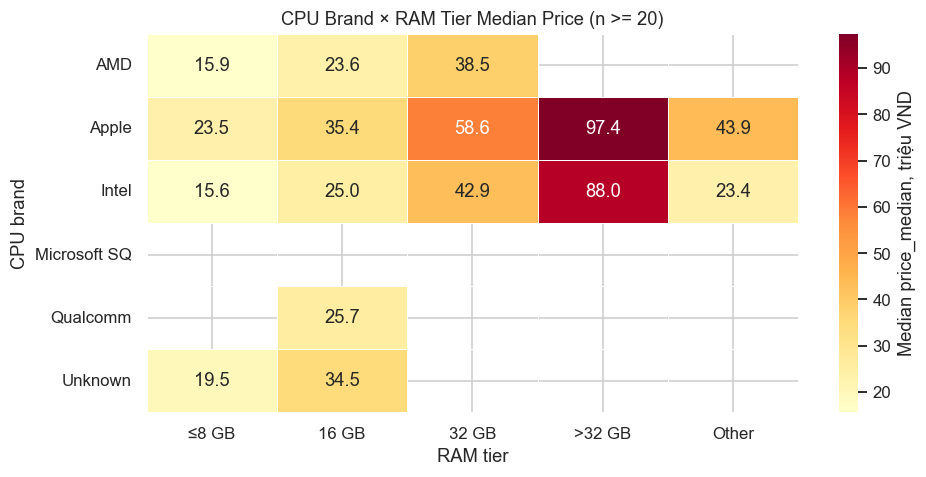

Cell counts:


ram_tier_clean,≤8 GB,16 GB,32 GB,>32 GB,Other
cpu_brand,,,,,
AMD,230,252,69,4,16
Apple,25,32,22,26,27
Intel,1753,1291,406,47,29
Microsoft SQ,2,2,0,0,0
Qualcomm,0,28,6,0,0
Unknown,43,43,4,4,0


In [61]:
# ── 5.7 Price by CPU brand × RAM tier ───────────────────────────────────────

MIN_CELL_N = 20

tmp = df[
    df["price_median"].notna()
    & df["cpu_brand"].notna()
    & df["ram_tier_clean"].notna()
    & df["ram_tier_clean"].ne("Unknown")
].copy()

cpu_ram_price = tmp.pivot_table(
    index="cpu_brand",
    columns="ram_tier_clean",
    values="price_median",
    aggfunc="median"
)

cpu_ram_count = tmp.pivot_table(
    index="cpu_brand",
    columns="ram_tier_clean",
    values="price_median",
    aggfunc="size"
)

ram_order = ["≤8 GB", "16 GB", "32 GB", ">32 GB", "Other"]
cpu_ram_price = cpu_ram_price.reindex(columns=ram_order)
cpu_ram_count = cpu_ram_count.reindex(columns=ram_order)

# Chỉ giữ cell đủ mẫu
cpu_ram_price_filtered = cpu_ram_price.where(cpu_ram_count >= MIN_CELL_N)

plt.figure(figsize=(9, 4.5))
sns.heatmap(
    cpu_ram_price_filtered,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Median price_median, triệu VND"}
)
plt.title(f"CPU Brand × RAM Tier Median Price (n >= {MIN_CELL_N})")
plt.xlabel("RAM tier")
plt.ylabel("CPU brand")
plt.tight_layout()
plt.show()

print("Cell counts:")
display(cpu_ram_count.fillna(0).astype(int))

### CPU Brand × RAM Tier Median Price

Heatmap giữa **CPU Brand** và **RAM Tier** cho thấy giá tham chiếu tăng rõ rệt khi dung lượng RAM tăng, và xu hướng này xuất hiện ở hầu hết các nền tảng CPU có đủ số lượng quan sát. Các ô được hiển thị chỉ bao gồm những nhóm có ít nhất **20 sản phẩm**, giúp giảm nhiễu từ các tổ hợp quá ít mẫu.

Đối với **Intel**, median price tăng từ khoảng **15,6 triệu VND** ở nhóm **≤8GB**, lên **25,0 triệu VND** ở nhóm **16GB**, **42,9 triệu VND** ở nhóm **32GB**, và đạt khoảng **88,0 triệu VND** ở nhóm **>32GB**. Điều này cho thấy trong hệ sinh thái Intel, RAM là một chỉ báo khá mạnh cho phân khúc giá, đặc biệt khi đi kèm các cấu hình cao cấp.

Đối với **AMD**, median price cũng tăng theo RAM, từ khoảng **15,9 triệu VND** ở nhóm **≤8GB**, lên **23,6 triệu VND** ở nhóm **16GB**, và **38,5 triệu VND** ở nhóm **32GB**. Nhóm **>32GB** của AMD chỉ có **4 quan sát**, nên không được hiển thị do không đủ ngưỡng mẫu. Nhìn chung, AMD có xu hướng tương tự Intel, nhưng số lượng mẫu ở các cấu hình RAM cao ít hơn.

Đối với **Apple**, giá median cao hơn đáng kể ở hầu hết các mức RAM. Nhóm **≤8GB** có median khoảng **23,5 triệu VND**, nhóm **16GB** khoảng **35,4 triệu VND**, nhóm **32GB** khoảng **58,6 triệu VND**, và nhóm **>32GB** lên tới **97,4 triệu VND**. Điều này phản ánh rõ phân khúc cao cấp của các dòng MacBook, đặc biệt ở cấu hình RAM lớn.

Nhóm **Qualcomm** chỉ có đủ mẫu ở RAM **16GB**, với median khoảng **25,7 triệu VND**. Nhóm **Microsoft SQ** không có ô nào được hiển thị vì số lượng quan sát quá thấp. Nhóm **Unknown** có median khoảng **19,5 triệu VND** ở **≤8GB** và **34,5 triệu VND** ở **16GB**, nhưng cần diễn giải cẩn thận do thông tin CPU chưa được xác định rõ.

Nhìn chung, kết quả cho thấy **RAM tier có quan hệ rất mạnh với giá**, ngay cả khi tách theo CPU brand. Điều này củng cố việc giữ `ram_tier_clean` làm một feature quan trọng trong phân tích giá và modeling. Tuy nhiên, cần lưu ý rằng RAM cao thường đi kèm với các yếu tố cấu hình khác như CPU mạnh hơn, GPU rời, storage lớn hơn và phân khúc thương hiệu cao hơn, nên không nên xem RAM là nguyên nhân duy nhất làm giá tăng.

CPU tier distribution:


,rows
cpu_tier,
Mid-range,1811
Upper-mid,1511
Entry,421
Unknown,304
High-end,241
Low-end,57
ARM/Other,39


,cpu_tier,n,mean_price,median_price,q25_price,q75_price,min_price,max_price
2,High-end,241,64.40,56.49,41.99,79.90,18.50,179.40
6,Upper-mid,1511,31.05,27.89,21.99,37.49,6.50,84.99
0,ARM/Other,39,29.39,26.79,21.74,32.49,15.49,72.90
5,Unknown,304,31.71,25.04,19.50,37.22,5.90,126.50
4,Mid-range,1811,19.78,17.70,14.58,22.30,4.00,109.00
1,Entry,421,11.05,10.79,9.65,12.20,4.20,31.89
3,Low-end,57,7.66,7.15,6.19,8.29,3.47,19.00


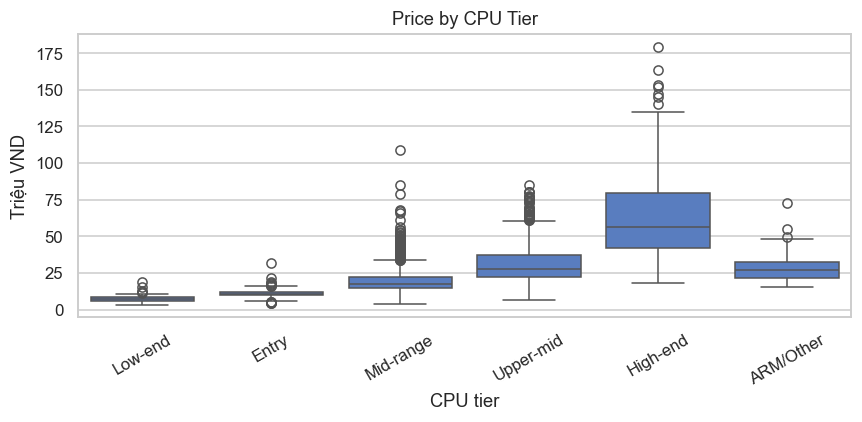

In [62]:
# ── 5.8 CPU tier extraction and price analysis ──────────────────────────────

def extract_cpu_tier(cpu_tech, cpu_model):
    text = f"{cpu_tech} {cpu_model}".lower()

    # Apple
    if "m4 max" in text or "m3 max" in text or "m2 max" in text:
        return "High-end"
    if "m4 pro" in text or "m3 pro" in text or "m2 pro" in text:
        return "Upper-mid"
    if re.search(r"\bm[1-4]\b", text):
        return "Mid-range"

    # Intel / AMD high-end
    if (
        "core ultra 9" in text
        or "ultra 9" in text
        or "core i9" in text
        or "i9" in text
        or "ryzen 9" in text
    ):
        return "High-end"

    if (
        "core ultra 7" in text
        or "ultra 7" in text
        or "core i7" in text
        or "i7" in text
        or "ryzen 7" in text
    ):
        return "Upper-mid"

    if (
        "core ultra 5" in text
        or "ultra 5" in text
        or "core i5" in text
        or "i5" in text
        or "ryzen 5" in text
    ):
        return "Mid-range"

    if (
        "core i3" in text
        or "i3" in text
        or "ryzen 3" in text
    ):
        return "Entry"

    if (
        "celeron" in text
        or "pentium" in text
        or "atom" in text
        or "n100" in text
        or "n200" in text
    ):
        return "Low-end"

    if "snapdragon" in text or "qualcomm" in text or "microsoft sq" in text:
        return "ARM/Other"

    return "Unknown"


df["cpu_tier"] = df.apply(
    lambda row: extract_cpu_tier(row["Công nghệ CPU"], row["Loại CPU"]),
    axis=1
)

print("CPU tier distribution:")
display(
    df["cpu_tier"]
    .value_counts(dropna=False)
    .rename_axis("cpu_tier")
    .to_frame("rows")
)

cpu_tier_price = (
    df.dropna(subset=["price_median"])
    .groupby("cpu_tier")
    .agg(
        n=("price_median", "size"),
        mean_price=("price_median", "mean"),
        median_price=("price_median", "median"),
        q25_price=("price_median", lambda x: x.quantile(0.25)),
        q75_price=("price_median", lambda x: x.quantile(0.75)),
        min_price=("price_median", "min"),
        max_price=("price_median", "max"),
    )
    .reset_index()
)

price_cols = ["mean_price", "median_price", "q25_price", "q75_price", "min_price", "max_price"]
cpu_tier_price[price_cols] = cpu_tier_price[price_cols].round(2)

display(
    cpu_tier_price
    .sort_values("median_price", ascending=False)
)

plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df[df["cpu_tier"].ne("Unknown")],
    x="cpu_tier",
    y="price_median",
    order=["Low-end", "Entry", "Mid-range", "Upper-mid", "High-end", "ARM/Other"]
)
plt.title("Price by CPU Tier")
plt.xlabel("CPU tier")
plt.ylabel("Triệu VND")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### CPU Tier and Price Distribution

Sau khi gom CPU thành các nhóm tier, dữ liệu tập trung chủ yếu ở hai phân khúc **Mid-range** và **Upper-mid**. Nhóm **Mid-range** có **1.811 sản phẩm**, là nhóm lớn nhất, tiếp theo là **Upper-mid** với **1.511 sản phẩm**. Nhóm **Entry** có **421 sản phẩm**, trong khi **High-end** có **241 sản phẩm**. Các nhóm **Low-end** và **ARM/Other** có số lượng ít hơn, lần lượt là **57** và **39 sản phẩm**. Ngoài ra, vẫn còn **304 sản phẩm** thuộc nhóm `Unknown`, cho thấy vẫn có một phần CPU chưa được phân loại rõ.

Phân tích giá theo CPU tier cho thấy giá tham chiếu tăng khá rõ theo cấp CPU. Nhóm **Low-end** có median price thấp nhất, khoảng **7,15 triệu VND**, tiếp theo là **Entry** với khoảng **10,79 triệu VND**. Nhóm **Mid-range** có median khoảng **17,70 triệu VND**, trong khi **Upper-mid** tăng lên khoảng **27,89 triệu VND**. Nhóm **High-end** có median cao nhất, khoảng **56,49 triệu VND**, đồng thời có khoảng giá rất rộng với Q1 khoảng **41,99 triệu** và Q3 khoảng **79,90 triệu VND**.

Biểu đồ boxplot cũng cho thấy sự khác biệt rõ ràng giữa các tier. Các nhóm thấp như **Low-end** và **Entry** có phân phối giá hẹp và tập trung ở mức thấp. Ngược lại, nhóm **High-end** có độ phân tán lớn và nhiều giá trị cao, phù hợp với các dòng laptop gaming, workstation, creator hoặc MacBook cấu hình mạnh. Nhóm **Upper-mid** cũng có một số outlier giá cao, nhưng median vẫn thấp hơn đáng kể so với High-end.

Nhóm **ARM/Other** có median khoảng **26,79 triệu VND**, gần với nhóm Upper-mid, nhưng số lượng mẫu chỉ **39 sản phẩm**, nên cần diễn giải thận trọng. Nhóm **Unknown** có median khoảng **25,04 triệu VND**, cho thấy một số CPU chưa phân loại có thể thuộc phân khúc trung hoặc cao, không nên tự động xem là cấu hình thấp.

Nhìn chung, `cpu_tier` giải thích cấu trúc giá tốt hơn `cpu_brand`, vì nó phản ánh cấp hiệu năng của CPU thay vì chỉ là nhà sản xuất. Biến này nên được giữ lại cho EDA và modeling, đồng thời có thể kết hợp thêm với RAM tier, GPU tier và brand để phân tích giá chính xác hơn.

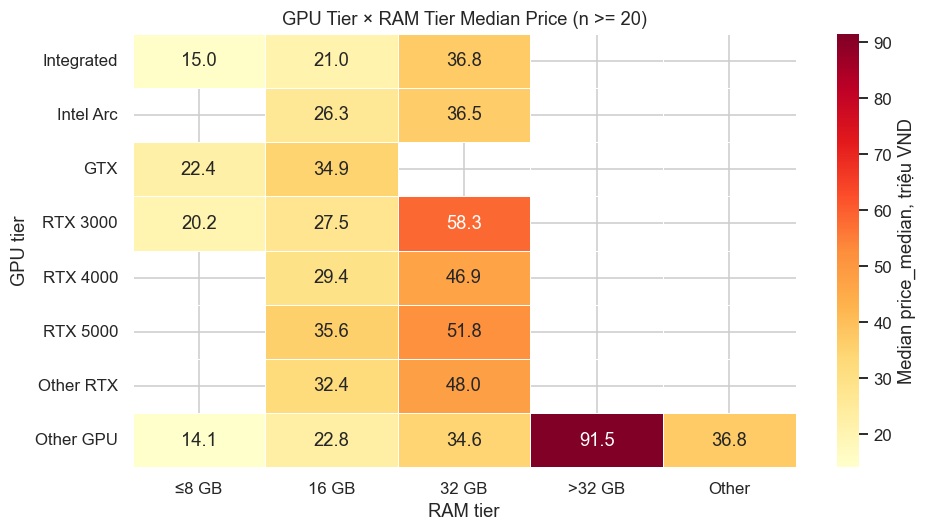

Cell counts:


ram_tier_clean,≤8 GB,16 GB,32 GB,>32 GB,Other
gpu_tier,,,,,
Integrated,1097,570,39,0,5
Intel Arc,4,183,123,4,4
GTX,111,31,6,0,0
RTX 3000,98,167,36,4,5
RTX 4000,19,174,82,15,7
RTX 5000,0,64,56,19,5
Other RTX,18,70,62,5,3
Other GPU,553,350,95,30,43


In [63]:
# ── 5.9 RAM tier × GPU tier median price ────────────────────────────────────

MIN_CELL_N = 20

tmp = df[
    df["price_median"].notna()
    & df["ram_tier_clean"].notna()
    & df["gpu_tier"].notna()
    & df["ram_tier_clean"].ne("Unknown")
    & df["gpu_tier"].ne("Unknown")
].copy()

ram_gpu_price = tmp.pivot_table(
    index="gpu_tier",
    columns="ram_tier_clean",
    values="price_median",
    aggfunc="median"
)

ram_gpu_count = tmp.pivot_table(
    index="gpu_tier",
    columns="ram_tier_clean",
    values="price_median",
    aggfunc="size"
)

gpu_order = [
    "Integrated",
    "Intel Arc",
    "GTX",
    "RTX 3000",
    "RTX 4000",
    "RTX 5000",
    "Other RTX",
    "Other GPU",
]

ram_gpu_price = ram_gpu_price.reindex(index=gpu_order, columns=ram_order)
ram_gpu_count = ram_gpu_count.reindex(index=gpu_order, columns=ram_order)

ram_gpu_price_filtered = ram_gpu_price.where(ram_gpu_count >= MIN_CELL_N)

plt.figure(figsize=(9, 5))
sns.heatmap(
    ram_gpu_price_filtered,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Median price_median, triệu VND"}
)
plt.title(f"GPU Tier × RAM Tier Median Price (n >= {MIN_CELL_N})")
plt.xlabel("RAM tier")
plt.ylabel("GPU tier")
plt.tight_layout()
plt.show()

print("Cell counts:")
display(ram_gpu_count.fillna(0).astype(int))

### GPU Tier × RAM Tier Median Price

Heatmap giữa **GPU Tier** và **RAM Tier** cho thấy giá tham chiếu tăng rõ rệt khi cấu hình RAM cao hơn, đặc biệt khi kết hợp với GPU rời. Các ô được hiển thị chỉ bao gồm những tổ hợp có ít nhất **20 sản phẩm**, nên kết quả đáng tin cậy hơn cho các nhóm có đủ quan sát.

Đối với nhóm **Integrated GPU**, median price tăng từ khoảng **15,0 triệu VND** ở nhóm **≤8GB**, lên **21,0 triệu VND** ở nhóm **16GB**, và **36,8 triệu VND** ở nhóm **32GB**. Điều này cho thấy ngay cả với GPU tích hợp, dung lượng RAM vẫn có liên hệ rõ với phân khúc giá.

Ở các nhóm GPU rời, mức giá cao hơn đáng kể. Nhóm **RTX 3000** có median khoảng **27,5 triệu VND** ở RAM **16GB** và tăng lên **58,3 triệu VND** ở RAM **32GB**. Nhóm **RTX 4000** tăng từ khoảng **29,4 triệu** ở RAM **16GB** lên **46,9 triệu VND** ở RAM **32GB**. Nhóm **RTX 5000** cũng có median cao, khoảng **35,6 triệu VND** ở RAM **16GB** và **51,8 triệu VND** ở RAM **32GB**. Điều này phản ánh tác động mạnh của GPU rời và RAM lớn đến giá laptop.

Nhóm **Other GPU** có một ô rất cao ở RAM **>32GB**, với median khoảng **91,5 triệu VND**. Tuy nhiên, cần diễn giải cẩn thận vì nhóm `Other GPU` có thể bao gồm nhiều loại GPU không đồng nhất hoặc các cấu hình đặc biệt như workstation, Apple GPU hoặc GPU chưa được phân loại rõ. Dù vậy, kết quả này vẫn phù hợp với xu hướng chung: RAM rất cao thường đi kèm phân khúc laptop cao cấp.

Số lượng quan sát cũng cho thấy cấu hình phổ biến nhất là **Integrated GPU + ≤8GB RAM** với **1.097 sản phẩm**, tiếp theo là **Integrated GPU + 16GB RAM** với **570 sản phẩm** và **Other GPU + ≤8GB RAM** với **553 sản phẩm**. Các tổ hợp GPU rời với RAM 32GB hoặc cao hơn ít phổ biến hơn nhưng có median price cao hơn rõ rệt.

Nhìn chung, cả **GPU tier** và **RAM tier** đều là các biến quan trọng trong phân tích giá. RAM cao làm tăng giá trong hầu hết các nhóm GPU, nhưng mức tăng mạnh hơn ở các dòng GPU rời hoặc GPU chưa phân loại thuộc phân khúc cao. Khi modeling, nên giữ cả hai biến này và cân nhắc thêm interaction giữa `gpu_tier` và `ram_tier_clean`.

---
## 6. Nhóm Storage & GPU

In [20]:
# ── 6.1 Storage ──────────────────────────────────────────────────────────────
print("Loại ổ cứng:")
display(val_counts_pct(df['Loại ổ cứng']))

print("\nDung lượng ổ cứng (GB):")
display(val_counts_pct(
    df['Dung lượng ổ cứng (GB)'].astype(str).str.replace(r'\.0$', '', regex=True)
))

Loại ổ cứng:


,count,%
Loại ổ cứng,,
SSD,3697,84.30
HDD,402,9.20
NaN,219,5.00
SSD + HDD,30,0.70
HDD + SSD,27,0.60
SSd,4,0.10
256GB,2,0.00
512GB,1,0.00
eMMC,1,0.00



Dung lượng ổ cứng (GB):


,count,%
Dung lượng ổ cứng (GB),,
512,2201,50.20
1024,1036,23.60
256,607,13.80
nan,225,5.10
500,110,2.50
2048,71,1.60
128,51,1.20
1152,36,0.80
4096,12,0.30


In [21]:
# ── 6.2 GPU brand ────────────────────────────────────────────────────────────
# FIX: Bỏ pd.Series() wrapper thừa
df['gpu_brand'] = np.select(
    [
        df['Đồ họa đã làm sạch'].str.contains('RTX|GTX|GeForce|NVIDIA', case=False, na=False),
        df['Đồ họa đã làm sạch'].str.contains('Radeon|RX|AMD',          case=False, na=False),
        df['Đồ họa đã làm sạch'].str.contains('Intel|Iris|UHD',         case=False, na=False),
        df['Đồ họa đã làm sạch'].str.contains('Apple',                  case=False, na=False),
    ],
    ['NVIDIA', 'AMD', 'Intel', 'Apple'],
    default='Unknown'
)
print("GPU Brand:")
display(val_counts_pct(df['gpu_brand']))

print("\nTop GPU models:")
display(val_counts_pct(df['Đồ họa đã làm sạch']))

GPU Brand:


,count,%
gpu_brand,,
Intel,2039,46.50
NVIDIA,1059,24.20
Unknown,812,18.50
AMD,358,8.20
Apple,116,2.60



Top GPU models:


,count,%
Đồ họa đã làm sạch,,
Intel Iris Xe,960,21.90
Intel UHD Graphics,761,17.40
Other GPU,605,13.80
AMD Radeon Graphics,328,7.50
Intel Arc Graphics,318,7.30
Unknown,207,4.70
RTX 3050,195,4.40
RTX 4050,125,2.90
Apple GPU,116,2.60


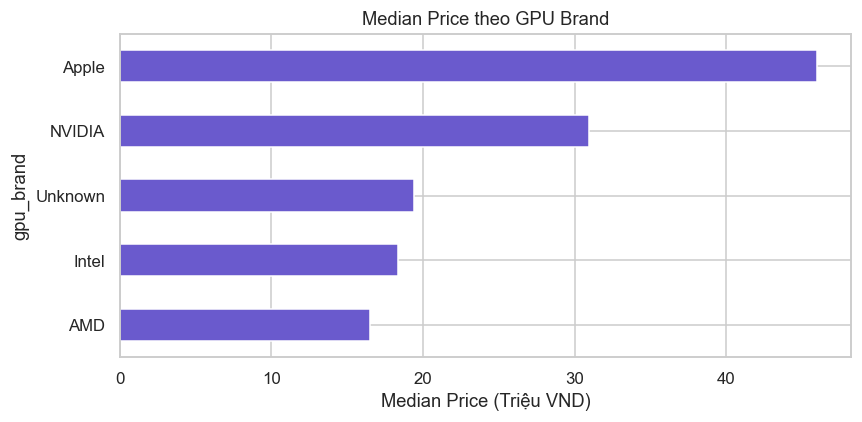

In [22]:
# ── 6.3 Price by GPU brand ───────────────────────────────────────────────────
# FIX: price_median đã là triệu VND → KHÔNG chia 1e6 nữa
fig, ax = plt.subplots(figsize=(8, 4))
gpu_price = df.groupby('gpu_brand')['price_median'].median().sort_values()
gpu_price.plot(kind='barh', ax=ax, color='slateblue')
ax.set_xlabel('Median Price (Triệu VND)')
ax.set_title('Median Price theo GPU Brand')
plt.tight_layout()
plt.show()

### 6.4 Storage Capacity × Type & Price Impact

> SSD vs HDD, dung lượng phổ biến — thông tin cần cho cleaning `Loại ổ cứng` downstream.

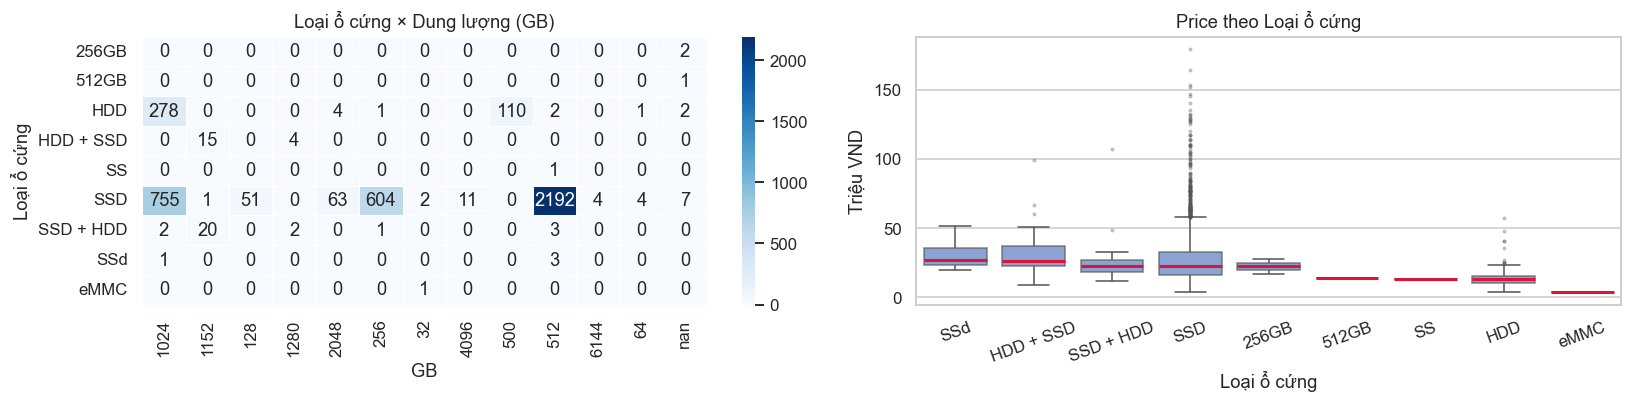

In [23]:
# ── 6.4 Storage type × capacity + price ─────────────────────────────────────
stor_gb_clean = df['Dung lượng ổ cứng (GB)'].astype(str).str.replace(r'\.0$', '', regex=True)
stor_cross    = pd.crosstab(df['Loại ổ cứng'], stor_gb_clean)

common_gb  = stor_cross.columns[stor_cross.sum() >= 3]
stor_cross = stor_cross[common_gb]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.heatmap(stor_cross, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=0.4)
axes[0].set_title('Loại ổ cứng × Dung lượng (GB)')
axes[0].set_xlabel('GB')

# Price by storage type — sns.boxplot thay df.boxplot
stor_order = (
    df.groupby('Loại ổ cứng')['price_median'].median()
    .sort_values(ascending=False).index.tolist()
)
sns.boxplot(data=df, x='Loại ổ cứng', y='price_median', order=stor_order,
            ax=axes[1],
            flierprops=dict(marker='.', markersize=3, alpha=0.4),
            medianprops=dict(color='crimson', linewidth=2),
            boxprops=dict(alpha=0.7))
axes[1].set_title('Price theo Loại ổ cứng')
axes[1].set_ylabel('Triệu VND')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 7. Duplicate Check

In [24]:
n_full = df.duplicated().sum()
print(f"Full row duplicates: {n_full}")

# Spec-key duplicate (soft — cùng config ≠ cùng sản phẩm)
spec_key = ['Hãng sản xuất', 'Loại CPU', 'Dung lượng RAM',
            'Dung lượng ổ cứng (GB)', 'Kích thước (inch)']
n_spec = df.duplicated(subset=spec_key).sum()
print(f"Spec-key duplicates: {n_spec}")
print("  → Không tự động drop: cùng config có thể khác màu/phiên bản")

# Preview spec duplicates nếu có
if n_spec > 0:
    dup_mask = df.duplicated(subset=spec_key, keep=False)
    display(
        df.loc[dup_mask, spec_key + ['price_median']]
        .sort_values(spec_key)
        .head(10)
    )

Full row duplicates: 0
Spec-key duplicates: 1704
  → Không tự động drop: cùng config có thể khác màu/phiên bản


,Hãng sản xuất,Loại CPU,Dung lượng RAM,Dung lượng ổ cứng (GB),Kích thước (inch),price_median
316,Acer,1005G1,4.00,256.00,15.60,10.50
2065,Acer,1005G1,4.00,256.00,15.60,7.29
2914,Acer,1005G1,4.00,256.00,15.60,12.70
1231,Acer,10210U,4.00,256.00,15.60,14.57
4295,Acer,10210U,4.00,256.00,15.60,11.89
677,Acer,10210U,8.00,512.00,15.60,16.95
829,Acer,10210U,8.00,512.00,15.60,15.21
574,Acer,10300H,8.00,512.00,15.60,14.49
652,Acer,10300H,8.00,512.00,15.60,19.25
1541,Acer,10300H,8.00,512.00,15.60,23.26


### 7b. Correlation — Numeric Specs vs Price

> Feature nào predict giá tốt nhất → ưu tiên normalize cho merge.

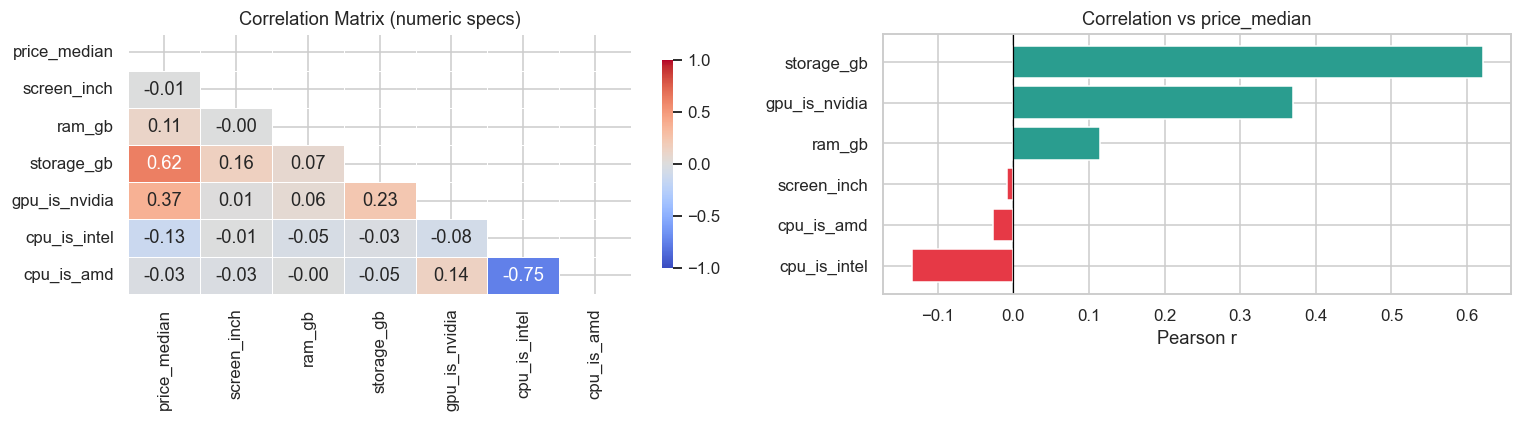

Correlation với price_median (|r| giảm dần):


,|r|
storage_gb,0.62
gpu_is_nvidia,0.37
cpu_is_intel,0.14
ram_gb,0.12
cpu_is_amd,0.03
screen_inch,0.01


In [25]:
# ── 7b Correlation numeric specs vs price_median ─────────────────────────────
num_df = pd.DataFrame({
    'price_median':  df['price_median'],
    'screen_inch':   pd.to_numeric(df['Kích thước (inch)'],       errors='coerce'),
    'ram_gb':        pd.to_numeric(df['Dung lượng RAM'],           errors='coerce'),
    'storage_gb':    pd.to_numeric(df['Dung lượng ổ cứng (GB)'], errors='coerce'),
    'gpu_is_nvidia': (df['gpu_brand'] == 'NVIDIA').astype(int),
    'cpu_is_intel':  (df['cpu_brand'] == 'Intel').astype(int),
    'cpu_is_amd':    (df['cpu_brand'] == 'AMD').astype(int),
})

corr = num_df.corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix (numeric specs)')

price_corr  = corr['price_median'].drop('price_median').sort_values()
colors_bar  = ['#e63946' if v < 0 else '#2a9d8f' for v in price_corr]
axes[1].barh(price_corr.index, price_corr.values, color=colors_bar)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation vs price_median')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

print("Correlation với price_median (|r| giảm dần):")
display(price_corr.abs().sort_values(ascending=False).round(3).to_frame('|r|'))


---
## 8. Cross-Source Alignment Plan

Mapping Websach ↔ Source B cho bước merge tại `03_merge.ipynb`.

> **Free-text columns** (`title`, `Thông tin sử dụng` của Source B) **không tham gia schema mapping** — giữ riêng làm dữ liệu bổ sung, không cần align hay chuẩn hoá.

In [26]:
mapping = [
    # target_col       websach                       source_b               transform
    ('price',          'price_median [computed]',    'price',               'numeric, triệu VND'),
    ('brand',          'Hãng sản xuất',              'Hãng',                'title().strip()'),
    ('model_line',     '— NaN',                      'Dòng máy',            'NaN for websach'),
    ('condition',      '— fill Mới',                 'Tình trạng',          'hardcode Mới for websach'),
    ('warranty',       '— NaN',                      'Chính sách bảo hành', 'NaN for websach'),
    ('screen_inch',    'Kích thước (inch)',           'Kích cỡ màn hình',    'extract float'),
    ('cpu_full',       'Công nghệ CPU + Loại CPU',   'Bộ vi xử lý',         'concat & normalize'),
    ('ram_gb',         'Dung lượng RAM',              'RAM',                 'extract int'),
    ('ram_type',       'Loại RAM',                   'RAM [partial]',       'DDR4/5/LPDDR…'),
    ('gpu_model',      'Đồ họa đã làm sạch',         'Card màn hình',       'normalize model name'),
    ('storage_gb',     'Dung lượng ổ cứng (GB)',     'Ổ cứng',              'extract int'),
    ('storage_type',   'Loại ổ cứng',                'Loại ổ cứng',         'SSD/HDD/eMMC upper'),
    ('origin',         '— NaN',                      'Xuất xứ',             'NaN for websach'),
    ('source',         'websach',                    'source_b',            'literal tag'),
]

display(
    pd.DataFrame(mapping, columns=['target_col', 'websach', 'source_b', 'transform'])
    .style.set_properties(**{'text-align': 'left'})
)

print("\nFree-text (không map):")
print("  Source B → title, Thông tin sử dụng : giữ nguyên làm cột bổ sung")
print("  Websach  → không có field tương đương: NaN sau merge")

,target_col,websach,source_b,transform
0,price,price_median [computed],price,"numeric, triệu VND"
1,brand,Hãng sản xuất,Hãng,title().strip()
2,model_line,— NaN,Dòng máy,NaN for websach
3,condition,— fill Mới,Tình trạng,hardcode Mới for websach
4,warranty,— NaN,Chính sách bảo hành,NaN for websach
5,screen_inch,Kích thước (inch),Kích cỡ màn hình,extract float
6,cpu_full,Công nghệ CPU + Loại CPU,Bộ vi xử lý,concat & normalize
7,ram_gb,Dung lượng RAM,RAM,extract int
8,ram_type,Loại RAM,RAM [partial],DDR4/5/LPDDR…
9,gpu_model,Đồ họa đã làm sạch,Card màn hình,normalize model name



Free-text (không map):
  Source B → title, Thông tin sử dụng : giữ nguyên làm cột bổ sung
  Websach  → không có field tương đương: NaN sau merge


---
## 9. Issues Summary & Cleaning Checklist

Input cho `02b_websach_cleaning.ipynb`.

> Cell này tổng hợp tự động các issues phát hiện ở các section trên.
> Chạy sau khi đã chạy hết notebook.

In [27]:
issues = pd.DataFrame([
    # Prices
    (
        "price_slots_not_fixed_shops",
        "Các cột shop_1_price, shop_2_price, shop_3_price không đại diện cho các shop cố định mà là các price slots từ các nguồn bất kỳ. Vì vậy không thể so sánh trực tiếp shop_1, shop_2, shop_3 như ba cửa hàng cố định.",
        "Diễn giải các cột này là price slots; chuyển dữ liệu sang long format khi cần phân tích theo shop_name thật; không kết luận shop nào đắt/rẻ hơn dựa trên shop_1/shop_2/shop_3."
    ),
    (
        "price_domain_outliers",
        "Tồn tại một số giá trị giá nằm ngoài miền hợp lý của laptop, ví dụ các mức giá rất cao như 268.4M, 860M, 1629M hoặc 2750M VND. Các giá này có khả năng là lỗi crawl, lỗi parse hoặc listing không phù hợp.",
        "Áp dụng domain filter ở cấp độ từng ô giá: null-out các giá < 3M hoặc > 200M; không xóa toàn bộ dòng nếu các nguồn giá khác vẫn hợp lệ."
    ),
    (
        "price_relative_outliers",
        "Một số sản phẩm có một nguồn giá lệch mạnh so với hai nguồn còn lại, làm spread giữa các nguồn tăng cao. Đây thường là cell-level outlier hơn là lỗi của toàn bộ sản phẩm.",
        "Sau domain filter, dùng median giá của từng dòng làm anchor; null-out giá nếu nhỏ hơn 0.5× hoặc lớn hơn 2× row median; sau đó tính lại giá tham chiếu từ các giá sạch."
    ),
    (
        "price_spread_between_sources",
        "Sau khi lọc domain outlier, vẫn có nhiều sản phẩm có chênh lệch giá lớn giữa các nguồn. Spread median khoảng 10%, nhưng một số dòng có spread trên 30% hoặc 50%, có thể do khác biệt shop, khuyến mãi, bảo hành, cấu hình phụ hoặc listing chưa đồng nhất.",
        "Không xóa toàn bộ các dòng có spread cao; tạo flag_price_spread_warn và flag_price_spread_critical để audit; ưu tiên dùng median thay vì mean để tổng hợp giá."
    ),
    (
        "price_right_skewed_distribution",
        "Giá tham chiếu price_median có phân phối lệch phải, tập trung chủ yếu ở phân khúc thấp-trung nhưng vẫn có nhóm high-price tail gồm laptop cao cấp, gaming, workstation hoặc Apple cấu hình mạnh.",
        "Dùng median/IQR để mô tả giá thay vì chỉ dùng mean; khi modeling nên cân nhắc log-transform target price_median để giảm ảnh hưởng của đuôi phải."
    ),
    (
        "price_high_tail_valid_but_influential",
        "Nhóm giá cao sau cleaning phần lớn có cấu hình hợp lý như RAM 64GB-128GB, SSD từ 1TB đến >2TB, CPU/GPU cao cấp. Tuy nhiên nhóm này vẫn có thể ảnh hưởng mạnh đến mô hình do giá rất cao so với phần lớn dữ liệu.",
        "Giữ lại nếu mục tiêu là bao phủ toàn bộ thị trường laptop mới; khi modeling có thể dùng log price, robust metrics, hoặc phân tích riêng high-end segment."
    ),
    (
        "source_quality_variation",
        "Một số shop_name có tỷ lệ relative outlier cao hơn các nguồn khác, đặc biệt ở những nguồn có số quan sát ít. Điều này cho thấy chất lượng nguồn giá không hoàn toàn đồng nhất.",
        "Không loại bỏ toàn bộ shop chỉ dựa trên tỷ lệ outlier nhỏ mẫu; dùng bảng source quality để audit nguồn, theo dõi các shop noisy và ưu tiên xử lý ở cấp độ từng ô giá."
    ),

    # Screen size
    (
        "screen_size_missing_values",
        "Cột Kích thước (inch) có một số giá trị thiếu. Sau khi clean và gom nhóm, có 96 dòng thuộc nhóm Unknown, bao gồm missing ban đầu và các giá trị bị loại do bất thường.",
        "Không nên xóa dòng chỉ vì thiếu kích thước màn hình; gán nhóm 'Unknown' cho EDA/modeling hoặc suy luận lại từ title/spec nếu có dữ liệu bổ sung."
    ),
    (
        "screen_size_outliers",
        "Tồn tại các giá trị kích thước màn hình lớn hơn 25 inch, không hợp lý với laptop và có khả năng là lỗi parse, lỗi crawl hoặc thông tin không thuộc trường kích thước màn hình.",
        "Null-out các giá trị Kích thước (inch) > 25 hoặc <= 0 trước khi phân tích; kiểm tra thủ công nếu cần giữ lại các trường hợp đặc biệt."
    ),
    (
        "screen_size_fragmentation",
        "Kích thước màn hình có nhiều giá trị chi tiết như 13.3, 13.4, 13.5, 14, 14.2, 15.3, 15.6, 16, 16.1, 16.2, 17.3, khiến phân tích theo từng giá trị đơn lẻ dễ bị phân mảnh.",
        "Gom kích thước màn hình thành các nhóm như '<13in', '13-13.9in', '14-14.9in', '15-15.9in', '16-16.9in', '>=17in', và 'Unknown'."
    ),
    (
        "screen_size_class_imbalance",
        "Phân phối kích thước màn hình không đồng đều. Dữ liệu tập trung chủ yếu ở nhóm 14-14.9 inch và 15-15.9 inch, trong khi các nhóm <13 inch và >=17 inch có ít mẫu hơn.",
        "Khi so sánh giá theo screen size, cần chú ý số lượng mẫu từng nhóm; hạn chế kết luận mạnh với các nhóm có ít quan sát."
    ),
    (
        "screen_size_price_confounding",
        "Giá có xu hướng cao hơn ở nhóm màn hình lớn, đặc biệt từ 16 inch trở lên, nhưng hiệu ứng này có thể bị nhiễu bởi cấu hình đi kèm như GPU, RAM, CPU, storage và brand.",
        "Không kết luận màn hình lớn là nguyên nhân trực tiếp làm giá cao hơn; cần phân tích thêm theo tương tác với brand, GPU, RAM hoặc dùng mô hình đa biến."
    ),
    (
        "brand_screen_interaction",
        "Median price theo screen size thay đổi rõ theo từng hãng. Ví dụ cùng nhóm 16-16.9 inch nhưng Apple và MSI có median price cao hơn nhiều so với HP, Lenovo hoặc Dell.",
        "Giữ lại biến tương tác brand × screen_size_group trong EDA; khi modeling có thể dùng one-hot encoding cho brand và screen_size_group, hoặc thử interaction features nếu mô hình tuyến tính."
    ),
    (
        "low_count_brand_screen_cells",
        "Một số tổ hợp brand × screen size có số lượng mẫu rất thấp, nên median price của các ô này không ổn định và dễ bị ảnh hưởng bởi outlier.",
        "Chỉ hiển thị hoặc diễn giải các ô có số mẫu tối thiểu, ví dụ n >= 10; gom các brand hiếm vào 'Other' nếu cần."
    ),

    # CPU
    (
        "cpu_brand_class_imbalance",
        "Phân phối CPU brand bị lệch mạnh về Intel. Intel chiếm khoảng 80.8% dữ liệu, trong khi AMD chiếm 13.1%, Apple 3.0%, Qualcomm 0.8% và Microsoft SQ 0.1%.",
        "Khi phân tích hoặc modeling, cần lưu ý class imbalance; không nên so sánh mạnh các nhóm có quá ít mẫu như Qualcomm hoặc Microsoft SQ."
    ),
    (
        "cpu_brand_unknown_values",
        "Sau khi cải thiện mapping CPU brand, vẫn còn 94 dòng thuộc nhóm Unknown. Phần lớn thiếu Công nghệ CPU, nhưng một số dòng vẫn có Loại CPU như 1240P, 12700H, 1135G7 hoặc 1115G4, có khả năng thuộc Intel.",
        "Tiếp tục cải thiện mapping bằng cách suy luận brand từ Loại CPU; nếu không chắc chắn thì giữ nhóm Unknown thay vì gán sai."
    ),
    (
        "cpu_model_high_cardinality",
        "Loại CPU có độ phân mảnh cao, nhiều model chỉ xuất hiện với số lượng nhỏ. Model phổ biến nhất cũng chỉ chiếm khoảng 5.4%, nên dùng trực tiếp Loại CPU có thể gây sparse features và overfitting.",
        "Không nên dùng raw CPU model trực tiếp cho EDA/modeling; nên gom thành cpu_brand, cpu_tier hoặc generation/series nếu có rule đủ chắc."
    ),
    (
        "cpu_tier_unknown_values",
        "Biến cpu_tier vẫn còn 304 dòng Unknown, cho thấy rule phân loại CPU tier chưa bao phủ hết các model hoặc thông tin CPU bị thiếu.",
        "Audit các giá trị cpu_tier Unknown; mở rộng rule cho các mã CPU phổ biến hoặc giữ Unknown như một nhóm riêng trong modeling."
    ),
    (
        "cpu_tier_price_confounding",
        "Giá tăng rõ theo cpu_tier, đặc biệt High-end có median price cao nhất. Tuy nhiên CPU tier thường đi kèm với RAM cao, GPU rời, storage lớn và brand cao cấp nên không thể xem CPU tier là nguyên nhân duy nhất làm giá tăng.",
        "Khi phân tích giá, cần kết hợp cpu_tier với RAM, GPU, storage và brand; khi modeling nên dùng mô hình đa biến để kiểm soát các yếu tố đi kèm."
    ),

    # RAM capacity
    (
        "ram_capacity_missing_values",
        "Dung lượng RAM có rất ít missing sau cleaning, khoảng 23 dòng Unknown/missing. Tỷ lệ này thấp nhưng vẫn cần xử lý trước khi modeling.",
        "Không nên xóa dòng chỉ vì thiếu RAM; gán nhóm Unknown hoặc impute nếu mô hình yêu cầu giá trị số."
    ),
    (
        "ram_capacity_outliers_or_parse_errors",
        "Một số giá trị RAM bất thường như 512 hoặc 5600 có khả năng là lỗi parse hoặc bị nhầm với tốc độ RAM/thông số khác, không phải dung lượng RAM thực tế.",
        "Null-out các giá trị RAM <= 0 hoặc > 256GB; kiểm tra thủ công các giá trị lạ nếu cần giữ lại."
    ),
    (
        "ram_capacity_fragmentation",
        "Dung lượng RAM có một số mức không thuộc tier chính như 12GB, 18GB, 19GB, 24GB, 36GB hoặc 48GB. Một số giá trị là hợp lệ nhưng số lượng ít, dễ làm phân mảnh category.",
        "Gom RAM thành các nhóm chính như ≤8GB, 16GB, 32GB, >32GB, Other và Unknown để phân tích ổn định hơn."
    ),
    (
        "ram_tier_price_confounding",
        "RAM tier có quan hệ rất mạnh với price_median; giá tăng rõ từ ≤8GB lên 16GB, 32GB và >32GB. Tuy nhiên RAM cao thường đi kèm CPU/GPU/storage/brand cao cấp.",
        "Giữ ram_tier_clean là feature quan trọng, nhưng khi diễn giải tác động đến giá cần kiểm soát thêm CPU tier, GPU tier, storage và brand."
    ),

    # RAM type
    (
        "ram_type_missing_unknown",
        "Loại RAM có nhiều giá trị Unknown hơn dung lượng RAM, khoảng 326 dòng sau cleaning. Đây là nguồn thiếu thông tin đáng chú ý trong nhóm RAM.",
        "Giữ Unknown như một category riêng; nếu có title/spec gốc thì có thể parse bổ sung để giảm missing."
    ),
    (
        "ram_type_inconsistent_labels",
        "Loại RAM có nhiều biến thể và lỗi chính tả như DDR5x, DDR5X, LPDDR5x, LPDDR5X, DR4, DR5 hoặc giá trị số như 16, 32, 8.",
        "Chuẩn hóa bằng mapping dictionary: uppercase, sửa typo, gom biến thể tương đương và đưa giá trị số/lỗi parse về Unknown hoặc Other."
    ),
    (
        "ram_type_low_frequency_categories",
        "Một số loại RAM như LPDDR4, DDR5X, LPDDR3, DDR3, DDR3L hoặc Other có số lượng mẫu thấp, khiến median price của từng nhóm không ổn định.",
        "Khi modeling, cân nhắc gom nhóm hiếm vào Other hoặc chỉ giữ các nhóm lớn như DDR4, DDR5, LPDDR5X, LPDDR5, LPDDR4X và Unknown."
    ),

    # Interactions
    (
        "cpu_ram_interaction",
        "Median price tăng theo RAM tier trong từng CPU brand, đặc biệt rõ ở Intel, AMD và Apple. Điều này cho thấy RAM và CPU không độc lập khi giải thích giá.",
        "Trong EDA nên phân tích CPU Brand × RAM Tier; khi modeling, cân nhắc thêm interaction features hoặc dùng mô hình tree-based có thể tự học tương tác."
    ),
    (
        "gpu_ram_interaction",
        "Median price tăng mạnh khi RAM cao kết hợp với GPU rời, đặc biệt ở các nhóm RTX hoặc Other GPU. Một số tổ hợp RAM × GPU có giá rất cao.",
        "Giữ cả gpu_tier và ram_tier_clean; cân nhắc interaction gpu_tier × ram_tier_clean, đồng thời lọc các cell có quá ít quan sát khi diễn giải."
    ),
    (
        "low_count_interaction_cells",
        "Một số tổ hợp CPU Brand × RAM Tier hoặc GPU Tier × RAM Tier có số lượng mẫu thấp, ví dụ Microsoft SQ, Qualcomm, AMD >32GB hoặc một số GPU rời với RAM cao.",
        "Chỉ hiển thị/diễn giải các ô có số mẫu tối thiểu, ví dụ n >= 20; gom nhóm hiếm nếu cần dùng cho modeling."
    ),


], columns=["issue", "description", "recommendation"])

display(issues)

,column,issue_type,count,action
0,price,no_price_at_all,0,Drop rows
1,price,null_after_cleaning,0,Drop rows
2,price,spread_gt_50pct,203,Manual review or winsorize
3,Loại RAM,missing,318,7.3% — impute or drop
4,Dung lượng ổ cứng (GB),missing,225,5.1% — impute or drop
5,Loại ổ cứng,missing,219,5.0% — impute or drop
6,Hãng sản xuất,missing,180,4.1% — impute or drop
7,Công nghệ CPU,missing,94,2.1% — impute or drop
8,Loại CPU,missing,69,1.6% — impute or drop
9,Dung lượng RAM,missing,21,0.5% — impute or drop



Tổng 14 issues cần xử lý trong 02b_websach_cleaning.ipynb


In [28]:
# ── Save issues checklist ────────────────────────────────────────────────────
import os
OUT_DIR = '../../docs'
os.makedirs(OUT_DIR, exist_ok=True)

out_path = os.path.join(OUT_DIR, 'websach_issues_list.csv')
issues.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"Saved: {out_path}")

Saved: ../../docs\websach_issues_list.csv
